In [1]:
# =============================================================================
# MODEL 4A - STEP 1A
# KAGGLE AUTHENTICATION
# =============================================================================

import os
import shutil
from pathlib import Path

print("=" * 80)
print("MODEL 4A - KAGGLE AUTHENTICATION")
print("=" * 80)

# Upload kaggle.json
from google.colab import files

uploaded = files.upload()

if "kaggle.json" not in uploaded:
    raise RuntimeError(
        "kaggle.json was not uploaded. "
        "Download it from Kaggle Account → Settings → API."
    )

# Create Kaggle config directory
kaggle_dir = Path("/root/.config/kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)

# Move uploaded file
shutil.copy(
    "kaggle.json",
    kaggle_dir / "kaggle.json"
)

# Secure permissions
os.chmod(
    kaggle_dir / "kaggle.json",
    0o600
)

print()
print("✅ kaggle.json installed")
print("✅ Kaggle authentication configured")

# Test authentication WITHOUT importing the Python API
import subprocess
import sys

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "kaggle",
        "datasets",
        "list",
        "--search",
        "brisc2025"
    ],
    capture_output=True,
    text=True
)

print()
print("Kaggle test:")
print(result.stdout[:5000])

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("❌ Kaggle authentication failed.")

print()
print("✅ KAGGLE AUTHENTICATION SUCCESSFUL")
print("=" * 80)

MODEL 4A - KAGGLE AUTHENTICATION


Saving kaggle.json to kaggle.json

✅ kaggle.json installed
✅ Kaggle authentication configured

Kaggle test:

/usr/bin/python3: No module named kaggle.__main__; 'kaggle' is a package and cannot be directly executed



RuntimeError: ❌ Kaggle authentication failed.

In [2]:
# =============================================================================
# MODEL 4A - STEP 1B
# BRISC 2025 DOWNLOAD + SAVE TO GOOGLE DRIVE
# CPU IS OK — NO TRAINING
# =============================================================================

import os
import sys
import subprocess
from pathlib import Path

print("=" * 80)
print("MODEL 4A - STEP 1B")
print("BRISC 2025 DOWNLOAD → GOOGLE DRIVE")
print("=" * 80)

# =============================================================================
# 1. MOUNT DRIVE
# =============================================================================

from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/Model4A")

RAW_DIR      = DRIVE_ROOT / "raw"
DATASET_DIR  = DRIVE_ROOT / "dataset"
AUDIT_DIR    = DRIVE_ROOT / "audit"
MANIFEST_DIR = DRIVE_ROOT / "manifests"
PROCESSED_DIR = DRIVE_ROOT / "processed"
MODELS_DIR   = DRIVE_ROOT / "models"
RESULTS_DIR  = DRIVE_ROOT / "results"
EXPORT_DIR   = DRIVE_ROOT / "exports"

for d in [
    RAW_DIR,
    DATASET_DIR,
    AUDIT_DIR,
    MANIFEST_DIR,
    PROCESSED_DIR,
    MODELS_DIR,
    RESULTS_DIR,
    EXPORT_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

print()
print("Drive root:")
print(DRIVE_ROOT)

# =============================================================================
# 2. INSTALL KAGGLE CLI
# =============================================================================

print()
print("=" * 80)
print("CHECKING KAGGLE CLI")
print("=" * 80)

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        "kaggle"
    ],
    check=True
)

print("✅ Kaggle package installed/updated")

# =============================================================================
# 3. CONFIGURE KAGGLE CREDENTIALS
# =============================================================================

SOURCE_KAGGLE = Path("/content/kaggle.json")

CONFIG_DIR = Path("/root/.config/kaggle")
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_KAGGLE = CONFIG_DIR / "kaggle.json"

if SOURCE_KAGGLE.exists():

    import shutil

    shutil.copy(
        SOURCE_KAGGLE,
        TARGET_KAGGLE
    )

elif not TARGET_KAGGLE.exists():

    raise FileNotFoundError(
        "kaggle.json is not available. "
        "Upload it again only if necessary."
    )

os.chmod(
    TARGET_KAGGLE,
    0o600
)

print("✅ Kaggle credentials configured")

# =============================================================================
# 4. FIND KAGGLE EXECUTABLE
# =============================================================================

kaggle_executable = shutil.which("kaggle") if "shutil" in globals() else None

if kaggle_executable is None:

    import shutil

    kaggle_executable = shutil.which("kaggle")

if kaggle_executable is None:

    raise RuntimeError(
        "❌ Kaggle CLI executable was not found after installation."
    )

print()
print("Kaggle executable:")
print(kaggle_executable)

# =============================================================================
# 5. TEST KAGGLE CLI
# =============================================================================

print()
print("=" * 80)
print("TESTING KAGGLE ACCESS")
print("=" * 80)

test = subprocess.run(
    [
        kaggle_executable,
        "datasets",
        "list",
        "--search",
        "brisc2025"
    ],
    capture_output=True,
    text=True
)

print(test.stdout[:5000])

if test.returncode != 0:

    print()
    print("Kaggle error:")
    print(test.stderr)

    raise RuntimeError(
        "❌ Kaggle CLI test failed."
    )

print()
print("✅ KAGGLE ACCESS WORKING")

# =============================================================================
# 6. DOWNLOAD BRISC
# =============================================================================

KAGGLE_DATASET = "briscdataset/brisc2025"

ZIP_PATH = RAW_DIR / "brisc2025.zip"

print()
print("=" * 80)
print("DOWNLOADING BRISC 2025")
print("=" * 80)

print()
print("Dataset:")
print(KAGGLE_DATASET)

print()
print("Destination:")
print(RAW_DIR)

# Existing archive check
if ZIP_PATH.exists():

    size_gb = ZIP_PATH.stat().st_size / (1024 ** 3)

    if size_gb > 0.1:

        print()
        print("✅ Existing BRISC archive found.")
        print(
            f"Archive size: {size_gb:.3f} GB"
        )

    else:

        print()
        print("⚠️ Existing archive appears incomplete.")
        ZIP_PATH.unlink()

# Download if required
if not ZIP_PATH.exists():

    print()
    print("Starting download...")
    print("CPU is completely fine for this step.")
    print()

    download = subprocess.run(
        [
            kaggle_executable,
            "datasets",
            "download",
            "-d",
            KAGGLE_DATASET,
            "-p",
            str(RAW_DIR),
            "--force"
        ],
        text=True
    )

    if download.returncode != 0:

        raise RuntimeError(
            "❌ BRISC download failed."
        )

    # Find downloaded ZIP
    zip_files = list(
        RAW_DIR.glob("*.zip")
    )

    if not zip_files:

        raise FileNotFoundError(
            "❌ Download completed but ZIP file was not found."
        )

    # Select largest ZIP
    zip_files.sort(
        key=lambda p: p.stat().st_size,
        reverse=True
    )

    downloaded_zip = zip_files[0]

    if downloaded_zip != ZIP_PATH:

        if ZIP_PATH.exists():
            ZIP_PATH.unlink()

        downloaded_zip.rename(ZIP_PATH)

print()
print("=" * 80)
print("DOWNLOAD COMPLETE")
print("=" * 80)

print()
print("Archive:")
print(ZIP_PATH)

print(
    "Size: "
    f"{ZIP_PATH.stat().st_size / (1024 ** 3):.3f} GB"
)

# =============================================================================
# 7. VERIFY ZIP
# =============================================================================

print()
print("=" * 80)
print("VERIFYING ZIP")
print("=" * 80)

verify = subprocess.run(
    [
        "unzip",
        "-t",
        str(ZIP_PATH)
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

if verify.returncode != 0:

    print(verify.stdout[-5000:])

    raise RuntimeError(
        "❌ ZIP verification failed."
    )

print("✅ ZIP archive verified")

# =============================================================================
# 8. EXTRACT TO DRIVE
# =============================================================================

EXTRACT_DIR = DATASET_DIR / "brisc2025"

print()
print("=" * 80)
print("EXTRACTING DATASET TO DRIVE")
print("=" * 80)

if EXTRACT_DIR.exists():

    print()
    print("✅ Existing extraction found:")
    print(EXTRACT_DIR)

else:

    EXTRACT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    subprocess.run(
        [
            "unzip",
            "-q",
            str(ZIP_PATH),
            "-d",
            str(EXTRACT_DIR)
        ],
        check=True
    )

    print()
    print("✅ Dataset extracted")

# =============================================================================
# 9. COUNT EXTRACTED FILES
# =============================================================================

print()
print("=" * 80)
print("EXTRACTION CHECK")
print("=" * 80)

all_files = [
    p for p in EXTRACT_DIR.rglob("*")
    if p.is_file()
]

print()
print("Extracted files:")
print(len(all_files))

# Show likely segmentation folders
print()
print("Relevant directories:")

shown = 0

for p in EXTRACT_DIR.rglob("*"):

    if p.is_dir():

        name = p.name.lower()

        if (
            "segment" in name
            or name in {"images", "masks"}
        ):

            print(" -", p)
            shown += 1

            if shown >= 30:
                break

# =============================================================================
# 10. SAVE ACQUISITION RECORD
# =============================================================================

import json

record = {
    "dataset": "BRISC 2025",
    "kaggle_dataset": KAGGLE_DATASET,
    "archive": str(ZIP_PATH),
    "archive_size_gb":
        ZIP_PATH.stat().st_size / (1024 ** 3),
    "dataset_directory": str(EXTRACT_DIR),
    "extracted_files": len(all_files),
    "download_verified": True,
    "zip_verified": True
}

record_path = (
    AUDIT_DIR /
    "model4a_step1_acquisition.json"
)

with open(record_path, "w") as f:
    json.dump(
        record,
        f,
        indent=2
    )

print()
print("=" * 80)
print("MODEL 4A - STEP 1B COMPLETE")
print("=" * 80)

print()
print("✅ Kaggle authenticated")
print("✅ BRISC downloaded")
print("✅ ZIP verified")
print("✅ Dataset extracted")
print("✅ Dataset stored on Google Drive")

print()
print("Drive dataset:")
print(EXTRACT_DIR)

print()
print("Acquisition record:")
print(record_path)

print()
print("=" * 80)
print("NEXT → STEP 1C: DATASET DISCOVERY + FULL SEGMENTATION AUDIT")
print("=" * 80)

MODEL 4A - STEP 1B
BRISC 2025 DOWNLOAD → GOOGLE DRIVE
Mounted at /content/drive

Drive root:
/content/drive/MyDrive/Model4A

CHECKING KAGGLE CLI
✅ Kaggle package installed/updated
✅ Kaggle credentials configured

Kaggle executable:
/usr/local/bin/kaggle

TESTING KAGGLE ACCESS
ref                                           title                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------  ------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
briscdataset/brisc2025                        🧠 BRISC 2025                     262284213  2025-11-04 17:11:56.713000          11821         92  0.8235294        
maulikgajera/brain-tumor-mri-dataset          🧠 Brain Tumor MRI Dataset        261134788  2026-07-29 16:41:49.240000            140         19  0.75             
crazydjgamer/brisc2025                        brisc2025                    

In [3]:
# =============================================================================
# MODEL 4A - STEP 1C
# BRISC 2025 FULL SEGMENTATION DATASET AUDIT
# =============================================================================

import os
import json
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

print("=" * 80)
print("MODEL 4A - STEP 1C")
print("BRISC 2025 FULL SEGMENTATION DATASET AUDIT")
print("=" * 80)

# =============================================================================
# 1. PATHS
# =============================================================================

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/Model4A")

DATASET_ROOT = (
    DRIVE_ROOT /
    "dataset" /
    "brisc2025" /
    "brisc2025" /
    "segmentation_task"
)

TRAIN_IMAGES = DATASET_ROOT / "train" / "images"
TRAIN_MASKS  = DATASET_ROOT / "train" / "masks"

TEST_IMAGES = DATASET_ROOT / "test" / "images"
TEST_MASKS  = DATASET_ROOT / "test" / "masks"

AUDIT_DIR = DRIVE_ROOT / "audit"
MANIFEST_DIR = DRIVE_ROOT / "manifests"

AUDIT_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

print()
print("Dataset root:")
print(DATASET_ROOT)

# =============================================================================
# 2. DIRECTORY CHECK
# =============================================================================

print()
print("=" * 80)
print("DIRECTORY CHECK")
print("=" * 80)

required_dirs = [
    TRAIN_IMAGES,
    TRAIN_MASKS,
    TEST_IMAGES,
    TEST_MASKS
]

for d in required_dirs:

    if d.exists():
        print("✅", d)
    else:
        print("❌", d)

        raise FileNotFoundError(
            f"Required directory missing: {d}"
        )

# =============================================================================
# 3. COLLECT FILES
# =============================================================================

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png"
}

def collect_files(directory):

    return sorted(
        [
            p for p in directory.iterdir()
            if p.is_file()
            and p.suffix.lower() in VALID_EXTENSIONS
        ]
    )

train_images = collect_files(TRAIN_IMAGES)
train_masks  = collect_files(TRAIN_MASKS)

test_images = collect_files(TEST_IMAGES)
test_masks  = collect_files(TEST_MASKS)

print()
print("=" * 80)
print("FILE COUNTS")
print("=" * 80)

print()
print("TRAIN")
print("Images:", len(train_images))
print("Masks :", len(train_masks))

print()
print("TEST")
print("Images:", len(test_images))
print("Masks :", len(test_masks))

# =============================================================================
# 4. BASENAME PAIRING
# =============================================================================

print()
print("=" * 80)
print("IMAGE / MASK PAIRING")
print("=" * 80)

def build_map(files):

    return {
        p.stem: p
        for p in files
    }

train_image_map = build_map(train_images)
train_mask_map  = build_map(train_masks)

test_image_map = build_map(test_images)
test_mask_map  = build_map(test_masks)

train_image_ids = set(train_image_map)
train_mask_ids  = set(train_mask_map)

test_image_ids = set(test_image_map)
test_mask_ids  = set(test_mask_map)

train_missing_masks = sorted(
    train_image_ids - train_mask_ids
)

train_missing_images = sorted(
    train_mask_ids - train_image_ids
)

test_missing_masks = sorted(
    test_image_ids - test_mask_ids
)

test_missing_images = sorted(
    test_mask_ids - test_image_ids
)

print()
print("TRAIN")
print("Paired:", len(train_image_ids & train_mask_ids))
print("Images without masks:", len(train_missing_masks))
print("Masks without images:", len(train_missing_images))

print()
print("TEST")
print("Paired:", len(test_image_ids & test_mask_ids))
print("Images without masks:", len(test_missing_masks))
print("Masks without images:", len(test_missing_images))

# =============================================================================
# 5. CREATE MANIFEST
# =============================================================================

records = []

for image_id in sorted(train_image_ids & train_mask_ids):

    records.append({
        "split": "train",
        "id": image_id,
        "image_path": str(train_image_map[image_id]),
        "mask_path": str(train_mask_map[image_id])
    })

for image_id in sorted(test_image_ids & test_mask_ids):

    records.append({
        "split": "test",
        "id": image_id,
        "image_path": str(test_image_map[image_id]),
        "mask_path": str(test_mask_map[image_id])
    })

df = pd.DataFrame(records)

print()
print("Total paired samples:", len(df))

# =============================================================================
# 6. IMAGE / MASK DIMENSIONS
# =============================================================================

print()
print("=" * 80)
print("IMAGE / MASK DIMENSION AUDIT")
print("=" * 80)

dimension_counter = Counter()
dimension_errors = []

empty_masks = []
invalid_images = []
invalid_masks = []

mask_values = Counter()

image_ranges = []
mask_ranges = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    try:

        image = Image.open(row.image_path)
        mask = Image.open(row.mask_path)

        image_array = np.asarray(image)
        mask_array = np.asarray(mask)

        image_size = image.size
        mask_size = mask.size

        dimension_counter[
            (image_size, mask_size)
        ] += 1

        if image_size != mask_size:

            dimension_errors.append({
                "id": row.id,
                "split": row.split,
                "image_size": image_size,
                "mask_size": mask_size
            })

        # -------------------------------------------------------------
        # Image validation
        # -------------------------------------------------------------

        image_float = image_array.astype(
            np.float32
        )

        if not np.isfinite(
            image_float
        ).all():

            invalid_images.append(row.id)

        image_ranges.append({
            "id": row.id,
            "min": float(np.min(image_float)),
            "max": float(np.max(image_float)),
            "mean": float(np.mean(image_float))
        })

        # -------------------------------------------------------------
        # Mask validation
        # -------------------------------------------------------------

        mask_float = mask_array.astype(
            np.float32
        )

        if not np.isfinite(
            mask_float
        ).all():

            invalid_masks.append(row.id)

        unique = np.unique(mask_array)

        for value in unique:

            mask_values[
                int(value)
            ] += 1

        if np.count_nonzero(
            mask_array
        ) == 0:

            empty_masks.append({
                "id": row.id,
                "split": row.split
            })

        mask_ranges.append({
            "id": row.id,
            "min": float(np.min(mask_float)),
            "max": float(np.max(mask_float)),
            "mean": float(np.mean(mask_float)),
            "unique_values": ",".join(
                map(str, unique.tolist())
            )
        })

    except Exception as e:

        invalid_images.append({
            "id": row.id,
            "error": str(e)
        })

    if i % 500 == 0 or i == len(df):

        print(
            f"[{i}/{len(df)}] checked"
        )

print()
print("Dimension combinations:")

for k, v in dimension_counter.items():

    print(
        f"{k}: {v}"
    )

print()
print("Dimension errors:", len(dimension_errors))
print("Invalid images:", len(invalid_images))
print("Invalid masks:", len(invalid_masks))
print("Empty masks:", len(empty_masks))

# =============================================================================
# 7. MASK VALUE ANALYSIS
# =============================================================================

print()
print("=" * 80)
print("MASK VALUE ANALYSIS")
print("=" * 80)

print()
print("Mask values found:")

for value, count in sorted(
    mask_values.items()
):

    print(
        f"Value {value}: "
        f"{count} files containing this value"
    )

# =============================================================================
# 8. TRAIN / TEST ID OVERLAP
# =============================================================================

print()
print("=" * 80)
print("TRAIN / TEST OVERLAP")
print("=" * 80)

train_ids = set(
    train_image_map.keys()
)

test_ids = set(
    test_image_map.keys()
)

overlap = sorted(
    train_ids & test_ids
)

print()
print("Train IDs:", len(train_ids))
print("Test IDs :", len(test_ids))
print("Overlap  :", len(overlap))

if overlap:

    print()
    print("⚠️ TRAIN/TEST OVERLAP DETECTED")

else:

    print()
    print("✅ NO TRAIN/TEST ID OVERLAP")

# =============================================================================
# 9. FILE HASH DUPLICATE CHECK
# =============================================================================

print()
print("=" * 80)
print("DUPLICATE FILE AUDIT")
print("=" * 80)

def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()

image_hash_map = {}
mask_hash_map = {}

duplicate_images = []
duplicate_masks = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    try:

        image_hash = sha256_file(
            row.image_path
        )

        mask_hash = sha256_file(
            row.mask_path
        )

        if image_hash in image_hash_map:

            duplicate_images.append({
                "first": image_hash_map[image_hash],
                "duplicate": row.id,
                "split": row.split
            })

        else:

            image_hash_map[
                image_hash
            ] = row.id

        if mask_hash in mask_hash_map:

            duplicate_masks.append({
                "first": mask_hash_map[mask_hash],
                "duplicate": row.id,
                "split": row.split
            })

        else:

            mask_hash_map[
                mask_hash
            ] = row.id

    except Exception:
        pass

    if i % 500 == 0 or i == len(df):

        print(
            f"[{i}/{len(df)}] hashed"
        )

print()
print(
    "Duplicate image groups:",
    len(duplicate_images)
)

print(
    "Duplicate mask groups:",
    len(duplicate_masks)
)

# =============================================================================
# 10. SAVE MANIFEST
# =============================================================================

MANIFEST_PATH = (
    MANIFEST_DIR /
    "model4a_step1c_brisc_segmentation_manifest.csv"
)

df.to_csv(
    MANIFEST_PATH,
    index=False
)

print()
print("Manifest saved:")
print(MANIFEST_PATH)

# =============================================================================
# 11. SAVE STATISTICS
# =============================================================================

image_stats_df = pd.DataFrame(
    image_ranges
)

mask_stats_df = pd.DataFrame(
    mask_ranges
)

image_stats_df.to_csv(
    AUDIT_DIR /
    "image_statistics.csv",
    index=False
)

mask_stats_df.to_csv(
    AUDIT_DIR /
    "mask_statistics.csv",
    index=False
)

# =============================================================================
# 12. SAVE ERROR REPORTS
# =============================================================================

if dimension_errors:

    pd.DataFrame(
        dimension_errors
    ).to_csv(
        AUDIT_DIR /
        "dimension_errors.csv",
        index=False
    )

if empty_masks:

    pd.DataFrame(
        empty_masks
    ).to_csv(
        AUDIT_DIR /
        "empty_masks.csv",
        index=False
    )

if invalid_images:

    pd.DataFrame(
        invalid_images
    ).to_csv(
        AUDIT_DIR /
        "invalid_images.csv",
        index=False
    )

if invalid_masks:

    pd.DataFrame(
        invalid_masks
    ).to_csv(
        AUDIT_DIR /
        "invalid_masks.csv",
        index=False
    )

if duplicate_images:

    pd.DataFrame(
        duplicate_images
    ).to_csv(
        AUDIT_DIR /
        "duplicate_images.csv",
        index=False
    )

if duplicate_masks:

    pd.DataFrame(
        duplicate_masks
    ).to_csv(
        AUDIT_DIR /
        "duplicate_masks.csv",
        index=False
    )

# =============================================================================
# 13. FINAL AUDIT JSON
# =============================================================================

audit = {

    "dataset": "BRISC 2025",

    "dataset_root":
        str(DATASET_ROOT),

    "total_pairs":
        int(len(df)),

    "train_pairs":
        int((df["split"] == "train").sum()),

    "test_pairs":
        int((df["split"] == "test").sum()),

    "train_images":
        len(train_images),

    "train_masks":
        len(train_masks),

    "test_images":
        len(test_images),

    "test_masks":
        len(test_masks),

    "train_missing_masks":
        len(train_missing_masks),

    "train_missing_images":
        len(train_missing_images),

    "test_missing_masks":
        len(test_missing_masks),

    "test_missing_images":
        len(test_missing_images),

    "dimension_errors":
        len(dimension_errors),

    "invalid_images":
        len(invalid_images),

    "invalid_masks":
        len(invalid_masks),

    "empty_masks":
        len(empty_masks),

    "train_test_overlap":
        len(overlap),

    "duplicate_images":
        len(duplicate_images),

    "duplicate_masks":
        len(duplicate_masks),

    "mask_values":
        sorted(
            int(x)
            for x in mask_values.keys()
        ),

    "dimension_combinations": {
        str(k): int(v)
        for k, v in dimension_counter.items()
    }
}

AUDIT_JSON = (
    AUDIT_DIR /
    "model4a_step1c_full_audit.json"
)

with open(
    AUDIT_JSON,
    "w"
) as f:

    json.dump(
        audit,
        f,
        indent=2
    )

# =============================================================================
# 14. FINAL RESULT
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 1C FINAL AUDIT")
print("=" * 80)

print()
print("Total pairs       :", len(df))
print("Train pairs       :", len(train_ids))
print("Test pairs        :", len(test_ids))

print()
print("Missing masks     :",
      len(train_missing_masks) +
      len(test_missing_masks))

print("Missing images    :",
      len(train_missing_images) +
      len(test_missing_images))

print("Dimension errors   :", len(dimension_errors))
print("Invalid images     :", len(invalid_images))
print("Invalid masks      :", len(invalid_masks))
print("Empty masks        :", len(empty_masks))
print("Train/Test overlap :", len(overlap))

print("Duplicate images   :", len(duplicate_images))
print("Duplicate masks    :", len(duplicate_masks))

print()
print("Mask values:")
print(sorted(mask_values.keys()))

print()
print("Audit JSON:")
print(AUDIT_JSON)

print()
print("Manifest:")
print(MANIFEST_PATH)

# =============================================================================
# 15. TRAINING SAFETY DECISION
# =============================================================================

critical_errors = (
    len(train_missing_masks)
    + len(train_missing_images)
    + len(test_missing_masks)
    + len(test_missing_images)
    + len(dimension_errors)
    + len(invalid_images)
    + len(invalid_masks)
    + len(overlap)
)

print()
print("=" * 80)

if critical_errors == 0:

    print("✅ DATASET STRUCTURE PASSED")
    print("✅ IMAGE/MASK PAIRS PASSED")
    print("✅ DIMENSIONS PASSED")
    print("✅ TRAIN/TEST SEPARATION PASSED")

    if len(empty_masks) > 0:

        print(
            f"⚠️ {len(empty_masks)} EMPTY MASKS FOUND"
        )

        print(
            "DO NOT TRAIN UNTIL WE REVIEW THEM."
        )

    else:

        print("✅ NO EMPTY MASKS")
        print()
        print("NEXT → STEP 2: VISUAL SEGMENTATION AUDIT")

else:

    print("❌ CRITICAL DATASET AUDIT FAILURE")
    print("DO NOT TRAIN.")

print("=" * 80)

MODEL 4A - STEP 1C
BRISC 2025 FULL SEGMENTATION DATASET AUDIT
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Dataset root:
/content/drive/MyDrive/Model4A/dataset/brisc2025/brisc2025/segmentation_task

DIRECTORY CHECK
✅ /content/drive/MyDrive/Model4A/dataset/brisc2025/brisc2025/segmentation_task/train/images
✅ /content/drive/MyDrive/Model4A/dataset/brisc2025/brisc2025/segmentation_task/train/masks
✅ /content/drive/MyDrive/Model4A/dataset/brisc2025/brisc2025/segmentation_task/test/images
✅ /content/drive/MyDrive/Model4A/dataset/brisc2025/brisc2025/segmentation_task/test/masks

FILE COUNTS

TRAIN
Images: 3933
Masks : 3933

TEST
Images: 860
Masks : 860

IMAGE / MASK PAIRING

TRAIN
Paired: 3933
Images without masks: 0
Masks without images: 0

TEST
Paired: 860
Images without masks: 0
Masks without images: 0

Total paired samples: 4793

IMAGE / MASK DIMENSION AUDIT
[500/4793] checked
[1000/4793] checked
[1500/4

MODEL 4A - STEP 2
BRISC VISUAL SEGMENTATION + MASK ENCODING AUDIT
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Manifest:
/content/drive/MyDrive/Model4A/manifests/model4a_step1c_brisc_segmentation_manifest.csv

Manifest rows: 4793

MASK ENCODING INSPECTION

ID: brisc2025_train_00562_gl_co_t1
Mask mode: L
Size: (512, 512)
Palette detected: NO

ID: brisc2025_train_00894_gl_sa_t1
Mask mode: L
Size: (512, 512)
Palette detected: NO

ID: brisc2025_train_01685_me_co_t1
Mask mode: L
Size: (512, 512)
Palette detected: NO

ID: brisc2025_train_00706_gl_co_t1
Mask mode: L
Size: (512, 512)
Palette detected: NO

ID: brisc2025_train_01874_me_co_t1
Mask mode: L
Size: (512, 512)
Palette detected: NO

ID: brisc2025_train_03764_pi_ax_t1
Mask mode: L
Size: (512, 512)
Palette detected: NO

ID: brisc2025_train_04085_pi_co_t1
Mask mode: L
Size: (512, 512)
Palette detected: NO

ID: brisc2025_test_00547_me_sa_t1
Mask mode: L
Si

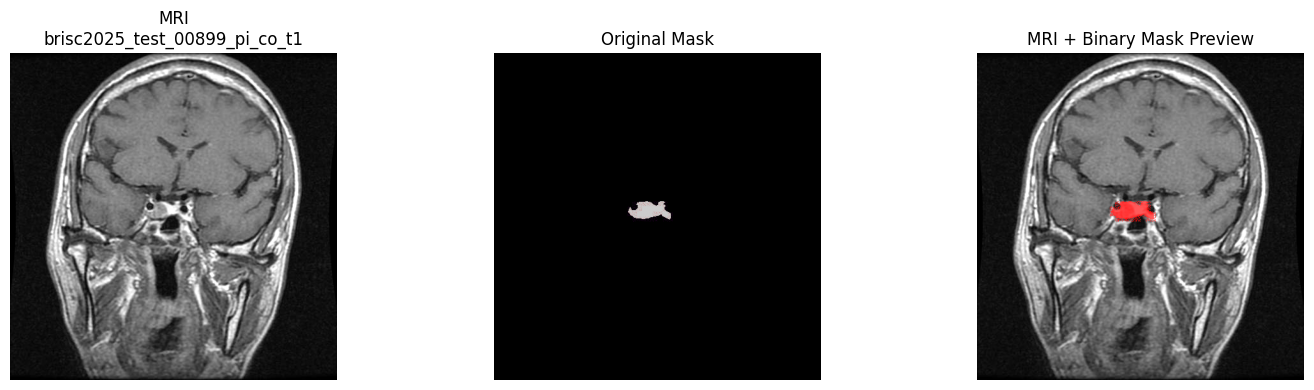

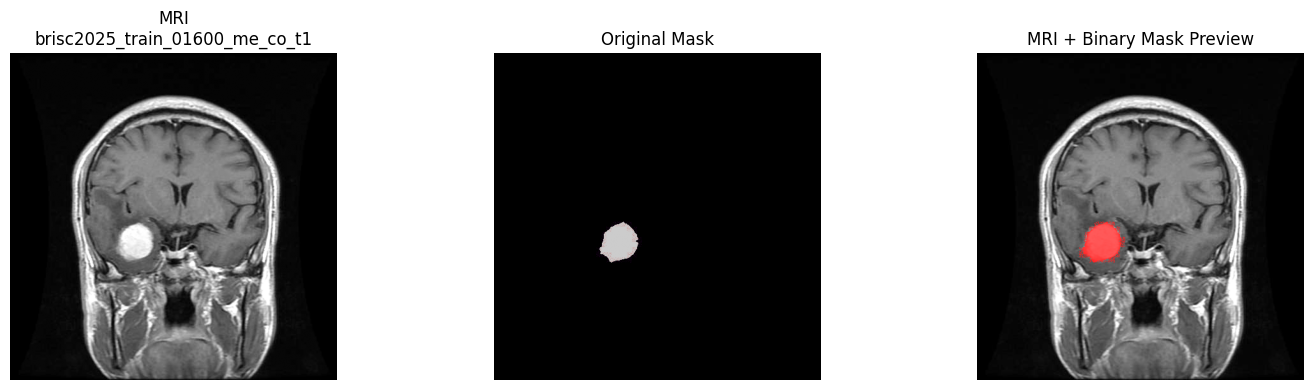

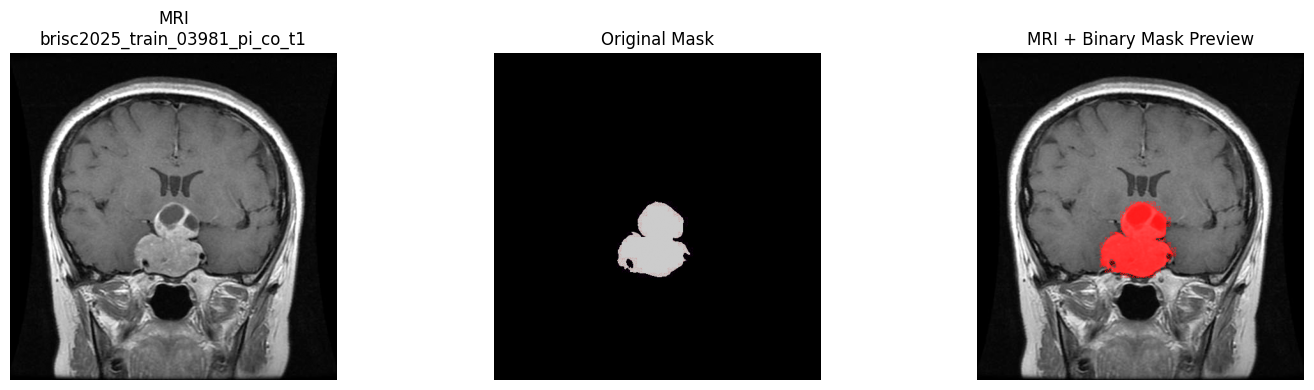

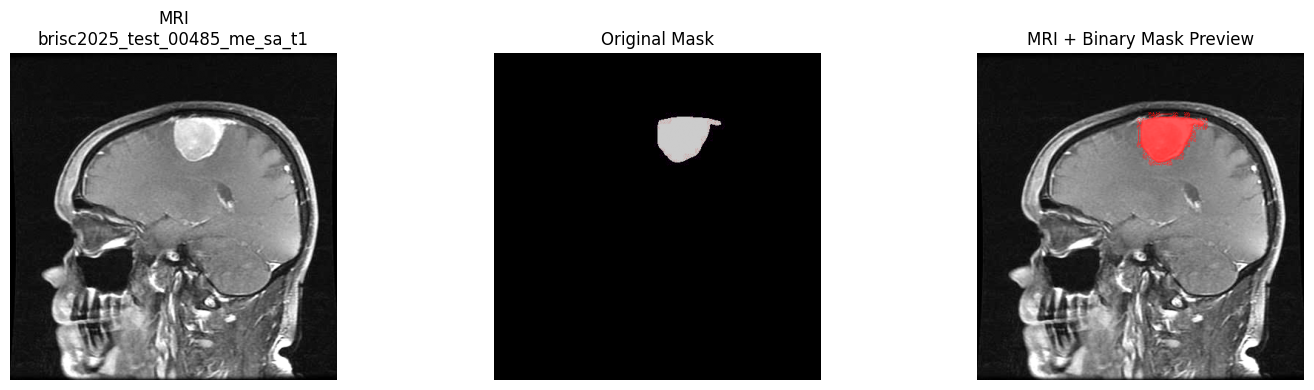

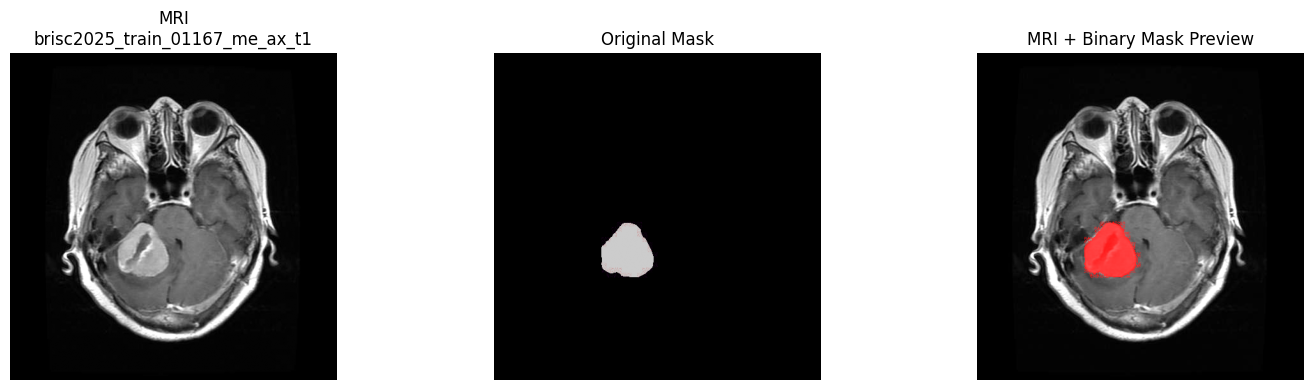

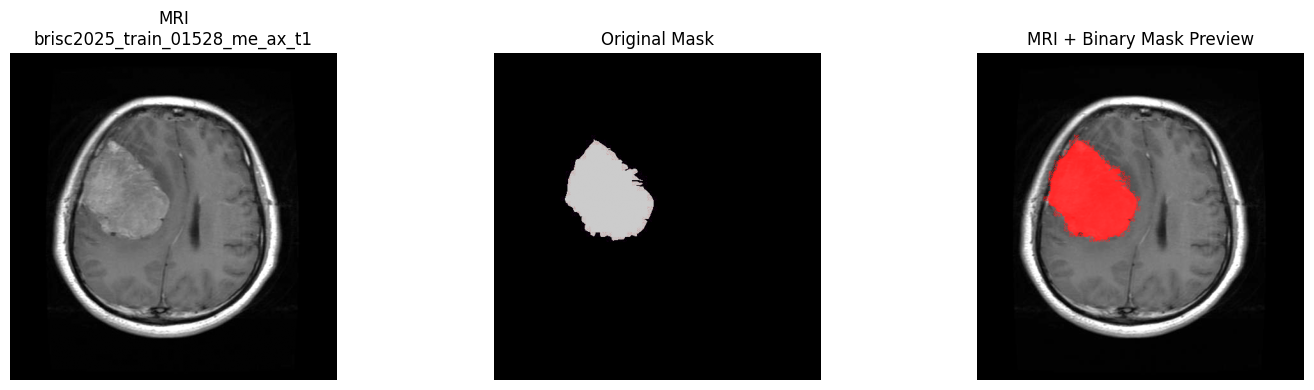


FOREGROUND PIXEL AUDIT

Minimum foreground ratio: 0.0004119873046875
Maximum foreground ratio: 0.1960936740841512
Mean foreground ratio: 0.01885059393875821
Median foreground ratio: 0.014286041259765625
P01 foreground ratio: 0.0022685241699218752
P99 foreground ratio: 0.08129160052721876

Masks with <0.1% foreground: 4
Masks with >50% foreground: 0

CROSS-SPLIT DUPLICATE CHECK

Cross-split duplicate images: 7
Cross-split duplicate masks: 0

MODEL 4A - STEP 2 COMPLETE

Audit saved:
/content/drive/MyDrive/Model4A/audit/model4a_step2_visual_mask_audit.json

IMPORTANT:
Review the displayed MRI / mask / overlay images.

The next preprocessing step will convert the BRISC mask representation into the correct binary segmentation target.

DO NOT TRAIN YET.


In [4]:
# =============================================================================
# MODEL 4A - STEP 2
# BRISC VISUAL SEGMENTATION + MASK ENCODING AUDIT
# =============================================================================

import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("=" * 80)
print("MODEL 4A - STEP 2")
print("BRISC VISUAL SEGMENTATION + MASK ENCODING AUDIT")
print("=" * 80)

# =============================================================================
# 1. PATHS
# =============================================================================

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/Model4A")

MANIFEST = (
    DRIVE_ROOT /
    "manifests" /
    "model4a_step1c_brisc_segmentation_manifest.csv"
)

AUDIT_DIR = DRIVE_ROOT / "audit"

print()
print("Manifest:")
print(MANIFEST)

if not MANIFEST.exists():
    raise FileNotFoundError(
        f"Manifest not found: {MANIFEST}"
    )

df = pd.read_csv(MANIFEST)

print()
print("Manifest rows:", len(df))

# =============================================================================
# 2. MASK MODE / PALETTE INSPECTION
# =============================================================================

print()
print("=" * 80)
print("MASK ENCODING INSPECTION")
print("=" * 80)

sample_rows = df.sample(
    min(10, len(df)),
    random_state=42
)

mode_counts = {}
palette_samples = {}

for row in sample_rows.itertuples(index=False):

    mask = Image.open(row.mask_path)

    mode_counts[mask.mode] = (
        mode_counts.get(mask.mode, 0) + 1
    )

    print()
    print("ID:", row.id)
    print("Mask mode:", mask.mode)
    print("Size:", mask.size)

    if mask.mode == "P":

        palette = mask.getpalette()

        print("Palette detected: YES")

        if palette is not None:

            rgb_colors = []

            for i in range(0, min(len(palette), 768), 3):

                rgb = tuple(
                    palette[i:i+3]
                )

                if len(rgb) == 3:
                    rgb_colors.append(rgb)

            unique_rgb = []

            for c in rgb_colors:

                if c not in unique_rgb:
                    unique_rgb.append(c)

            print(
                "Palette colors:",
                len(unique_rgb)
            )

            print(
                "First colors:",
                unique_rgb[:20]
            )

    else:

        print("Palette detected: NO")

print()
print("Mask modes:")
print(mode_counts)

# =============================================================================
# 3. UNIQUE RAW MASK VALUES
# =============================================================================

print()
print("=" * 80)
print("RAW MASK VALUE DISTRIBUTION")
print("=" * 80)

all_values = set()

for row in sample_rows.itertuples(index=False):

    mask = Image.open(row.mask_path)

    arr = np.asarray(mask)

    all_values.update(
        np.unique(arr).tolist()
    )

print()
print("Raw values found in sample:")

print(
    sorted(
        int(v)
        for v in all_values
    )
)

# =============================================================================
# 4. DISPLAY ORIGINAL MRI + ORIGINAL MASK
# =============================================================================

print()
print("=" * 80)
print("VISUAL MASK AUDIT")
print("=" * 80)

# Use 6 representative samples
visual_samples = df.sample(
    min(6, len(df)),
    random_state=123
)

for idx, row in enumerate(
    visual_samples.itertuples(index=False),
    start=1
):

    image = Image.open(
        row.image_path
    ).convert("L")

    mask_original = Image.open(
        row.mask_path
    )

    image_array = np.asarray(
        image,
        dtype=np.float32
    )

    mask_array = np.asarray(
        mask_original
    )

    # Normalize MRI only for display
    p1 = np.percentile(
        image_array,
        1
    )

    p99 = np.percentile(
        image_array,
        99
    )

    image_display = np.clip(
        (image_array - p1) /
        (p99 - p1 + 1e-8),
        0,
        1
    )

    # For visualization only:
    # any non-zero raw mask value = foreground
    binary_preview = (
        mask_array > 0
    ).astype(np.uint8)

    # Overlay
    overlay = np.stack(
        [
            image_display,
            image_display,
            image_display
        ],
        axis=-1
    )

    overlay[
        binary_preview == 1,
        0
    ] = 1.0

    overlay[
        binary_preview == 1,
        1
    ] *= 0.35

    overlay[
        binary_preview == 1,
        2
    ] *= 0.35

    plt.figure(
        figsize=(15, 4)
    )

    plt.subplot(1, 3, 1)

    plt.imshow(
        image_display,
        cmap="gray"
    )

    plt.title(
        f"MRI\n{row.id}"
    )

    plt.axis("off")

    plt.subplot(1, 3, 2)

    plt.imshow(
        mask_array,
        cmap="nipy_spectral"
    )

    plt.title(
        "Original Mask"
    )

    plt.axis("off")

    plt.subplot(1, 3, 3)

    plt.imshow(
        overlay
    )

    plt.title(
        "MRI + Binary Mask Preview"
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()

# =============================================================================
# 5. FOREGROUND PIXEL STATISTICS
# =============================================================================

print()
print("=" * 80)
print("FOREGROUND PIXEL AUDIT")
print("=" * 80)

foreground_ratios = []

for row in df.itertuples(index=False):

    mask = Image.open(
        row.mask_path
    )

    arr = np.asarray(mask)

    foreground = (
        arr > 0
    )

    ratio = (
        np.count_nonzero(foreground)
        /
        foreground.size
    )

    foreground_ratios.append(
        ratio
    )

foreground_ratios = np.asarray(
    foreground_ratios
)

print()
print(
    "Minimum foreground ratio:",
    float(np.min(foreground_ratios))
)

print(
    "Maximum foreground ratio:",
    float(np.max(foreground_ratios))
)

print(
    "Mean foreground ratio:",
    float(np.mean(foreground_ratios))
)

print(
    "Median foreground ratio:",
    float(np.median(foreground_ratios))
)

print(
    "P01 foreground ratio:",
    float(np.percentile(
        foreground_ratios,
        1
    ))
)

print(
    "P99 foreground ratio:",
    float(np.percentile(
        foreground_ratios,
        99
    ))
)

# =============================================================================
# 6. DETECT VERY SMALL / VERY LARGE MASKS
# =============================================================================

very_small = np.where(
    foreground_ratios < 0.001
)[0]

very_large = np.where(
    foreground_ratios > 0.50
)[0]

print()
print(
    "Masks with <0.1% foreground:",
    len(very_small)
)

print(
    "Masks with >50% foreground:",
    len(very_large)
)

# =============================================================================
# 7. DUPLICATE CROSS-SPLIT CHECK
# =============================================================================

print()
print("=" * 80)
print("CROSS-SPLIT DUPLICATE CHECK")
print("=" * 80)

import hashlib

def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()

image_hash_to_splits = {}
mask_hash_to_splits = {}

for row in df.itertuples(index=False):

    image_hash = sha256_file(
        row.image_path
    )

    mask_hash = sha256_file(
        row.mask_path
    )

    image_hash_to_splits.setdefault(
        image_hash,
        []
    ).append(
        row.split
    )

    mask_hash_to_splits.setdefault(
        mask_hash,
        []
    ).append(
        row.split
    )

cross_split_image_duplicates = []

for h, splits in image_hash_to_splits.items():

    if len(set(splits)) > 1:

        cross_split_image_duplicates.append(
            {
                "hash": h,
                "splits": sorted(set(splits)),
                "count": len(splits)
            }
        )

cross_split_mask_duplicates = []

for h, splits in mask_hash_to_splits.items():

    if len(set(splits)) > 1:

        cross_split_mask_duplicates.append(
            {
                "hash": h,
                "splits": sorted(set(splits)),
                "count": len(splits)
            }
        )

print()
print(
    "Cross-split duplicate images:",
    len(cross_split_image_duplicates)
)

print(
    "Cross-split duplicate masks:",
    len(cross_split_mask_duplicates)
)

# =============================================================================
# 8. SAVE AUDIT RESULTS
# =============================================================================

stats = {
    "total_pairs": int(len(df)),
    "mask_modes": mode_counts,
    "raw_mask_values_sample":
        sorted(
            int(v)
            for v in all_values
        ),
    "foreground_ratio_min":
        float(np.min(foreground_ratios)),
    "foreground_ratio_max":
        float(np.max(foreground_ratios)),
    "foreground_ratio_mean":
        float(np.mean(foreground_ratios)),
    "foreground_ratio_median":
        float(np.median(foreground_ratios)),
    "foreground_ratio_p01":
        float(np.percentile(
            foreground_ratios,
            1
        )),
    "foreground_ratio_p99":
        float(np.percentile(
            foreground_ratios,
            99
        )),
    "very_small_masks":
        int(len(very_small)),
    "very_large_masks":
        int(len(very_large)),
    "cross_split_image_duplicates":
        int(len(
            cross_split_image_duplicates
        )),
    "cross_split_mask_duplicates":
        int(len(
            cross_split_mask_duplicates
        ))
}

AUDIT_JSON = (
    AUDIT_DIR /
    "model4a_step2_visual_mask_audit.json"
)

with open(
    AUDIT_JSON,
    "w"
) as f:

    json.dump(
        stats,
        f,
        indent=2
    )

if cross_split_image_duplicates:

    pd.DataFrame(
        cross_split_image_duplicates
    ).to_csv(
        AUDIT_DIR /
        "cross_split_image_duplicates.csv",
        index=False
    )

if cross_split_mask_duplicates:

    pd.DataFrame(
        cross_split_mask_duplicates
    ).to_csv(
        AUDIT_DIR /
        "cross_split_mask_duplicates.csv",
        index=False
    )

# =============================================================================
# 9. FINAL STATUS
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 2 COMPLETE")
print("=" * 80)

print()
print("Audit saved:")
print(AUDIT_JSON)

print()
print("IMPORTANT:")
print("Review the displayed MRI / mask / overlay images.")
print()
print(
    "The next preprocessing step will convert the BRISC mask "
    "representation into the correct binary segmentation target."
)

print()
print(
    "DO NOT TRAIN YET."
)

print("=" * 80)

In [6]:
# =============================================================================
# MODEL 4A - STEP 3
# CROSS-SPLIT DUPLICATE + MASK ENCODING RESOLUTION
# =============================================================================

import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

print("=" * 80)
print("MODEL 4A - STEP 3")
print("DUPLICATE RESOLUTION + MASK ENCODING ANALYSIS")
print("=" * 80)

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/Model4A")

MANIFEST = (
    DRIVE_ROOT /
    "manifests" /
    "model4a_step1c_brisc_segmentation_manifest.csv"
)

AUDIT_DIR = DRIVE_ROOT / "audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(MANIFEST)

# =============================================================================
# 1. SHA256
# =============================================================================

def sha256_file(path, chunk_size=1024 * 1024):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# =============================================================================
# 2. FIND CROSS-SPLIT DUPLICATES
# =============================================================================

print()
print("=" * 80)
print("CROSS-SPLIT IMAGE DUPLICATES")
print("=" * 80)

hash_records = {}

for row in df.itertuples(index=False):

    h = sha256_file(row.image_path)

    hash_records.setdefault(
        h,
        []
    ).append(row)


cross_split_groups = []

for h, rows in hash_records.items():

    splits = set(
        r.split
        for r in rows
    )

    if len(splits) > 1:

        cross_split_groups.append(
            (h, rows)
        )

print()
print(
    "Cross-split duplicate groups:",
    len(cross_split_groups)
)

# =============================================================================
# 3. COMPARE DUPLICATE PAIRS
# =============================================================================

duplicate_analysis = []

for group_number, (image_hash, rows) in enumerate(
    cross_split_groups,
    start=1
):

    print()
    print("-" * 80)
    print(
        f"DUPLICATE GROUP {group_number}"
    )
    print("-" * 80)

    print(
        "Image SHA256:",
        image_hash
    )

    for r in rows:

        print(
            r.split,
            "|",
            r.id
        )

    # Compare masks
    mask_arrays = []

    for r in rows:

        mask = np.asarray(
            Image.open(
                r.mask_path
            )
        )

        mask_arrays.append(mask)

    masks_identical = True

    for i in range(1, len(mask_arrays)):

        if not np.array_equal(
            mask_arrays[0],
            mask_arrays[i]
        ):

            masks_identical = False

    print()
    print(
        "Masks identical:",
        masks_identical
    )

    duplicate_analysis.append(
        {
            "image_hash": image_hash,
            "ids": [
                r.id
                for r in rows
            ],
            "splits": [
                r.split
                for r in rows
            ],
            "masks_identical":
                masks_identical
        }
    )

# =============================================================================
# 4. MASK VALUE / INTENSITY ANALYSIS
# =============================================================================

print()
print("=" * 80)
print("MASK ENCODING ANALYSIS")
print("=" * 80)

# Use representative samples from each split
sample_df = df.sample(
    min(50, len(df)),
    random_state=2026
)

global_values = set()

# Count pixel values, not just number of files containing values
pixel_counts = {}

for row in sample_df.itertuples(index=False):

    mask = np.asarray(
        Image.open(row.mask_path)
    )

    values, counts = np.unique(
        mask,
        return_counts=True
    )

    for v, c in zip(
        values,
        counts
    ):

        v = int(v)

        pixel_counts[v] = (
            pixel_counts.get(v, 0)
            + int(c)
        )

        global_values.add(v)

print()
print(
    "Unique values in 50-mask sample:"
)

print(
    sorted(global_values)
)

print()
print("Pixel count by value:")

for value in sorted(pixel_counts):

    print(
        f"{value:3d}: "
        f"{pixel_counts[value]:,}"
    )

# =============================================================================
# 5. TEST COMMON BINARY CONVERSIONS
# =============================================================================

print()
print("=" * 80)
print("BINARY MASK CONVERSION ANALYSIS")
print("=" * 80)

conversion_results = []

for threshold in [
    0,
    1,
    10,
    128,
    240,
    245,
    246,
    247,
    248,
    249,
    250,
    251,
    252,
    253,
    254
]:

    ratios = []

    for row in sample_df.itertuples(index=False):

        mask = np.asarray(
            Image.open(
                row.mask_path
            )
        )

        binary = (
            mask > threshold
        )

        ratio = (
            np.count_nonzero(binary)
            /
            binary.size
        )

        ratios.append(
            ratio
        )

    ratios = np.asarray(
        ratios
    )

    conversion_results.append(
        {
            "threshold": threshold,
            "mean_foreground":
                float(np.mean(ratios)),
            "median_foreground":
                float(np.median(ratios)),
            "min_foreground":
                float(np.min(ratios)),
            "max_foreground":
                float(np.max(ratios))
        }
    )

conversion_df = pd.DataFrame(
    conversion_results
)

print()
print(conversion_df.to_string(
    index=False
))

# =============================================================================
# 6. PIXEL VALUE TRANSITION ANALYSIS
# =============================================================================

print()
print("=" * 80)
print("MASK PIXEL GROUPING")
print("=" * 80)

low_values = sorted(
    [
        v for v in global_values
        if v <= 10
    ]
)

high_values = sorted(
    [
        v for v in global_values
        if v >= 240
    ]
)

print()
print(
    "Low-value mask pixels:",
    low_values
)

print(
    "High-value mask pixels:",
    high_values
)

# =============================================================================
# 7. SAVE RESULTS
# =============================================================================

duplicate_path = (
    AUDIT_DIR /
    "step3_cross_split_duplicate_analysis.json"
)

with open(
    duplicate_path,
    "w"
) as f:

    json.dump(
        duplicate_analysis,
        f,
        indent=2
    )

conversion_path = (
    AUDIT_DIR /
    "step3_mask_conversion_analysis.csv"
)

conversion_df.to_csv(
    conversion_path,
    index=False
)

summary = {

    "cross_split_duplicate_groups":
        len(cross_split_groups),

    "duplicate_analysis":
        duplicate_analysis,

    "sample_mask_values":
        sorted(
            int(v)
            for v in global_values
        ),

    "low_values":
        low_values,

    "high_values":
        high_values
}

summary_path = (
    AUDIT_DIR /
    "model4a_step3_resolution.json"
)

with open(
    summary_path,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# =============================================================================
# 8. FINAL DECISION
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 3 COMPLETE")
print("=" * 80)

print()
print(
    "Cross-split duplicate groups:",
    len(cross_split_groups)
)

print()
print(
    "Duplicate analysis:"
)
print(duplicate_path)

print()
print(
    "Mask conversion analysis:"
)
print(conversion_path)

print()
print(
    "Resolution report:"
)
print(summary_path)

print()
print("⚠️ DO NOT TRAIN YET.")
print(
    "We will use this result to finalize the "
    "train/test cleanup and mask conversion."
)

print("=" * 80)

MODEL 4A - STEP 3
DUPLICATE RESOLUTION + MASK ENCODING ANALYSIS
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

CROSS-SPLIT IMAGE DUPLICATES

Cross-split duplicate groups: 7

--------------------------------------------------------------------------------
DUPLICATE GROUP 1
--------------------------------------------------------------------------------
Image SHA256: 960155b05ea8f0ddcbcd3a5e29905c2a4b55832f03e5b7d6491c73955960d278
train | brisc2025_train_01210_me_ax_t1
test | brisc2025_test_00344_me_ax_t1

Masks identical: False

--------------------------------------------------------------------------------
DUPLICATE GROUP 2
--------------------------------------------------------------------------------
Image SHA256: f3d00bbb942117c2fb62466414d3c466ca283b678200fe87424e4128b80b2dba
train | brisc2025_train_01304_me_ax_t1
test | brisc2025_test_00352_me_ax_t1

Masks identical: False

-----------------------

In [7]:
# =============================================================================
# MODEL 4A - STEP 4
# CLEAN DATASET SPLIT + VALIDATION MANIFEST
# =============================================================================

import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd

print("=" * 80)
print("MODEL 4A - STEP 4")
print("CLEAN DATASET SPLIT + VALIDATION MANIFEST")
print("=" * 80)

from google.colab import drive
drive.mount("/content/drive")

# =============================================================================
# PATHS
# =============================================================================

DRIVE_ROOT = Path("/content/drive/MyDrive/Model4A")

OLD_MANIFEST = (
    DRIVE_ROOT /
    "manifests" /
    "model4a_step1c_brisc_segmentation_manifest.csv"
)

NEW_MANIFEST = (
    DRIVE_ROOT /
    "manifests" /
    "model4a_step4_clean_split_manifest.csv"
)

AUDIT_DIR = (
    DRIVE_ROOT /
    "audit" /
    "step4"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print()
print("Original manifest:")
print(OLD_MANIFEST)

if not OLD_MANIFEST.exists():
    raise FileNotFoundError(
        f"Manifest not found:\n{OLD_MANIFEST}"
    )

df = pd.read_csv(OLD_MANIFEST)

print()
print("Original samples:", len(df))

# =============================================================================
# SHA256 FUNCTION
# =============================================================================

def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# =============================================================================
# 1. HASH ALL IMAGES
# =============================================================================

print()
print("=" * 80)
print("STEP 4A - HASHING IMAGES")
print("=" * 80)

image_hashes = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    image_hashes.append(
        sha256_file(row.image_path)
    )

    if i % 500 == 0 or i == len(df):

        print(
            f"[{i}/{len(df)}]"
        )

df["image_sha256"] = image_hashes

print()
print("✅ Image hashing complete")


# =============================================================================
# 2. IDENTIFY DUPLICATES
# =============================================================================

print()
print("=" * 80)
print("IDENTIFYING CROSS-SPLIT DUPLICATES")
print("=" * 80)

train_df = df[
    df["split"].astype(str).str.lower() == "train"
].copy()

test_df = df[
    df["split"].astype(str).str.lower() == "test"
].copy()

train_hashes = set(
    train_df["image_sha256"]
)

test_hashes = set(
    test_df["image_sha256"]
)

cross_split_hashes = (
    train_hashes &
    test_hashes
)

print()
print(
    "Train samples:",
    len(train_df)
)

print(
    "Test samples:",
    len(test_df)
)

print(
    "Cross-split duplicate groups:",
    len(cross_split_hashes)
)


# =============================================================================
# 3. REMOVE DUPLICATE TEST COPIES
# =============================================================================

print()
print("=" * 80)
print("REMOVING TEST-SIDE DUPLICATE COPIES")
print("=" * 80)

duplicate_test_mask = (
    test_df["image_sha256"].isin(
        cross_split_hashes
    )
)

duplicate_test_df = test_df[
    duplicate_test_mask
].copy()

clean_test_df = test_df[
    ~duplicate_test_mask
].copy()

print()
print(
    "Duplicate test samples removed:",
    len(duplicate_test_df)
)

print(
    "Clean test samples:",
    len(clean_test_df)
)

if len(duplicate_test_df) > 0:

    print()
    print("Removed test IDs:")

    for x in duplicate_test_df["id"]:

        print(
            " -",
            x
        )

# Save removed records
duplicate_test_df.to_csv(
    AUDIT_DIR /
    "removed_test_duplicates.csv",
    index=False
)


# =============================================================================
# 4. CREATE VALIDATION SPLIT FROM TRAIN ONLY
# =============================================================================

print()
print("=" * 80)
print("CREATING VALIDATION SPLIT")
print("=" * 80)

# IMPORTANT:
# Validation comes ONLY from original training data.
# Test never participates.

clean_train_source = train_df.copy()

# Stratified 15% validation split
from sklearn.model_selection import train_test_split

train_final, validation_final = train_test_split(
    clean_train_source,
    test_size=0.15,
    random_state=42,
    stratify=clean_train_source["class_name"]
)

train_final = train_final.copy()
validation_final = validation_final.copy()

train_final["split"] = "train"
validation_final["split"] = "validation"
clean_test_df["split"] = "test"


# =============================================================================
# 5. COMBINE
# =============================================================================

final_df = pd.concat(
    [
        train_final,
        validation_final,
        clean_test_df
    ],
    ignore_index=True
)

# Deterministic ordering
final_df = final_df.sort_values(
    [
        "split",
        "class_name",
        "id"
    ]
).reset_index(drop=True)


# =============================================================================
# 6. BASIC DISTRIBUTION
# =============================================================================

print()
print("=" * 80)
print("FINAL SPLIT DISTRIBUTION")
print("=" * 80)

print()
print(
    final_df["split"].value_counts()
)

print()
print(
    "Class × split:"
)

print(
    pd.crosstab(
        final_df["split"],
        final_df["class_name"]
    )
)


# =============================================================================
# 7. VERIFY IDS
# =============================================================================

print()
print("=" * 80)
print("ID LEAKAGE CHECK")
print("=" * 80)

train_ids = set(
    final_df.loc[
        final_df["split"] == "train",
        "id"
    ]
)

val_ids = set(
    final_df.loc[
        final_df["split"] == "validation",
        "id"
    ]
)

test_ids = set(
    final_df.loc[
        final_df["split"] == "test",
        "id"
    ]
)

train_val_overlap = (
    train_ids & val_ids
)

train_test_overlap = (
    train_ids & test_ids
)

val_test_overlap = (
    val_ids & test_ids
)

print()
print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_overlap)
)


# =============================================================================
# 8. VERIFY IMAGE HASH LEAKAGE
# =============================================================================

print()
print("=" * 80)
print("IMAGE HASH LEAKAGE CHECK")
print("=" * 80)

def get_hash_set(
    dataframe,
    split_name
):

    return set(
        dataframe.loc[
            dataframe["split"] == split_name,
            "image_sha256"
        ]
    )

train_hashes_final = get_hash_set(
    final_df,
    "train"
)

val_hashes_final = get_hash_set(
    final_df,
    "validation"
)

test_hashes_final = get_hash_set(
    final_df,
    "test"
)

hash_train_val = (
    train_hashes_final &
    val_hashes_final
)

hash_train_test = (
    train_hashes_final &
    test_hashes_final
)

hash_val_test = (
    val_hashes_final &
    test_hashes_final
)

print()
print(
    "Train ∩ Validation image hashes:",
    len(hash_train_val)
)

print(
    "Train ∩ Test image hashes:",
    len(hash_train_test)
)

print(
    "Validation ∩ Test image hashes:",
    len(hash_val_test)
)


# =============================================================================
# 9. VERIFY FILE EXISTENCE
# =============================================================================

print()
print("=" * 80)
print("VERIFYING FINAL FILES")
print("=" * 80)

missing_images = []
missing_masks = []

for i, row in enumerate(
    final_df.itertuples(index=False),
    start=1
):

    image_path = Path(
        row.image_path
    )

    mask_path = Path(
        row.mask_path
    )

    if not image_path.exists():

        missing_images.append(
            row.id
        )

    if not mask_path.exists():

        missing_masks.append(
            row.id
        )

    if i % 1000 == 0 or i == len(final_df):

        print(
            f"[{i}/{len(final_df)}]"
        )

print()
print(
    "Missing images:",
    len(missing_images)
)

print(
    "Missing masks:",
    len(missing_masks)
)


# =============================================================================
# 10. DUPLICATE CHECK WITHIN EACH SPLIT
# =============================================================================

print()
print("=" * 80)
print("WITHIN-SPLIT DUPLICATE CHECK")
print("=" * 80)

within_split_duplicates = {}

for split_name in [
    "train",
    "validation",
    "test"
]:

    subset = final_df[
        final_df["split"] == split_name
    ]

    duplicate_count = (
        subset["image_sha256"]
        .duplicated()
        .sum()
    )

    within_split_duplicates[
        split_name
    ] = int(
        duplicate_count
    )

    print(
        split_name,
        ":",
        duplicate_count
    )


# =============================================================================
# 11. FINAL VALIDATION
# =============================================================================

print()
print("=" * 80)
print("FINAL SAFETY CHECK")
print("=" * 80)

errors = []

if len(hash_train_val) != 0:
    errors.append(
        "Train/validation image leakage"
    )

if len(hash_train_test) != 0:
    errors.append(
        "Train/test image leakage"
    )

if len(hash_val_test) != 0:
    errors.append(
        "Validation/test image leakage"
    )

if len(train_val_overlap) != 0:
    errors.append(
        "Train/validation ID overlap"
    )

if len(train_test_overlap) != 0:
    errors.append(
        "Train/test ID overlap"
    )

if len(val_test_overlap) != 0:
    errors.append(
        "Validation/test ID overlap"
    )

if len(missing_images) != 0:
    errors.append(
        "Missing images"
    )

if len(missing_masks) != 0:
    errors.append(
        "Missing masks"
    )

if errors:

    print()
    print("❌ SAFETY CHECK FAILED")

    for error in errors:

        print(
            " -",
            error
        )

    raise RuntimeError(
        "Dataset safety checks failed."
    )

else:

    print()
    print(
        "✅ NO CROSS-SPLIT IMAGE LEAKAGE"
    )

    print(
        "✅ NO CROSS-SPLIT ID LEAKAGE"
    )

    print(
        "✅ NO MISSING IMAGES"
    )

    print(
        "✅ NO MISSING MASKS"
    )


# =============================================================================
# 12. SAVE FINAL MANIFEST
# =============================================================================

final_df.to_csv(
    NEW_MANIFEST,
    index=False
)

# =============================================================================
# 13. SAVE SUMMARY
# =============================================================================

summary = {

    "original_samples":
        int(len(df)),

    "original_train":
        int(len(train_df)),

    "original_test":
        int(len(test_df)),

    "cross_split_duplicate_groups":
        int(len(cross_split_hashes)),

    "removed_test_duplicates":
        int(len(duplicate_test_df)),

    "final_train":
        int(
            len(
                final_df[
                    final_df["split"] == "train"
                ]
            )
        ),

    "final_validation":
        int(
            len(
                final_df[
                    final_df["split"] == "validation"
                ]
            )
        ),

    "final_test":
        int(
            len(
                final_df[
                    final_df["split"] == "test"
                ]
            )
        ),

    "train_validation_hash_overlap":
        int(len(hash_train_val)),

    "train_test_hash_overlap":
        int(len(hash_train_test)),

    "validation_test_hash_overlap":
        int(len(hash_val_test)),

    "missing_images":
        int(len(missing_images)),

    "missing_masks":
        int(len(missing_masks)),

    "within_split_duplicates":
        within_split_duplicates
}

SUMMARY_PATH = (
    AUDIT_DIR /
    "model4a_step4_clean_split_summary.json"
)

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# =============================================================================
# 14. FINAL OUTPUT
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 4 COMPLETE")
print("=" * 80)

print()
print(
    "Original samples:",
    len(df)
)

print(
    "Removed test duplicates:",
    len(duplicate_test_df)
)

print()
print(
    "FINAL TRAIN:",
    len(train_final)
)

print(
    "FINAL VALIDATION:",
    len(validation_final)
)

print(
    "FINAL TEST:",
    len(clean_test_df)
)

print()
print(
    "Final total:",
    len(final_df)
)

print()
print("Final manifest:")
print(NEW_MANIFEST)

print()
print("Summary:")
print(SUMMARY_PATH)

print()
print("Removed duplicates:")
print(
    AUDIT_DIR /
    "removed_test_duplicates.csv"
)

print()
print("=" * 80)
print("✅ CLEAN DATASET SPLIT CREATED")
print("✅ READY FOR STEP 5")
print("=" * 80)

MODEL 4A - STEP 4
CLEAN DATASET SPLIT + VALIDATION MANIFEST
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Original manifest:
/content/drive/MyDrive/Model4A/manifests/model4a_step1c_brisc_segmentation_manifest.csv

Original samples: 4793

STEP 4A - HASHING IMAGES
[500/4793]
[1000/4793]
[1500/4793]
[2000/4793]
[2500/4793]
[3000/4793]
[3500/4793]
[4000/4793]
[4500/4793]
[4793/4793]

✅ Image hashing complete

IDENTIFYING CROSS-SPLIT DUPLICATES

Train samples: 3933
Test samples: 860
Cross-split duplicate groups: 7

REMOVING TEST-SIDE DUPLICATE COPIES

Duplicate test samples removed: 7
Clean test samples: 853

Removed test IDs:
 - brisc2025_test_00344_me_ax_t1
 - brisc2025_test_00352_me_ax_t1
 - brisc2025_test_00737_pi_ax_t1
 - brisc2025_test_00751_pi_ax_t1
 - brisc2025_test_00825_pi_co_t1
 - brisc2025_test_00827_pi_co_t1
 - brisc2025_test_00834_pi_co_t1

CREATING VALIDATION SPLIT


KeyError: 'class_name'

In [8]:
# =============================================================================
# MODEL 4A - STEP 4 FIX
# CLEAN DATASET SPLIT + VALIDATION MANIFEST
# ROBUST COLUMN DETECTION
# =============================================================================

import hashlib
import json
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

print("=" * 80)
print("MODEL 4A - STEP 4 FIX")
print("CLEAN DATASET SPLIT + VALIDATION MANIFEST")
print("=" * 80)

# =============================================================================
# 1. DRIVE
# =============================================================================

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Model4A"
)

OLD_MANIFEST = (
    DRIVE_ROOT /
    "manifests" /
    "model4a_step1c_brisc_segmentation_manifest.csv"
)

NEW_MANIFEST = (
    DRIVE_ROOT /
    "manifests" /
    "model4a_step4_clean_split_manifest.csv"
)

AUDIT_DIR = (
    DRIVE_ROOT /
    "audit" /
    "step4"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# 2. LOAD MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING ORIGINAL MANIFEST")
print("=" * 80)

if not OLD_MANIFEST.exists():

    raise FileNotFoundError(
        f"\nManifest not found:\n{OLD_MANIFEST}"
    )

df = pd.read_csv(
    OLD_MANIFEST
)

print()
print(
    "Manifest:",
    OLD_MANIFEST
)

print(
    "Rows:",
    len(df)
)

print()
print("Columns:")
for col in df.columns:
    print(" -", col)

# =============================================================================
# 3. NORMALIZE COLUMN NAMES
# =============================================================================

df.columns = [
    str(c).strip()
    for c in df.columns
]

# Find class column
class_candidates = [
    "class_name",
    "class",
    "label",
    "category",
    "tumor_type"
]

CLASS_COL = None

for candidate in class_candidates:

    if candidate in df.columns:

        CLASS_COL = candidate
        break

if CLASS_COL is None:

    raise KeyError(
        "\nCould not find class column.\n"
        f"Available columns: {list(df.columns)}\n"
        "Expected one of: "
        f"{class_candidates}"
    )

print()
print(
    "Class column detected:",
    CLASS_COL
)

# =============================================================================
# 4. FIND SPLIT COLUMN
# =============================================================================

split_candidates = [
    "split",
    "dataset_split",
    "subset"
]

SPLIT_COL = None

for candidate in split_candidates:

    if candidate in df.columns:

        SPLIT_COL = candidate
        break

if SPLIT_COL is None:

    raise KeyError(
        "\nCould not find split column.\n"
        f"Available columns: {list(df.columns)}"
    )

print(
    "Split column detected:",
    SPLIT_COL
)

# =============================================================================
# 5. NORMALIZE SPLIT VALUES
# =============================================================================

df[SPLIT_COL] = (
    df[SPLIT_COL]
    .astype(str)
    .str.strip()
    .str.lower()
)

print()
print("Original split distribution:")
print(
    df[SPLIT_COL].value_counts()
)

# =============================================================================
# 6. HASH IMAGES
# =============================================================================

print()
print("=" * 80)
print("HASHING IMAGES")
print("=" * 80)

# Find image path column
image_candidates = [
    "image_path",
    "image",
    "img_path",
    "path"
]

IMAGE_COL = None

for candidate in image_candidates:

    if candidate in df.columns:

        IMAGE_COL = candidate
        break

if IMAGE_COL is None:

    raise KeyError(
        "\nCould not find image path column.\n"
        f"Available columns: {list(df.columns)}"
    )

print(
    "Image column:",
    IMAGE_COL
)


def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


image_hashes = []

for i, path in enumerate(
    df[IMAGE_COL],
    start=1
):

    path = Path(path)

    if not path.exists():

        raise FileNotFoundError(
            f"\nImage not found:\n{path}"
        )

    image_hashes.append(
        sha256_file(path)
    )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

df["image_sha256"] = image_hashes

print()
print("✅ Image hashing complete")

# =============================================================================
# 7. SEPARATE ORIGINAL TRAIN / TEST
# =============================================================================

train_df = df[
    df[SPLIT_COL] == "train"
].copy()

test_df = df[
    df[SPLIT_COL] == "test"
].copy()

print()
print("=" * 80)
print("ORIGINAL DATA")
print("=" * 80)

print(
    "Train:",
    len(train_df)
)

print(
    "Test:",
    len(test_df)
)

# =============================================================================
# 8. FIND CROSS-SPLIT DUPLICATES
# =============================================================================

train_hashes = set(
    train_df["image_sha256"]
)

test_hashes = set(
    test_df["image_sha256"]
)

cross_split_hashes = (
    train_hashes &
    test_hashes
)

print()
print(
    "Cross-split duplicate groups:",
    len(cross_split_hashes)
)

# =============================================================================
# 9. REMOVE DUPLICATE TEST COPIES
# =============================================================================

duplicate_test_df = test_df[
    test_df["image_sha256"].isin(
        cross_split_hashes
    )
].copy()

clean_test_df = test_df[
    ~test_df["image_sha256"].isin(
        cross_split_hashes
    )
].copy()

print()
print(
    "Duplicate test rows removed:",
    len(duplicate_test_df)
)

print(
    "Clean test rows:",
    len(clean_test_df)
)

if len(duplicate_test_df) > 0:

    print()
    print("Removed test IDs:")

    id_col = (
        "id"
        if "id" in df.columns
        else None
    )

    if id_col:

        for x in duplicate_test_df[id_col]:
            print(
                " -",
                x
            )

duplicate_test_df.to_csv(
    AUDIT_DIR /
    "removed_test_duplicates.csv",
    index=False
)

# =============================================================================
# 10. CREATE VALIDATION FROM ORIGINAL TRAIN ONLY
# =============================================================================

print()
print("=" * 80)
print("CREATING VALIDATION SPLIT")
print("=" * 80)

# IMPORTANT:
# Only ORIGINAL TRAIN data is used here.
# TEST data is completely isolated.

clean_train_source = train_df.copy()

print()
print(
    "Training source:",
    len(clean_train_source)
)

print()
print("Training class distribution:")

print(
    clean_train_source[
        CLASS_COL
    ].value_counts()
)

# 15% validation
train_final, validation_final = train_test_split(
    clean_train_source,
    test_size=0.15,
    random_state=42,
    stratify=clean_train_source[
        CLASS_COL
    ]
)

train_final = train_final.copy()
validation_final = validation_final.copy()
clean_test_df = clean_test_df.copy()

train_final[SPLIT_COL] = "train"
validation_final[SPLIT_COL] = "validation"
clean_test_df[SPLIT_COL] = "test"

print()
print(
    "Train:",
    len(train_final)
)

print(
    "Validation:",
    len(validation_final)
)

print(
    "Test:",
    len(clean_test_df)
)

# =============================================================================
# 11. COMBINE
# =============================================================================

final_df = pd.concat(
    [
        train_final,
        validation_final,
        clean_test_df
    ],
    ignore_index=True
)

final_df = final_df.sort_values(
    [
        SPLIT_COL,
        CLASS_COL
    ]
).reset_index(
    drop=True
)

# =============================================================================
# 12. CLASS × SPLIT
# =============================================================================

print()
print("=" * 80)
print("FINAL CLASS × SPLIT")
print("=" * 80)

print(
    pd.crosstab(
        final_df[SPLIT_COL],
        final_df[CLASS_COL]
    )
)

# =============================================================================
# 13. ID LEAKAGE CHECK
# =============================================================================

print()
print("=" * 80)
print("ID LEAKAGE CHECK")
print("=" * 80)

ID_COL = None

for candidate in [
    "id",
    "patient_id",
    "image_id"
]:

    if candidate in final_df.columns:

        ID_COL = candidate
        break

if ID_COL:

    train_ids = set(
        final_df.loc[
            final_df[SPLIT_COL] == "train",
            ID_COL
        ]
    )

    val_ids = set(
        final_df.loc[
            final_df[SPLIT_COL] == "validation",
            ID_COL
        ]
    )

    test_ids = set(
        final_df.loc[
            final_df[SPLIT_COL] == "test",
            ID_COL
        ]
    )

    print(
        "Train ∩ Validation:",
        len(train_ids & val_ids)
    )

    print(
        "Train ∩ Test:",
        len(train_ids & test_ids)
    )

    print(
        "Validation ∩ Test:",
        len(val_ids & test_ids)
    )

# =============================================================================
# 14. IMAGE HASH LEAKAGE CHECK
# =============================================================================

print()
print("=" * 80)
print("IMAGE HASH LEAKAGE CHECK")
print("=" * 80)

train_hashes_final = set(
    final_df.loc[
        final_df[SPLIT_COL] == "train",
        "image_sha256"
    ]
)

val_hashes_final = set(
    final_df.loc[
        final_df[SPLIT_COL] == "validation",
        "image_sha256"
    ]
)

test_hashes_final = set(
    final_df.loc[
        final_df[SPLIT_COL] == "test",
        "image_sha256"
    ]
)

train_val_overlap = (
    train_hashes_final &
    val_hashes_final
)

train_test_overlap = (
    train_hashes_final &
    test_hashes_final
)

val_test_overlap = (
    val_hashes_final &
    test_hashes_final
)

print()
print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_overlap)
)

# =============================================================================
# 15. MASK COLUMN CHECK
# =============================================================================

MASK_COL = None

for candidate in [
    "mask_path",
    "mask",
    "segmentation_path"
]:

    if candidate in final_df.columns:

        MASK_COL = candidate
        break

if MASK_COL is None:

    raise KeyError(
        "\nCould not find mask path column.\n"
        f"Available columns: {list(final_df.columns)}"
    )

print()
print(
    "Mask column:",
    MASK_COL
)

# =============================================================================
# 16. VERIFY FILES
# =============================================================================

print()
print("=" * 80)
print("VERIFYING FINAL FILES")
print("=" * 80)

missing_images = []
missing_masks = []

for i, row in enumerate(
    final_df.itertuples(index=False),
    start=1
):

    image_path = Path(
        getattr(row, IMAGE_COL)
    )

    mask_path = Path(
        getattr(row, MASK_COL)
    )

    if not image_path.exists():

        missing_images.append(
            i
        )

    if not mask_path.exists():

        missing_masks.append(
            i
        )

    if (
        i % 1000 == 0
        or i == len(final_df)
    ):

        print(
            f"[{i}/{len(final_df)}]"
        )

print()
print(
    "Missing images:",
    len(missing_images)
)

print(
    "Missing masks:",
    len(missing_masks)
)

# =============================================================================
# 17. FINAL SAFETY CHECK
# =============================================================================

print()
print("=" * 80)
print("FINAL SAFETY CHECK")
print("=" * 80)

errors = []

if len(train_val_overlap) != 0:
    errors.append(
        "Train/validation image leakage"
    )

if len(train_test_overlap) != 0:
    errors.append(
        "Train/test image leakage"
    )

if len(val_test_overlap) != 0:
    errors.append(
        "Validation/test image leakage"
    )

if len(missing_images) != 0:
    errors.append(
        "Missing images"
    )

if len(missing_masks) != 0:
    errors.append(
        "Missing masks"
    )

if errors:

    print()
    print(
        "❌ SAFETY CHECK FAILED"
    )

    for error in errors:

        print(
            " -",
            error
        )

    raise RuntimeError(
        "Dataset safety checks failed."
    )

print()
print(
    "✅ NO CROSS-SPLIT IMAGE LEAKAGE"
)

print(
    "✅ NO MISSING IMAGES"
)

print(
    "✅ NO MISSING MASKS"
)

# =============================================================================
# 18. SAVE FINAL MANIFEST
# =============================================================================

final_df.to_csv(
    NEW_MANIFEST,
    index=False
)

# =============================================================================
# 19. SAVE SUMMARY
# =============================================================================

summary = {

    "original_samples":
        int(len(df)),

    "original_train":
        int(len(train_df)),

    "original_test":
        int(len(test_df)),

    "duplicate_groups":
        int(len(cross_split_hashes)),

    "removed_test_rows":
        int(len(duplicate_test_df)),

    "final_train":
        int(len(train_final)),

    "final_validation":
        int(len(validation_final)),

    "final_test":
        int(len(clean_test_df)),

    "final_total":
        int(len(final_df)),

    "train_validation_overlap":
        int(len(train_val_overlap)),

    "train_test_overlap":
        int(len(train_test_overlap)),

    "validation_test_overlap":
        int(len(val_test_overlap)),

    "missing_images":
        int(len(missing_images)),

    "missing_masks":
        int(len(missing_masks))
}

SUMMARY_PATH = (
    AUDIT_DIR /
    "model4a_step4_clean_split_summary.json"
)

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# =============================================================================
# 20. COMPLETE
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 4 COMPLETE")
print("=" * 80)

print()
print(
    "Original:",
    len(df)
)

print(
    "Removed test duplicates:",
    len(duplicate_test_df)
)

print()
print(
    "FINAL TRAIN:",
    len(train_final)
)

print(
    "FINAL VALIDATION:",
    len(validation_final)
)

print(
    "FINAL TEST:",
    len(clean_test_df)
)

print(
    "FINAL TOTAL:",
    len(final_df)
)

print()
print(
    "Final manifest:"
)

print(
    NEW_MANIFEST
)

print()
print(
    "Summary:"
)

print(
    SUMMARY_PATH
)

print()
print(
    "✅ CLEAN SPLIT CREATED"
)

print(
    "NEXT → STEP 5: MASK NORMALIZATION + TRAINING PREPROCESSING"
)

print("=" * 80)

MODEL 4A - STEP 4 FIX
CLEAN DATASET SPLIT + VALIDATION MANIFEST
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING ORIGINAL MANIFEST

Manifest: /content/drive/MyDrive/Model4A/manifests/model4a_step1c_brisc_segmentation_manifest.csv
Rows: 4793

Columns:
 - split
 - id
 - image_path
 - mask_path


KeyError: "\nCould not find class column.\nAvailable columns: ['split', 'id', 'image_path', 'mask_path']\nExpected one of: ['class_name', 'class', 'label', 'category', 'tumor_type']"

In [9]:
# =============================================================================
# MODEL 4A - STEP 4 FINAL
# CLEAN SEGMENTATION SPLIT
# NO CLASS COLUMN REQUIRED
# =============================================================================

import hashlib
import json
from pathlib import Path

import pandas as pd

from sklearn.model_selection import train_test_split

print("=" * 80)
print("MODEL 4A - STEP 4 FINAL")
print("CLEAN SEGMENTATION SPLIT")
print("=" * 80)

# =============================================================================
# 1. DRIVE
# =============================================================================

from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Model4A"
)

MANIFEST = (
    DRIVE_ROOT
    / "manifests"
    / "model4a_step1c_brisc_segmentation_manifest.csv"
)

OUTPUT_MANIFEST = (
    DRIVE_ROOT
    / "manifests"
    / "model4a_step4_final_segmentation_manifest.csv"
)

AUDIT_DIR = (
    DRIVE_ROOT
    / "audit"
    / "step4"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# 2. LOAD MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING MANIFEST")
print("=" * 80)

if not MANIFEST.exists():
    raise FileNotFoundError(
        f"Manifest not found:\n{MANIFEST}"
    )

df = pd.read_csv(MANIFEST)

df.columns = [
    str(c).strip()
    for c in df.columns
]

print()
print("Rows:", len(df))

print()
print("Columns:")
for c in df.columns:
    print(" -", c)

# =============================================================================
# 3. REQUIRED SEGMENTATION COLUMNS
# =============================================================================

required_columns = [
    "split",
    "id",
    "image_path",
    "mask_path"
]

missing_columns = [
    c
    for c in required_columns
    if c not in df.columns
]

if missing_columns:

    raise KeyError(
        "Missing required columns: "
        + str(missing_columns)
    )

print()
print(
    "✅ Segmentation manifest structure valid"
)

# =============================================================================
# 4. NORMALIZE SPLITS
# =============================================================================

df["split"] = (
    df["split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print()
print("Original split distribution:")

print(
    df["split"].value_counts()
)

# =============================================================================
# 5. VERIFY ALL FILES FIRST
# =============================================================================

print()
print("=" * 80)
print("VERIFYING IMAGE / MASK FILES")
print("=" * 80)

missing_images = []
missing_masks = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    image_path = Path(
        row.image_path
    )

    mask_path = Path(
        row.mask_path
    )

    if not image_path.exists():

        missing_images.append(
            row.id
        )

    if not mask_path.exists():

        missing_masks.append(
            row.id
        )

    if (
        i % 1000 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

print()
print(
    "Missing images:",
    len(missing_images)
)

print(
    "Missing masks:",
    len(missing_masks)
)

if missing_images or missing_masks:

    raise RuntimeError(
        "Missing image/mask files detected."
    )

print(
    "✅ ALL IMAGE/MASK FILES FOUND"
)

# =============================================================================
# 6. HASH IMAGES
# =============================================================================

print()
print("=" * 80)
print("HASHING MRI IMAGES")
print("=" * 80)


def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


image_hashes = []

for i, path in enumerate(
    df["image_path"],
    start=1
):

    image_hashes.append(
        sha256_file(path)
    )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

df["image_sha256"] = image_hashes

print()
print(
    "✅ IMAGE HASHING COMPLETE"
)

# =============================================================================
# 7. SPLIT DATA
# =============================================================================

train_original = df[
    df["split"] == "train"
].copy()

test_original = df[
    df["split"] == "test"
].copy()

print()
print("=" * 80)
print("ORIGINAL DATA")
print("=" * 80)

print(
    "Train:",
    len(train_original)
)

print(
    "Test:",
    len(test_original)
)

# =============================================================================
# 8. FIND CROSS-SPLIT DUPLICATES
# =============================================================================

train_hashes = set(
    train_original[
        "image_sha256"
    ]
)

test_hashes = set(
    test_original[
        "image_sha256"
    ]
)

cross_split_hashes = (
    train_hashes &
    test_hashes
)

print()
print("=" * 80)
print("CROSS-SPLIT DUPLICATE CHECK")
print("=" * 80)

print()
print(
    "Cross-split duplicate groups:",
    len(cross_split_hashes)
)

# =============================================================================
# 9. REMOVE TEST DUPLICATE COPIES
# =============================================================================

duplicate_test = test_original[
    test_original[
        "image_sha256"
    ].isin(
        cross_split_hashes
    )
].copy()

clean_test = test_original[
    ~test_original[
        "image_sha256"
    ].isin(
        cross_split_hashes
    )
].copy()

print()
print(
    "Test rows removed:",
    len(duplicate_test)
)

print(
    "Clean test rows:",
    len(clean_test)
)

if len(duplicate_test):

    print()
    print("Removed test records:")

    for row in duplicate_test.itertuples():

        print(
            " -",
            row.id
        )

duplicate_test.to_csv(
    AUDIT_DIR
    / "removed_test_duplicate_pairs.csv",
    index=False
)

# =============================================================================
# 10. CREATE VALIDATION FROM TRAIN ONLY
# =============================================================================

print()
print("=" * 80)
print("CREATING VALIDATION SPLIT")
print("=" * 80)

# IMPORTANT:
# Test is NEVER used to create validation.
#
# Since this is segmentation and there is no class column,
# we split the training images directly.

train_final, validation_final = train_test_split(
    train_original,
    test_size=0.15,
    random_state=42,
    shuffle=True
)

train_final = train_final.copy()
validation_final = validation_final.copy()
clean_test = clean_test.copy()

train_final["split"] = "train"

validation_final["split"] = "validation"

clean_test["split"] = "test"

print()
print(
    "Train:",
    len(train_final)
)

print(
    "Validation:",
    len(validation_final)
)

print(
    "Test:",
    len(clean_test)
)

# =============================================================================
# 11. COMBINE
# =============================================================================

final_df = pd.concat(
    [
        train_final,
        validation_final,
        clean_test
    ],
    ignore_index=True
)

final_df = final_df.sort_values(
    [
        "split",
        "id"
    ]
).reset_index(
    drop=True
)

# =============================================================================
# 12. ID LEAKAGE CHECK
# =============================================================================

print()
print("=" * 80)
print("ID LEAKAGE CHECK")
print("=" * 80)

train_ids = set(
    final_df.loc[
        final_df["split"] == "train",
        "id"
    ]
)

validation_ids = set(
    final_df.loc[
        final_df["split"] == "validation",
        "id"
    ]
)

test_ids = set(
    final_df.loc[
        final_df["split"] == "test",
        "id"
    ]
)

train_validation_id_overlap = (
    train_ids &
    validation_ids
)

train_test_id_overlap = (
    train_ids &
    test_ids
)

validation_test_id_overlap = (
    validation_ids &
    test_ids
)

print()
print(
    "Train ∩ Validation:",
    len(train_validation_id_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_id_overlap)
)

print(
    "Validation ∩ Test:",
    len(validation_test_id_overlap)
)

# =============================================================================
# 13. IMAGE HASH LEAKAGE CHECK
# =============================================================================

print()
print("=" * 80)
print("IMAGE HASH LEAKAGE CHECK")
print("=" * 80)

train_final_hashes = set(
    final_df.loc[
        final_df["split"] == "train",
        "image_sha256"
    ]
)

validation_final_hashes = set(
    final_df.loc[
        final_df["split"] == "validation",
        "image_sha256"
    ]
)

test_final_hashes = set(
    final_df.loc[
        final_df["split"] == "test",
        "image_sha256"
    ]
)

train_validation_hash_overlap = (
    train_final_hashes &
    validation_final_hashes
)

train_test_hash_overlap = (
    train_final_hashes &
    test_final_hashes
)

validation_test_hash_overlap = (
    validation_final_hashes &
    test_final_hashes
)

print()
print(
    "Train ∩ Validation:",
    len(train_validation_hash_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_hash_overlap)
)

print(
    "Validation ∩ Test:",
    len(validation_test_hash_overlap)
)

# =============================================================================
# 14. IMAGE-MASK PAIR INTEGRITY
# =============================================================================

print()
print("=" * 80)
print("IMAGE / MASK PAIR INTEGRITY")
print("=" * 80)

pair_errors = []

for row in final_df.itertuples(
    index=False
):

    image_path = Path(
        row.image_path
    )

    mask_path = Path(
        row.mask_path
    )

    if not image_path.exists():

        pair_errors.append(
            (
                row.id,
                "image_missing"
            )
        )

    if not mask_path.exists():

        pair_errors.append(
            (
                row.id,
                "mask_missing"
            )
        )

print()
print(
    "Pair errors:",
    len(pair_errors)
)

# =============================================================================
# 15. FINAL SAFETY CHECK
# =============================================================================

print()
print("=" * 80)
print("FINAL SAFETY CHECK")
print("=" * 80)

errors = []

if train_validation_id_overlap:
    errors.append(
        "Train/validation ID leakage"
    )

if train_test_id_overlap:
    errors.append(
        "Train/test ID leakage"
    )

if validation_test_id_overlap:
    errors.append(
        "Validation/test ID leakage"
    )

if train_validation_hash_overlap:
    errors.append(
        "Train/validation image leakage"
    )

if train_test_hash_overlap:
    errors.append(
        "Train/test image leakage"
    )

if validation_test_hash_overlap:
    errors.append(
        "Validation/test image leakage"
    )

if pair_errors:
    errors.append(
        "Image/mask pair errors"
    )

if errors:

    print()
    print(
        "❌ SAFETY CHECK FAILED"
    )

    for error in errors:

        print(
            " -",
            error
        )

    raise RuntimeError(
        "Segmentation dataset safety checks failed."
    )

print()
print(
    "✅ NO ID LEAKAGE"
)

print(
    "✅ NO IMAGE HASH LEAKAGE"
)

print(
    "✅ NO MISSING IMAGE/MASK PAIRS"
)

# =============================================================================
# 16. FINAL DISTRIBUTION
# =============================================================================

print()
print("=" * 80)
print("FINAL DATASET DISTRIBUTION")
print("=" * 80)

print()
print(
    final_df["split"].value_counts()
)

# =============================================================================
# 17. SAVE MANIFEST
# =============================================================================

final_df.to_csv(
    OUTPUT_MANIFEST,
    index=False
)

# =============================================================================
# 18. SAVE SUMMARY
# =============================================================================

summary = {

    "original_total":
        int(len(df)),

    "original_train":
        int(len(train_original)),

    "original_test":
        int(len(test_original)),

    "cross_split_duplicate_groups":
        int(len(cross_split_hashes)),

    "removed_test_rows":
        int(len(duplicate_test)),

    "final_train":
        int(len(train_final)),

    "final_validation":
        int(len(validation_final)),

    "final_test":
        int(len(clean_test)),

    "final_total":
        int(len(final_df)),

    "train_validation_id_overlap":
        int(len(train_validation_id_overlap)),

    "train_test_id_overlap":
        int(len(train_test_id_overlap)),

    "validation_test_id_overlap":
        int(len(validation_test_id_overlap)),

    "train_validation_hash_overlap":
        int(len(train_validation_hash_overlap)),

    "train_test_hash_overlap":
        int(len(train_test_hash_overlap)),

    "validation_test_hash_overlap":
        int(len(validation_test_hash_overlap)),

    "pair_errors":
        int(len(pair_errors))
}

SUMMARY_PATH = (
    AUDIT_DIR
    / "model4a_step4_final_summary.json"
)

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# =============================================================================
# 19. COMPLETE
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 4 COMPLETE")
print("=" * 80)

print()
print(
    f"Original total : {len(df)}"
)

print(
    f"Removed test   : {len(duplicate_test)}"
)

print(
    f"Final train    : {len(train_final)}"
)

print(
    f"Final validation: {len(validation_final)}"
)

print(
    f"Final test     : {len(clean_test)}"
)

print(
    f"Final total    : {len(final_df)}"
)

print()
print(
    "Final manifest:"
)

print(
    OUTPUT_MANIFEST
)

print()
print(
    "Summary:"
)

print(
    SUMMARY_PATH
)

print()
print(
    "Removed duplicates:"
)

print(
    AUDIT_DIR
    / "removed_test_duplicate_pairs.csv"
)

print()
print(
    "✅ SEGMENTATION DATASET SPLIT LOCKED"
)

print(
    "NEXT → STEP 5: MASK NORMALIZATION + PREPROCESSING"
)

print("=" * 80)

MODEL 4A - STEP 4 FINAL
CLEAN SEGMENTATION SPLIT
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING MANIFEST

Rows: 4793

Columns:
 - split
 - id
 - image_path
 - mask_path

✅ Segmentation manifest structure valid

Original split distribution:
split
train    3933
test      860
Name: count, dtype: int64

VERIFYING IMAGE / MASK FILES
[1000/4793]
[2000/4793]
[3000/4793]
[4000/4793]
[4793/4793]

Missing images: 0
Missing masks: 0
✅ ALL IMAGE/MASK FILES FOUND

HASHING MRI IMAGES
[500/4793]
[1000/4793]
[1500/4793]
[2000/4793]
[2500/4793]
[3000/4793]
[3500/4793]
[4000/4793]
[4500/4793]
[4793/4793]

✅ IMAGE HASHING COMPLETE

ORIGINAL DATA
Train: 3933
Test: 860

CROSS-SPLIT DUPLICATE CHECK

Cross-split duplicate groups: 7

Test rows removed: 7
Clean test rows: 853

Removed test records:
 - brisc2025_test_00344_me_ax_t1
 - brisc2025_test_00352_me_ax_t1
 - brisc2025_test_00737_pi_ax_t1
 - brisc2025_test_00751_p

RuntimeError: Segmentation dataset safety checks failed.

In [10]:
# =============================================================================
# MODEL 4A - STEP 4-FIX
# DUPLICATE-SAFE SEGMENTATION SPLIT + VALIDATION MANIFEST
# =============================================================================

import hashlib
import json
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

print("=" * 80)
print("MODEL 4A - STEP 4-FIX")
print("DUPLICATE-SAFE SEGMENTATION DATASET SPLIT")
print("=" * 80)

# =============================================================================
# 1. GOOGLE DRIVE
# =============================================================================

from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Model4A"
)

MANIFEST = (
    DRIVE_ROOT
    / "manifests"
    / "model4a_step1c_brisc_segmentation_manifest.csv"
)

OUTPUT_MANIFEST = (
    DRIVE_ROOT
    / "manifests"
    / "model4a_step4fix_final_segmentation_manifest.csv"
)

AUDIT_DIR = (
    DRIVE_ROOT
    / "audit"
    / "step4fix"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# 2. LOAD ORIGINAL MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING ORIGINAL MANIFEST")
print("=" * 80)

if not MANIFEST.exists():

    raise FileNotFoundError(
        f"Manifest not found:\n{MANIFEST}"
    )

df = pd.read_csv(
    MANIFEST
)

df.columns = [
    str(c).strip()
    for c in df.columns
]

print()
print("Manifest:")
print(MANIFEST)

print()
print("Rows:", len(df))

print()
print("Columns:")

for c in df.columns:
    print(" -", c)

# =============================================================================
# 3. REQUIRED COLUMNS
# =============================================================================

required_columns = [
    "split",
    "id",
    "image_path",
    "mask_path"
]

missing_columns = [
    c
    for c in required_columns
    if c not in df.columns
]

if missing_columns:

    raise KeyError(
        "Missing required columns: "
        + str(missing_columns)
    )

print()
print("✅ Segmentation manifest structure valid")

# =============================================================================
# 4. NORMALIZE SPLIT COLUMN
# =============================================================================

df["split"] = (
    df["split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print()
print("Original split distribution:")

print(
    df["split"].value_counts()
)

# =============================================================================
# 5. CHECK FILES
# =============================================================================

print()
print("=" * 80)
print("VERIFYING IMAGE / MASK FILES")
print("=" * 80)

missing_images = []
missing_masks = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    image_path = Path(
        row.image_path
    )

    mask_path = Path(
        row.mask_path
    )

    if not image_path.exists():

        missing_images.append(
            row.id
        )

    if not mask_path.exists():

        missing_masks.append(
            row.id
        )

    if (
        i % 1000 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

print()
print(
    "Missing images:",
    len(missing_images)
)

print(
    "Missing masks:",
    len(missing_masks)
)

if missing_images or missing_masks:

    raise RuntimeError(
        "Missing image/mask files detected."
    )

print()
print(
    "✅ ALL IMAGE/MASK PAIRS FOUND"
)

# =============================================================================
# 6. IMAGE HASH FUNCTION
# =============================================================================

def sha256_file(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# =============================================================================
# 7. HASH ALL IMAGES
# =============================================================================

print()
print("=" * 80)
print("HASHING ALL MRI IMAGES")
print("=" * 80)

image_hashes = []

for i, path in enumerate(
    df["image_path"],
    start=1
):

    image_hashes.append(
        sha256_file(path)
    )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

df["image_sha256"] = image_hashes

print()
print(
    "✅ IMAGE HASHING COMPLETE"
)

# =============================================================================
# 8. SEPARATE ORIGINAL TRAIN / TEST
# =============================================================================

original_train = df[
    df["split"] == "train"
].copy()

original_test = df[
    df["split"] == "test"
].copy()

print()
print("=" * 80)
print("ORIGINAL DATASET")
print("=" * 80)

print()
print(
    "Original train:",
    len(original_train)
)

print(
    "Original test:",
    len(original_test)
)

# =============================================================================
# 9. FIND DUPLICATES INSIDE ORIGINAL TRAIN
# =============================================================================

print()
print("=" * 80)
print("CHECKING DUPLICATES INSIDE TRAIN")
print("=" * 80)

train_duplicate_mask = (
    original_train[
        "image_sha256"
    ].duplicated(
        keep="first"
    )
)

train_duplicates = original_train[
    train_duplicate_mask
].copy()

train_clean = original_train[
    ~train_duplicate_mask
].copy()

print()
print(
    "Original train:",
    len(original_train)
)

print(
    "Duplicate train rows:",
    len(train_duplicates)
)

print(
    "Clean train pool:",
    len(train_clean)
)

# Save removed train duplicates

train_duplicates.to_csv(
    AUDIT_DIR
    / "removed_train_duplicate_pairs.csv",
    index=False
)

if len(train_duplicates) > 0:

    print()
    print("Removed duplicate training records:")

    for row in train_duplicates.itertuples():

        print(
            " -",
            row.id
        )

else:

    print()
    print(
        "✅ No duplicate images inside training set"
    )

# =============================================================================
# 10. CROSS-SPLIT TRAIN / TEST DUPLICATES
# =============================================================================

print()
print("=" * 80)
print("CHECKING TRAIN / TEST DUPLICATES")
print("=" * 80)

train_hashes = set(
    train_clean[
        "image_sha256"
    ]
)

test_hashes = set(
    original_test[
        "image_sha256"
    ]
)

cross_split_hashes = (
    train_hashes &
    test_hashes
)

print()
print(
    "Cross-split duplicate groups:",
    len(cross_split_hashes)
)

# Remove duplicate copy from TEST.
# The training copy is retained.

test_duplicate_mask = (
    original_test[
        "image_sha256"
    ].isin(
        cross_split_hashes
    )
)

test_duplicates = original_test[
    test_duplicate_mask
].copy()

test_clean = original_test[
    ~test_duplicate_mask
].copy()

print()
print(
    "Test duplicate rows removed:",
    len(test_duplicates)
)

print(
    "Clean test:",
    len(test_clean)
)

test_duplicates.to_csv(
    AUDIT_DIR
    / "removed_test_duplicate_pairs.csv",
    index=False
)

if len(test_duplicates) > 0:

    print()
    print("Removed test duplicates:")

    for row in test_duplicates.itertuples():

        print(
            " -",
            row.id
        )

else:

    print()
    print(
        "✅ No train/test duplicate images"
    )

# =============================================================================
# 11. CREATE VALIDATION FROM CLEAN TRAIN POOL
# =============================================================================

print()
print("=" * 80)
print("CREATING VALIDATION SPLIT")
print("=" * 80)

# IMPORTANT:
#
# We split ONLY after duplicate removal.
#
# Therefore an identical image cannot appear
# once in train and once in validation.

train_final, validation_final = train_test_split(
    train_clean,
    test_size=0.15,
    random_state=42,
    shuffle=True
)

train_final = train_final.copy()

validation_final = validation_final.copy()

test_clean = test_clean.copy()

train_final["split"] = "train"

validation_final["split"] = "validation"

test_clean["split"] = "test"

print()
print(
    "Train:",
    len(train_final)
)

print(
    "Validation:",
    len(validation_final)
)

print(
    "Test:",
    len(test_clean)
)

# =============================================================================
# 12. COMBINE FINAL DATASET
# =============================================================================

final_df = pd.concat(
    [
        train_final,
        validation_final,
        test_clean
    ],
    ignore_index=True
)

final_df = final_df.sort_values(
    [
        "split",
        "id"
    ]
).reset_index(
    drop=True
)

print()
print(
    "Final total:",
    len(final_df)
)

# =============================================================================
# 13. ID LEAKAGE CHECK
# =============================================================================

print()
print("=" * 80)
print("ID LEAKAGE CHECK")
print("=" * 80)

train_ids = set(
    final_df.loc[
        final_df["split"] == "train",
        "id"
    ]
)

validation_ids = set(
    final_df.loc[
        final_df["split"] == "validation",
        "id"
    ]
)

test_ids = set(
    final_df.loc[
        final_df["split"] == "test",
        "id"
    ]
)

train_validation_id_overlap = (
    train_ids &
    validation_ids
)

train_test_id_overlap = (
    train_ids &
    test_ids
)

validation_test_id_overlap = (
    validation_ids &
    test_ids
)

print()
print(
    "Train ∩ Validation:",
    len(train_validation_id_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_id_overlap)
)

print(
    "Validation ∩ Test:",
    len(validation_test_id_overlap)
)

# =============================================================================
# 14. IMAGE HASH LEAKAGE CHECK
# =============================================================================

print()
print("=" * 80)
print("IMAGE HASH LEAKAGE CHECK")
print("=" * 80)

train_hashes_final = set(
    final_df.loc[
        final_df["split"] == "train",
        "image_sha256"
    ]
)

validation_hashes_final = set(
    final_df.loc[
        final_df["split"] == "validation",
        "image_sha256"
    ]
)

test_hashes_final = set(
    final_df.loc[
        final_df["split"] == "test",
        "image_sha256"
    ]
)

train_validation_hash_overlap = (
    train_hashes_final &
    validation_hashes_final
)

train_test_hash_overlap = (
    train_hashes_final &
    test_hashes_final
)

validation_test_hash_overlap = (
    validation_hashes_final &
    test_hashes_final
)

print()
print(
    "Train ∩ Validation:",
    len(train_validation_hash_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_hash_overlap)
)

print(
    "Validation ∩ Test:",
    len(validation_test_hash_overlap)
)

# =============================================================================
# 15. CHECK DUPLICATES AGAIN
# =============================================================================

print()
print("=" * 80)
print("FINAL DUPLICATE CHECK")
print("=" * 80)

duplicate_hash_groups = (
    final_df[
        "image_sha256"
    ]
    .value_counts()
)

duplicate_hash_groups = (
    duplicate_hash_groups[
        duplicate_hash_groups > 1
    ]
)

print()
print(
    "Duplicate image groups in final dataset:",
    len(duplicate_hash_groups)
)

# =============================================================================
# 16. IMAGE / MASK PAIR INTEGRITY
# =============================================================================

print()
print("=" * 80)
print("IMAGE / MASK PAIR INTEGRITY")
print("=" * 80)

pair_errors = []

for row in final_df.itertuples(
    index=False
):

    image_path = Path(
        row.image_path
    )

    mask_path = Path(
        row.mask_path
    )

    if not image_path.exists():

        pair_errors.append(
            (
                row.id,
                "missing_image"
            )
        )

    if not mask_path.exists():

        pair_errors.append(
            (
                row.id,
                "missing_mask"
            )
        )

print()
print(
    "Pair errors:",
    len(pair_errors)
)

# =============================================================================
# 17. FINAL SAFETY CHECK
# =============================================================================

print()
print("=" * 80)
print("FINAL SAFETY CHECK")
print("=" * 80)

errors = []

if train_validation_id_overlap:

    errors.append(
        "Train/validation ID leakage"
    )

if train_test_id_overlap:

    errors.append(
        "Train/test ID leakage"
    )

if validation_test_id_overlap:

    errors.append(
        "Validation/test ID leakage"
    )

if train_validation_hash_overlap:

    errors.append(
        "Train/validation image leakage"
    )

if train_test_hash_overlap:

    errors.append(
        "Train/test image leakage"
    )

if validation_test_hash_overlap:

    errors.append(
        "Validation/test image leakage"
    )

if pair_errors:

    errors.append(
        "Image/mask pair errors"
    )

if errors:

    print()
    print(
        "❌ SAFETY CHECK FAILED"
    )

    for error in errors:

        print(
            " -",
            error
        )

    raise RuntimeError(
        "Segmentation dataset safety checks failed."
    )

print()
print(
    "✅ Train / Validation ID leakage: 0"
)

print(
    "✅ Train / Test ID leakage: 0"
)

print(
    "✅ Validation / Test ID leakage: 0"
)

print(
    "✅ Train / Validation image leakage: 0"
)

print(
    "✅ Train / Test image leakage: 0"
)

print(
    "✅ Validation / Test image leakage: 0"
)

print(
    "✅ Image/mask pair integrity passed"
)

# =============================================================================
# 18. FINAL DISTRIBUTION
# =============================================================================

print()
print("=" * 80)
print("FINAL DATASET DISTRIBUTION")
print("=" * 80)

print()
print(
    final_df[
        "split"
    ].value_counts()
)

# =============================================================================
# 19. SAVE FINAL MANIFEST
# =============================================================================

final_df.to_csv(
    OUTPUT_MANIFEST,
    index=False
)

print()
print(
    "✅ Final manifest saved:"
)

print(
    OUTPUT_MANIFEST
)

# =============================================================================
# 20. SAVE AUDIT SUMMARY
# =============================================================================

summary = {

    "original_total":
        int(len(df)),

    "original_train":
        int(len(original_train)),

    "original_test":
        int(len(original_test)),

    "train_duplicates_removed":
        int(len(train_duplicates)),

    "test_duplicates_removed":
        int(len(test_duplicates)),

    "cross_split_duplicate_groups":
        int(len(cross_split_hashes)),

    "final_train":
        int(len(train_final)),

    "final_validation":
        int(len(validation_final)),

    "final_test":
        int(len(test_clean)),

    "final_total":
        int(len(final_df)),

    "train_validation_id_overlap":
        int(len(train_validation_id_overlap)),

    "train_test_id_overlap":
        int(len(train_test_id_overlap)),

    "validation_test_id_overlap":
        int(len(validation_test_id_overlap)),

    "train_validation_hash_overlap":
        int(len(train_validation_hash_overlap)),

    "train_test_hash_overlap":
        int(len(train_test_hash_overlap)),

    "validation_test_hash_overlap":
        int(len(validation_test_hash_overlap)),

    "final_duplicate_groups":
        int(len(duplicate_hash_groups)),

    "pair_errors":
        int(len(pair_errors))
}

SUMMARY_PATH = (
    AUDIT_DIR
    / "model4a_step4fix_summary.json"
)

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# =============================================================================
# 21. SAVE FINAL DUPLICATE AUDIT
# =============================================================================

if len(duplicate_hash_groups) > 0:

    duplicate_records = final_df[
        final_df[
            "image_sha256"
        ].isin(
            duplicate_hash_groups.index
        )
    ].copy()

    duplicate_records.to_csv(
        AUDIT_DIR
        / "final_duplicate_audit.csv",
        index=False
    )

# =============================================================================
# 22. COMPLETE
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 4-FIX COMPLETE")
print("=" * 80)

print()
print(
    f"Original total       : {len(df)}"
)

print(
    f"Train duplicates     : {len(train_duplicates)}"
)

print(
    f"Test duplicates      : {len(test_duplicates)}"
)

print(
    f"Final train          : {len(train_final)}"
)

print(
    f"Final validation     : {len(validation_final)}"
)

print(
    f"Final test           : {len(test_clean)}"
)

print(
    f"Final total          : {len(final_df)}"
)

print()
print(
    "Final manifest:"
)

print(
    OUTPUT_MANIFEST
)

print()
print(
    "Audit summary:"
)

print(
    SUMMARY_PATH
)

print()
print(
    "Removed train duplicates:"
)

print(
    AUDIT_DIR
    / "removed_train_duplicate_pairs.csv"
)

print()
print(
    "Removed test duplicates:"
)

print(
    AUDIT_DIR
    / "removed_test_duplicate_pairs.csv"
)

print()
print(
    "✅ DATASET IS SAFE FOR SEGMENTATION TRAINING"
)

print()
print(
    "NEXT → STEP 5: MASK NORMALIZATION + PREPROCESSING"
)

print("=" * 80)

MODEL 4A - STEP 4-FIX
DUPLICATE-SAFE SEGMENTATION DATASET SPLIT
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING ORIGINAL MANIFEST

Manifest:
/content/drive/MyDrive/Model4A/manifests/model4a_step1c_brisc_segmentation_manifest.csv

Rows: 4793

Columns:
 - split
 - id
 - image_path
 - mask_path

✅ Segmentation manifest structure valid

Original split distribution:
split
train    3933
test      860
Name: count, dtype: int64

VERIFYING IMAGE / MASK FILES
[1000/4793]
[2000/4793]
[3000/4793]
[4000/4793]
[4793/4793]

Missing images: 0
Missing masks: 0

✅ ALL IMAGE/MASK PAIRS FOUND

HASHING ALL MRI IMAGES
[500/4793]
[1000/4793]
[1500/4793]
[2000/4793]
[2500/4793]
[3000/4793]
[3500/4793]
[4000/4793]
[4500/4793]
[4793/4793]

✅ IMAGE HASHING COMPLETE

ORIGINAL DATASET

Original train: 3933
Original test: 860

CHECKING DUPLICATES INSIDE TRAIN

Original train: 3933
Duplicate train rows: 29
Clean train pool: 390

In [11]:
# =============================================================================
# MODEL 4A - STEP 5
# MASK NORMALIZATION + MRI PREPROCESSING
# =============================================================================

import os
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

print("=" * 80)
print("MODEL 4A - STEP 5")
print("MASK NORMALIZATION + MRI PREPROCESSING")
print("=" * 80)

# =============================================================================
# 1. GOOGLE DRIVE
# =============================================================================

from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Model4A"
)

MANIFEST = (
    DRIVE_ROOT
    / "manifests"
    / "model4a_step4fix_final_segmentation_manifest.csv"
)

PROCESSED_ROOT = (
    DRIVE_ROOT
    / "processed"
    / "256x256"
)

IMAGE_DIR = PROCESSED_ROOT / "images"
MASK_DIR = PROCESSED_ROOT / "masks"

AUDIT_DIR = (
    DRIVE_ROOT
    / "audit"
    / "step5"
)

MANIFEST_OUT = (
    DRIVE_ROOT
    / "manifests"
    / "model4a_step5_processed_manifest.csv"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MASK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# 2. CONFIGURATION
# =============================================================================

TARGET_SIZE = (
    256,
    256
)

RANDOM_SEED = 42

# BRISC mask analysis from Step 3:
#
# Low-value group:
# 0,1,2,3,4,5,6,7
#
# High-value group:
# 246...255
#
# We convert the high-value group to tumor foreground.

FOREGROUND_MIN = 246

print()
print("Target size:", TARGET_SIZE)

print(
    "Mask foreground rule:",
    f"pixel >= {FOREGROUND_MIN}"
)

# =============================================================================
# 3. LOAD MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING STEP 4-FIX MANIFEST")
print("=" * 80)

if not MANIFEST.exists():

    raise FileNotFoundError(
        f"Manifest not found:\n{MANIFEST}"
    )

df = pd.read_csv(
    MANIFEST
)

required = [
    "split",
    "id",
    "image_path",
    "mask_path"
]

missing = [
    c for c in required
    if c not in df.columns
]

if missing:

    raise KeyError(
        f"Missing columns: {missing}"
    )

print()
print("Manifest:")
print(MANIFEST)

print()
print("Rows:", len(df))

print()
print("Split distribution:")

print(
    df["split"].value_counts()
)

# =============================================================================
# 4. VERIFY FILES
# =============================================================================

print()
print("=" * 80)
print("VERIFYING SOURCE FILES")
print("=" * 80)

missing_images = []
missing_masks = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    image_path = Path(
        row.image_path
    )

    mask_path = Path(
        row.mask_path
    )

    if not image_path.exists():

        missing_images.append(
            row.id
        )

    if not mask_path.exists():

        missing_masks.append(
            row.id
        )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

if missing_images:

    raise RuntimeError(
        f"Missing images: {len(missing_images)}"
    )

if missing_masks:

    raise RuntimeError(
        f"Missing masks: {len(missing_masks)}"
    )

print()
print(
    "✅ ALL SOURCE FILES FOUND"
)

# =============================================================================
# 5. MASK NORMALIZATION FUNCTION
# =============================================================================

def normalize_mask(mask_array):

    """
    Convert BRISC grayscale mask into binary mask.

    Background:
        0 ... 245

    Tumor:
        246 ... 255

    Output:
        uint8
        0 = background
        1 = tumor
    """

    mask_array = np.asarray(
        mask_array
    )

    binary = (
        mask_array >= FOREGROUND_MIN
    ).astype(
        np.uint8
    )

    return binary


# =============================================================================
# 6. MRI NORMALIZATION FUNCTION
# =============================================================================

def normalize_image(image_array):

    """
    Normalize MRI intensity to [0, 255].

    Percentile normalization is used to reduce
    the effect of extreme intensity values.
    """

    image_array = np.asarray(
        image_array
    ).astype(
        np.float32
    )

    # Remove NaN / Inf
    image_array = np.nan_to_num(
        image_array,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    p1 = np.percentile(
        image_array,
        1
    )

    p99 = np.percentile(
        image_array,
        99
    )

    if p99 <= p1:

        min_val = image_array.min()
        max_val = image_array.max()

        if max_val > min_val:

            normalized = (
                image_array - min_val
            ) / (
                max_val - min_val
            )

        else:

            normalized = np.zeros_like(
                image_array
            )

    else:

        clipped = np.clip(
            image_array,
            p1,
            p99
        )

        normalized = (
            clipped - p1
        ) / (
            p99 - p1
        )

    normalized = (
        normalized * 255.0
    )

    normalized = np.clip(
        normalized,
        0,
        255
    )

    return normalized.astype(
        np.uint8
    )


# =============================================================================
# 7. PROCESS ONE IMAGE
# =============================================================================

def process_pair(
    image_path,
    mask_path,
    output_image,
    output_mask
):

    # ---------------------------------------------------------
    # Load
    # ---------------------------------------------------------

    image = Image.open(
        image_path
    ).convert(
        "L"
    )

    mask = Image.open(
        mask_path
    ).convert(
        "L"
    )

    image_array = np.array(
        image
    )

    mask_array = np.array(
        mask
    )

    # ---------------------------------------------------------
    # Normalize image
    # ---------------------------------------------------------

    image_normalized = normalize_image(
        image_array
    )

    image_pil = Image.fromarray(
        image_normalized,
        mode="L"
    )

    # ---------------------------------------------------------
    # Normalize mask
    # ---------------------------------------------------------

    binary_mask = normalize_mask(
        mask_array
    )

    mask_pil = Image.fromarray(
        (
            binary_mask * 255
        ).astype(
            np.uint8
        ),
        mode="L"
    )

    # ---------------------------------------------------------
    # Resize
    # ---------------------------------------------------------

    image_resized = image_pil.resize(
        TARGET_SIZE,
        Image.Resampling.BILINEAR
    )

    # CRITICAL:
    # NEVER use bilinear interpolation for masks.
    mask_resized = mask_pil.resize(
        TARGET_SIZE,
        Image.Resampling.NEAREST
    )

    # ---------------------------------------------------------
    # Save
    # ---------------------------------------------------------

    image_resized.save(
        output_image,
        format="PNG"
    )

    mask_resized.save(
        output_mask,
        format="PNG"
    )

    # ---------------------------------------------------------
    # Statistics
    # ---------------------------------------------------------

    final_mask = np.array(
        mask_resized
    )

    foreground_pixels = np.sum(
        final_mask > 0
    )

    total_pixels = (
        final_mask.shape[0]
        * final_mask.shape[1]
    )

    foreground_ratio = (
        foreground_pixels
        / total_pixels
    )

    return {
        "original_image_shape":
            list(image_array.shape),

        "original_mask_shape":
            list(mask_array.shape),

        "processed_shape":
            list(final_mask.shape),

        "foreground_pixels":
            int(foreground_pixels),

        "foreground_ratio":
            float(foreground_ratio),

        "image_min":
            int(image_normalized.min()),

        "image_max":
            int(image_normalized.max()),

        "mask_min":
            int(final_mask.min()),

        "mask_max":
            int(final_mask.max())
    }


# =============================================================================
# 8. PROCESS DATASET
# =============================================================================

print()
print("=" * 80)
print("PROCESSING MRI / MASK PAIRS")
print("=" * 80)

records = []

failed = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    sample_id = str(
        row.id
    )

    split = str(
        row.split
    )

    output_image = (
        IMAGE_DIR
        / f"{sample_id}.png"
    )

    output_mask = (
        MASK_DIR
        / f"{sample_id}.png"
    )

    try:

        stats = process_pair(
            row.image_path,
            row.mask_path,
            output_image,
            output_mask
        )

        records.append({

            "id":
                sample_id,

            "split":
                split,

            "source_image":
                str(row.image_path),

            "source_mask":
                str(row.mask_path),

            "processed_image":
                str(output_image),

            "processed_mask":
                str(output_mask),

            **stats
        })

    except Exception as e:

        failed.append({
            "id":
                sample_id,

            "error":
                str(e)
        })

    if (
        i % 250 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

print()
print(
    "Successfully processed:",
    len(records)
)

print(
    "Failed:",
    len(failed)
)

if failed:

    failure_path = (
        AUDIT_DIR
        / "processing_failures.json"
    )

    with open(
        failure_path,
        "w"
    ) as f:

        json.dump(
            failed,
            f,
            indent=2
        )

    raise RuntimeError(
        f"Processing failures detected: "
        f"{len(failed)}"
    )

# =============================================================================
# 9. PROCESSED MANIFEST
# =============================================================================

processed_df = pd.DataFrame(
    records
)

processed_df.to_csv(
    MANIFEST_OUT,
    index=False
)

print()
print(
    "Processed manifest saved:"
)

print(
    MANIFEST_OUT
)

# =============================================================================
# 10. PROCESSED FILE COUNT
# =============================================================================

print()
print("=" * 80)
print("PROCESSED FILE VERIFICATION")
print("=" * 80)

actual_images = list(
    IMAGE_DIR.glob("*.png")
)

actual_masks = list(
    MASK_DIR.glob("*.png")
)

print()
print(
    "Expected images:",
    len(processed_df)
)

print(
    "Actual images:",
    len(actual_images)
)

print(
    "Expected masks:",
    len(processed_df)
)

print(
    "Actual masks:",
    len(actual_masks)
)

if (
    len(actual_images)
    != len(processed_df)
):

    raise RuntimeError(
        "Processed image count mismatch."
    )

if (
    len(actual_masks)
    != len(processed_df)
):

    raise RuntimeError(
        "Processed mask count mismatch."
    )

print()
print(
    "✅ PROCESSED FILE COUNTS VALID"
)

# =============================================================================
# 11. VERIFY IMAGE / MASK PAIRING
# =============================================================================

print()
print("=" * 80)
print("VERIFYING PROCESSED IMAGE / MASK PAIRS")
print("=" * 80)

pair_errors = []

for row in processed_df.itertuples(
    index=False
):

    image_path = Path(
        row.processed_image
    )

    mask_path = Path(
        row.processed_mask
    )

    if not image_path.exists():

        pair_errors.append(
            (
                row.id,
                "image_missing"
            )
        )

    if not mask_path.exists():

        pair_errors.append(
            (
                row.id,
                "mask_missing"
            )
        )

if pair_errors:

    raise RuntimeError(
        f"Pair verification failed: "
        f"{len(pair_errors)}"
    )

print()
print(
    "✅ ALL PROCESSED PAIRS VALID"
)

# =============================================================================
# 12. MASK VALUE VERIFICATION
# =============================================================================

print()
print("=" * 80)
print("VERIFYING PROCESSED MASK VALUES")
print("=" * 80)

invalid_masks = []

mask_values = set()

for i, path in enumerate(
    processed_df[
        "processed_mask"
    ],
    start=1
):

    arr = np.array(
        Image.open(path)
    )

    values = set(
        np.unique(arr).tolist()
    )

    mask_values.update(
        values
    )

    if not values.issubset(
        {0, 255}
    ):

        invalid_masks.append(
            (
                path,
                sorted(values)
            )
        )

    if (
        i % 500 == 0
        or i == len(processed_df)
    ):

        print(
            f"[{i}/{len(processed_df)}]"
        )

print()
print(
    "Processed mask values:",
    sorted(mask_values)
)

print(
    "Invalid masks:",
    len(invalid_masks)
)

if invalid_masks:

    raise RuntimeError(
        "Processed masks are not binary."
    )

print()
print(
    "✅ MASKS ARE BINARY {0,255}"
)

# =============================================================================
# 13. EMPTY MASK CHECK
# =============================================================================

print()
print("=" * 80)
print("CHECKING EMPTY PROCESSED MASKS")
print("=" * 80)

empty_masks = []

foreground_ratios = []

for row in processed_df.itertuples(
    index=False
):

    mask = np.array(
        Image.open(
            row.processed_mask
        )
    )

    foreground = np.sum(
        mask > 0
    )

    ratio = (
        foreground
        / mask.size
    )

    foreground_ratios.append(
        ratio
    )

    if foreground == 0:

        empty_masks.append(
            row.id
        )

processed_df[
    "foreground_ratio"
] = foreground_ratios

print()
print(
    "Empty masks:",
    len(empty_masks)
)

if empty_masks:

    print()
    print(
        "First empty masks:"
    )

    for sample_id in empty_masks[:20]:

        print(
            " -",
            sample_id
        )

    raise RuntimeError(
        "Empty processed masks detected."
    )

print()
print(
    "✅ NO EMPTY PROCESSED MASKS"
)

# =============================================================================
# 14. FOREGROUND STATISTICS
# =============================================================================

print()
print("=" * 80)
print("FOREGROUND PIXEL STATISTICS")
print("=" * 80)

fg = processed_df[
    "foreground_ratio"
]

print()
print(
    "Minimum:",
    float(fg.min())
)

print(
    "Maximum:",
    float(fg.max())
)

print(
    "Mean:",
    float(fg.mean())
)

print(
    "Median:",
    float(fg.median())
)

print(
    "P01:",
    float(fg.quantile(0.01))
)

print(
    "P99:",
    float(fg.quantile(0.99))
)

# =============================================================================
# 15. SPLIT STATISTICS
# =============================================================================

print()
print("=" * 80)
print("SPLIT STATISTICS")
print("=" * 80)

print()

print(
    processed_df[
        "split"
    ].value_counts()
)

print()
print(
    processed_df.groupby(
        "split"
    )[
        "foreground_ratio"
    ].agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max"
        ]
    )
)

# =============================================================================
# 16. FINAL DATASET CHECK
# =============================================================================

print()
print("=" * 80)
print("FINAL STEP 5 SAFETY CHECK")
print("=" * 80)

expected_rows = len(df)

actual_rows = len(
    processed_df
)

if actual_rows != expected_rows:

    raise RuntimeError(
        f"Row mismatch: "
        f"{actual_rows} vs "
        f"{expected_rows}"
    )

if len(empty_masks) != 0:

    raise RuntimeError(
        "Empty masks exist."
    )

if len(invalid_masks) != 0:

    raise RuntimeError(
        "Invalid mask values exist."
    )

if len(pair_errors) != 0:

    raise RuntimeError(
        "Pair errors exist."
    )

print()
print(
    "✅ Row count preserved"
)

print(
    "✅ Image/mask pairing preserved"
)

print(
    "✅ Mask values are binary"
)

print(
    "✅ No empty masks"
)

print(
    "✅ Fixed 256×256 dimensions"
)

# =============================================================================
# 17. SAVE FINAL AUDIT
# =============================================================================

audit_summary = {

    "input_manifest":
        str(MANIFEST),

    "output_manifest":
        str(MANIFEST_OUT),

    "target_size":
        list(TARGET_SIZE),

    "mask_foreground_rule":
        "pixel >= 246",

    "total_samples":
        int(len(processed_df)),

    "train":
        int(
            (processed_df["split"] == "train").sum()
        ),

    "validation":
        int(
            (processed_df["split"] == "validation").sum()
        ),

    "test":
        int(
            (processed_df["split"] == "test").sum()
        ),

    "actual_images":
        int(len(actual_images)),

    "actual_masks":
        int(len(actual_masks)),

    "empty_masks":
        int(len(empty_masks)),

    "invalid_masks":
        int(len(invalid_masks)),

    "pair_errors":
        int(len(pair_errors)),

    "foreground_min":
        float(fg.min()),

    "foreground_max":
        float(fg.max()),

    "foreground_mean":
        float(fg.mean()),

    "foreground_median":
        float(fg.median())
}

AUDIT_JSON = (
    AUDIT_DIR
    / "model4a_step5_preprocessing_audit.json"
)

with open(
    AUDIT_JSON,
    "w"
) as f:

    json.dump(
        audit_summary,
        f,
        indent=2
    )

# Save updated manifest after foreground statistics

processed_df.to_csv(
    MANIFEST_OUT,
    index=False
)

# =============================================================================
# 18. COMPLETE
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 5 COMPLETE")
print("=" * 80)

print()
print(
    "Processed samples:",
    len(processed_df)
)

print(
    "Train:",
    (
        processed_df["split"] == "train"
    ).sum()
)

print(
    "Validation:",
    (
        processed_df["split"] == "validation"
    ).sum()
)

print(
    "Test:",
    (
        processed_df["split"] == "test"
    ).sum()
)

print()
print(
    "Processed images:"
)

print(
    IMAGE_DIR
)

print()
print(
    "Processed masks:"
)

print(
    MASK_DIR
)

print()
print(
    "Processed manifest:"
)

print(
    MANIFEST_OUT
)

print()
print(
    "Audit:"
)

print(
    AUDIT_JSON
)

print()
print(
    "✅ MRI PREPROCESSING COMPLETE"
)

print(
    "✅ MASK NORMALIZATION COMPLETE"
)

print(
    "✅ BINARY MASK VERIFICATION PASSED"
)

print(
    "✅ IMAGE/MASK PAIRING PASSED"
)

print()
print(
    "NEXT → STEP 6: VISUAL PREPROCESSED DATA VALIDATION"
)

print("=" * 80)

MODEL 4A - STEP 5
MASK NORMALIZATION + MRI PREPROCESSING
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Target size: (256, 256)
Mask foreground rule: pixel >= 246

LOADING STEP 4-FIX MANIFEST

Manifest:
/content/drive/MyDrive/Model4A/manifests/model4a_step4fix_final_segmentation_manifest.csv

Rows: 4757

Split distribution:
split
train         3318
test           853
validation     586
Name: count, dtype: int64

VERIFYING SOURCE FILES
[500/4757]
[1000/4757]
[1500/4757]
[2000/4757]
[2500/4757]
[3000/4757]
[3500/4757]
[4000/4757]
[4500/4757]
[4757/4757]

✅ ALL SOURCE FILES FOUND

PROCESSING MRI / MASK PAIRS


/tmp/ipykernel_2209/1507004035.py:381: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_pil = Image.fromarray(
/tmp/ipykernel_2209/1507004035.py:394: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_pil = Image.fromarray(


[250/4757]
[500/4757]
[750/4757]
[1000/4757]
[1250/4757]
[1500/4757]
[1750/4757]
[2000/4757]
[2250/4757]
[2500/4757]
[2750/4757]
[3000/4757]
[3250/4757]
[3500/4757]
[3750/4757]
[4000/4757]
[4250/4757]
[4500/4757]
[4750/4757]
[4757/4757]

Successfully processed: 4757
Failed: 0

Processed manifest saved:
/content/drive/MyDrive/Model4A/manifests/model4a_step5_processed_manifest.csv

PROCESSED FILE VERIFICATION

Expected images: 4757
Actual images: 4757
Expected masks: 4757
Actual masks: 4757

✅ PROCESSED FILE COUNTS VALID

VERIFYING PROCESSED IMAGE / MASK PAIRS

✅ ALL PROCESSED PAIRS VALID

VERIFYING PROCESSED MASK VALUES
[500/4757]
[1000/4757]
[1500/4757]
[2000/4757]
[2500/4757]
[3000/4757]
[3500/4757]
[4000/4757]
[4500/4757]
[4757/4757]

Processed mask values: [0, 255]
Invalid masks: 0

✅ MASKS ARE BINARY {0,255}

CHECKING EMPTY PROCESSED MASKS

Empty masks: 0

✅ NO EMPTY PROCESSED MASKS

FOREGROUND PIXEL STATISTICS

Minimum: 9.1552734375e-05
Maximum: 0.173248291015625
Mean: 0.016919681

MODEL 4A - STEP 6
VISUAL PREPROCESSED SEGMENTATION VALIDATION
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Target size: 256 × 256

LOADING PROCESSED MANIFEST

Manifest:
/content/drive/MyDrive/Model4A/manifests/model4a_step5_processed_manifest.csv

Rows: 4757

Split distribution:
split
train         3318
test           853
validation     586
Name: count, dtype: int64

VERIFYING PROCESSED FILES
[500/4757]
[1000/4757]
[1500/4757]
[2000/4757]
[2500/4757]
[3000/4757]
[3500/4757]
[4000/4757]
[4500/4757]
[4757/4757]

Missing images: 0
Missing masks: 0

✅ ALL PROCESSED FILES FOUND

DIMENSION CHECK
[500/4757]
[1000/4757]
[1500/4757]
[2000/4757]
[2500/4757]
[3000/4757]
[3500/4757]
[4000/4757]
[4500/4757]
[4757/4757]

Dimension errors: 0
✅ ALL IMAGES AND MASKS ARE 256×256

MASK VALIDITY CHECK
[500/4757]
[1000/4757]
[1500/4757]
[2000/4757]
[2500/4757]
[3000/4757]
[3500/4757]
[4000/4757]
[4500/4757]
[4757/4757]

In

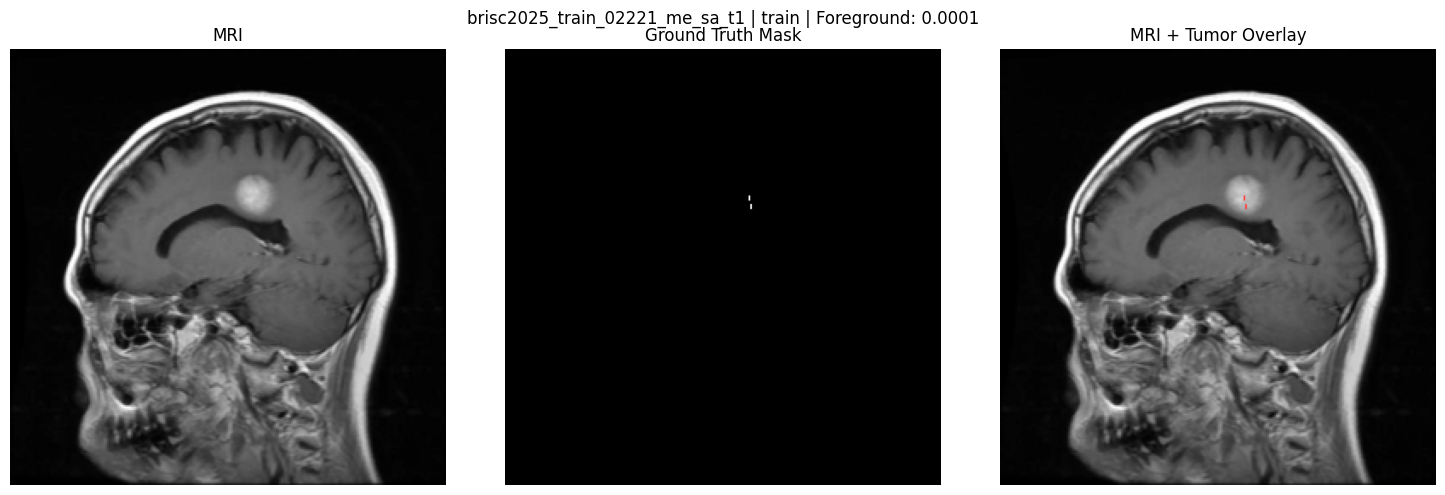

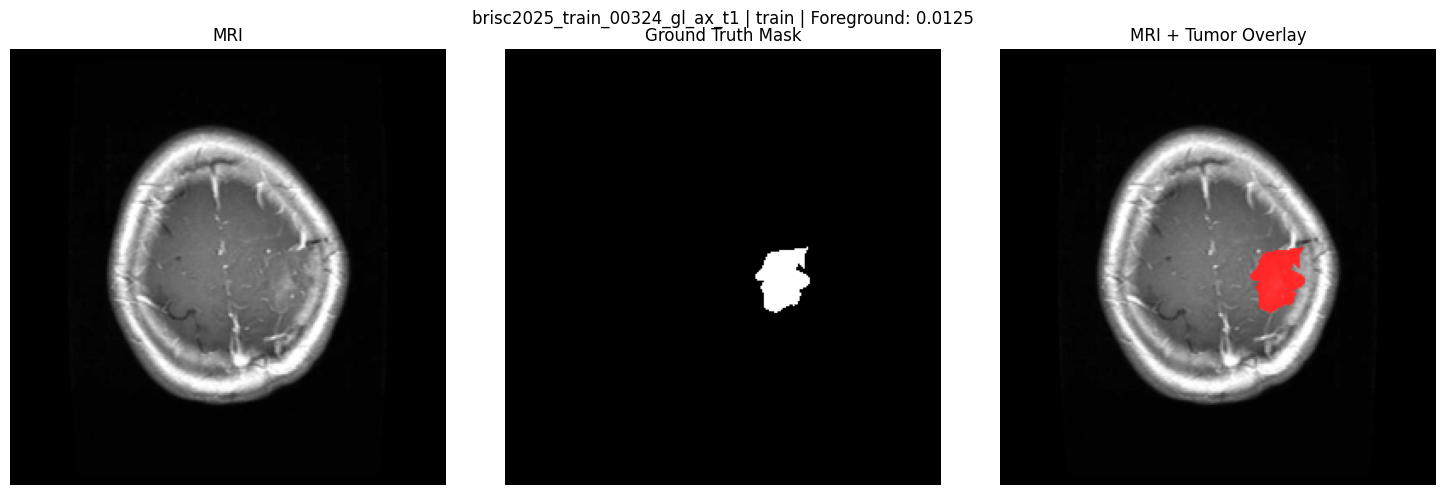

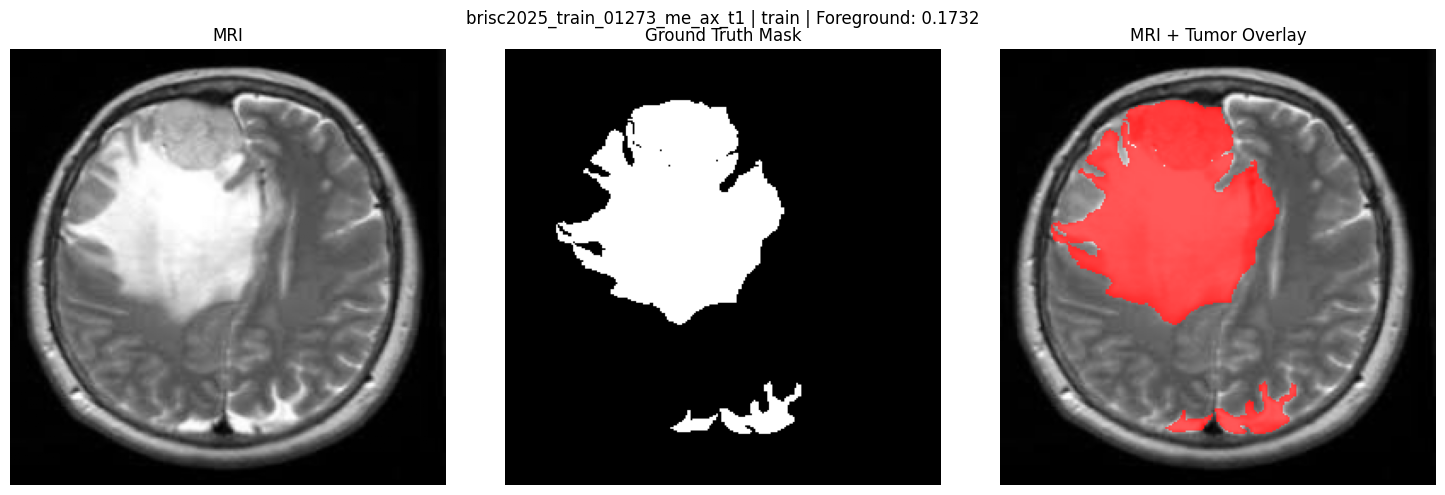

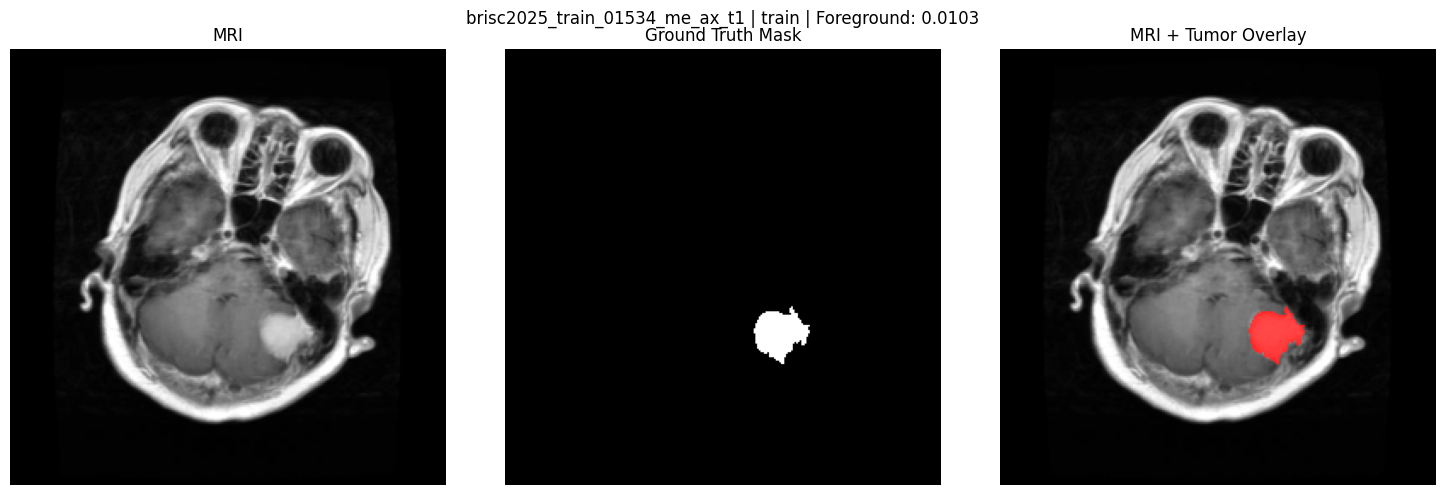

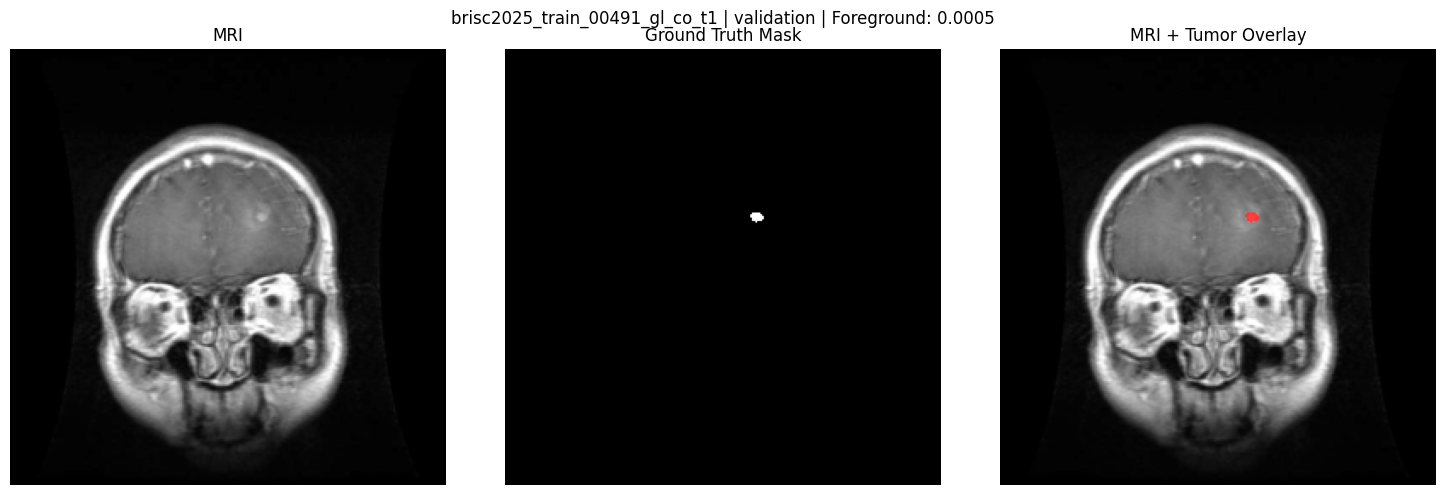

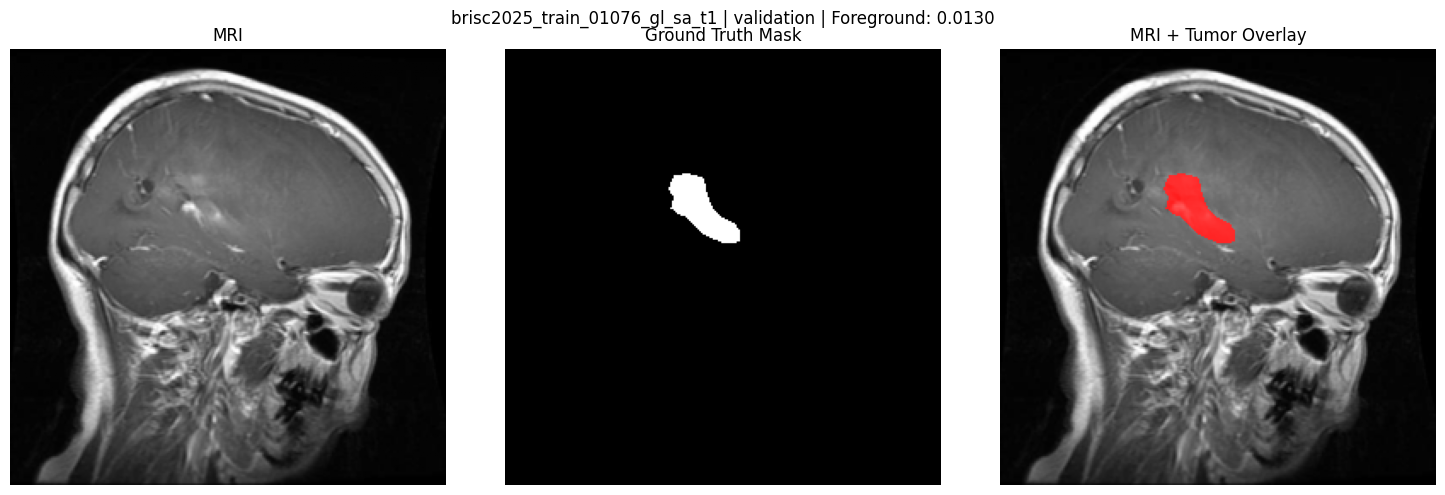

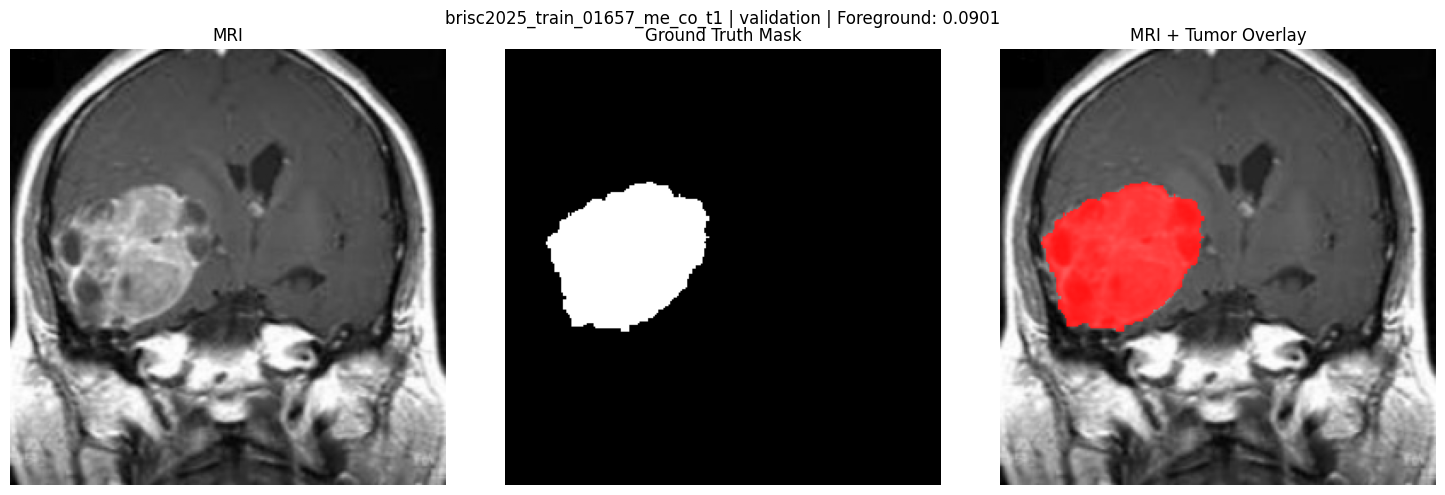

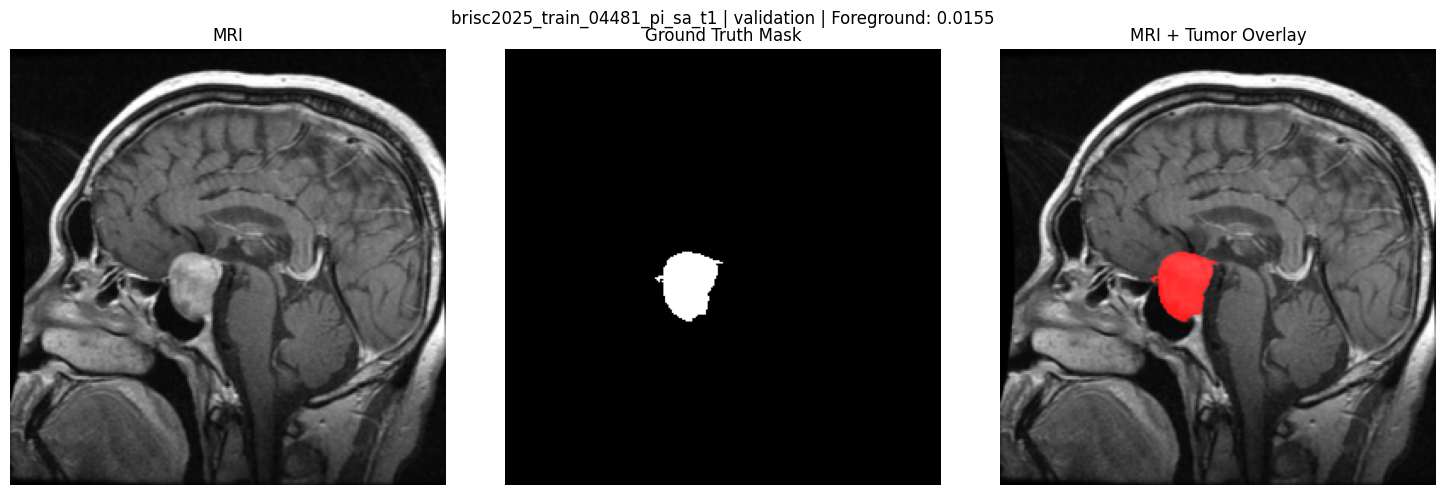

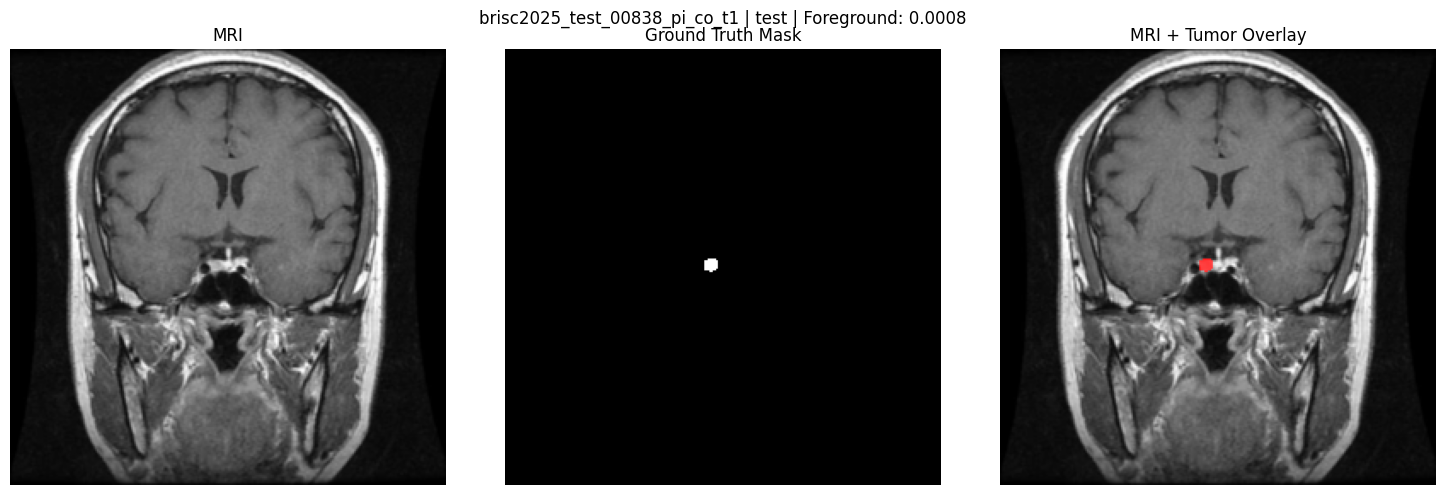

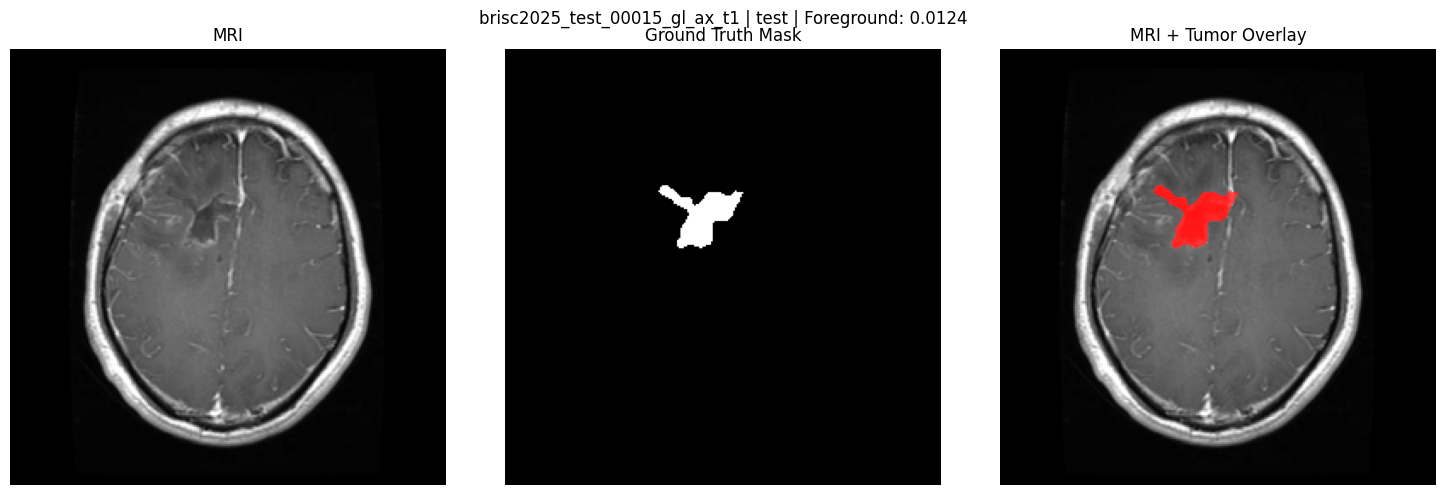

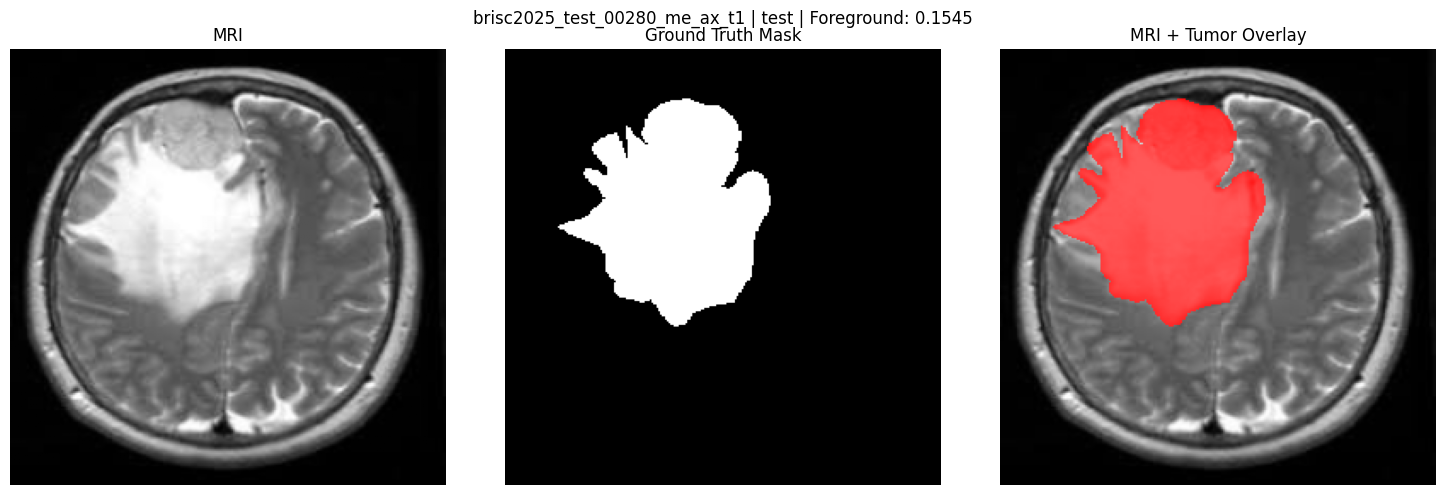

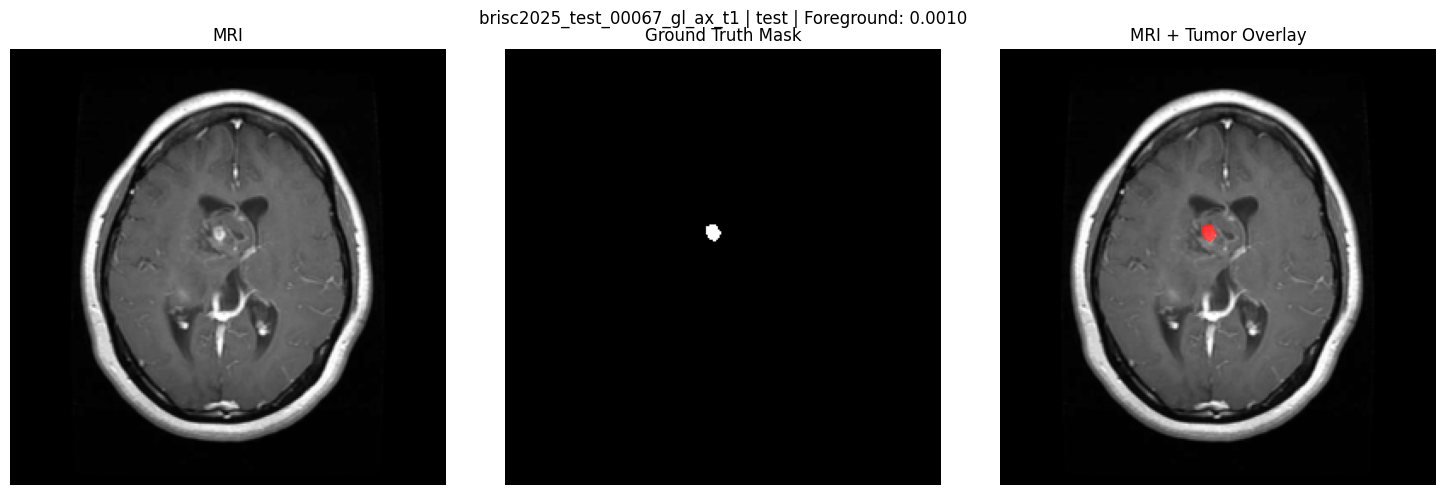


MODEL 4A - STEP 6 COMPLETE

Total samples: 4757
Invalid masks: 0
Empty masks: 0
Dimension errors: 0
Visual cases: 12

Visual audit directory:
/content/drive/MyDrive/Model4A/audit/step6/visuals

Visual audit CSV:
/content/drive/MyDrive/Model4A/audit/step6/step6_visual_cases.csv

Audit summary:
/content/drive/MyDrive/Model4A/audit/step6/model4a_step6_visual_validation.json

✅ PREPROCESSED DATA VALIDATION COMPLETE

IMPORTANT: Review the displayed MRI / mask / overlay images.
If the overlays correctly cover the tumors, proceed to STEP 7.

NEXT → STEP 7: SEGMENTATION DATASET FINAL SAFETY CHECK


In [13]:
# =============================================================================
# MODEL 4A - STEP 6
# VISUAL PREPROCESSED SEGMENTATION VALIDATION - FIXED
# =============================================================================

import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("=" * 80)
print("MODEL 4A - STEP 6")
print("VISUAL PREPROCESSED SEGMENTATION VALIDATION")
print("=" * 80)

# =============================================================================
# 1. GOOGLE DRIVE
# =============================================================================

from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Model4A"
)

MANIFEST = (
    DRIVE_ROOT
    / "manifests"
    / "model4a_step5_processed_manifest.csv"
)

IMAGE_DIR = (
    DRIVE_ROOT
    / "processed"
    / "256x256"
    / "images"
)

MASK_DIR = (
    DRIVE_ROOT
    / "processed"
    / "256x256"
    / "masks"
)

AUDIT_DIR = (
    DRIVE_ROOT
    / "audit"
    / "step6"
)

VIS_DIR = (
    AUDIT_DIR
    / "visuals"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# 2. CONFIGURATION
# =============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print()
print("Target size: 256 × 256")

# =============================================================================
# 3. LOAD MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING PROCESSED MANIFEST")
print("=" * 80)

if not MANIFEST.exists():

    raise FileNotFoundError(
        f"Processed manifest not found:\n{MANIFEST}"
    )

df = pd.read_csv(
    MANIFEST
)

required_columns = [
    "id",
    "split",
    "processed_image",
    "processed_mask",
    "foreground_ratio"
]

missing_columns = [
    c
    for c in required_columns
    if c not in df.columns
]

if missing_columns:

    raise KeyError(
        f"Missing manifest columns: {missing_columns}"
    )

print()
print("Manifest:")
print(MANIFEST)

print()
print("Rows:", len(df))

print()
print("Split distribution:")
print(
    df["split"].value_counts()
)

# =============================================================================
# 4. VERIFY PROCESSED FILES
# =============================================================================

print()
print("=" * 80)
print("VERIFYING PROCESSED FILES")
print("=" * 80)

missing_images = []
missing_masks = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    if not Path(
        row.processed_image
    ).exists():

        missing_images.append(
            row.id
        )

    if not Path(
        row.processed_mask
    ).exists():

        missing_masks.append(
            row.id
        )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

print()
print(
    "Missing images:",
    len(missing_images)
)

print(
    "Missing masks:",
    len(missing_masks)
)

if missing_images or missing_masks:

    raise RuntimeError(
        "Processed dataset is incomplete."
    )

print()
print(
    "✅ ALL PROCESSED FILES FOUND"
)

# =============================================================================
# 5. IMAGE / MASK LOADER
# =============================================================================

def load_pair(row):

    image = np.array(
        Image.open(
            row.processed_image
        ).convert("L")
    )

    mask = np.array(
        Image.open(
            row.processed_mask
        ).convert("L")
    )

    binary_mask = (
        mask > 0
    ).astype(
        np.uint8
    )

    return image, binary_mask


# =============================================================================
# 6. DIMENSION CHECK
# =============================================================================

print()
print("=" * 80)
print("DIMENSION CHECK")
print("=" * 80)

dimension_errors = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    image, mask = load_pair(row)

    if image.shape != (256, 256):

        dimension_errors.append(
            (
                row.id,
                "image",
                image.shape
            )
        )

    if mask.shape != (256, 256):

        dimension_errors.append(
            (
                row.id,
                "mask",
                mask.shape
            )
        )

    if image.shape != mask.shape:

        dimension_errors.append(
            (
                row.id,
                "image_mask_mismatch",
                (
                    image.shape,
                    mask.shape
                )
            )
        )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

print()
print(
    "Dimension errors:",
    len(dimension_errors)
)

if dimension_errors:

    print()
    print("First errors:")

    for error in dimension_errors[:10]:

        print(
            " -",
            error
        )

    raise RuntimeError(
        "Dimension validation failed."
    )

print(
    "✅ ALL IMAGES AND MASKS ARE 256×256"
)

# =============================================================================
# 7. MASK VALIDITY CHECK
# =============================================================================

print()
print("=" * 80)
print("MASK VALIDITY CHECK")
print("=" * 80)

invalid_masks = []
empty_masks = []
foreground_ratios = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    image, mask = load_pair(row)

    unique_values = set(
        np.unique(
            mask * 255
        ).tolist()
    )

    if not unique_values.issubset(
        {0, 255}
    ):

        invalid_masks.append(
            (
                row.id,
                sorted(unique_values)
            )
        )

    foreground = np.sum(
        mask > 0
    )

    if foreground == 0:

        empty_masks.append(
            row.id
        )

    foreground_ratios.append(
        foreground / mask.size
    )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

print()
print(
    "Invalid masks:",
    len(invalid_masks)
)

print(
    "Empty masks:",
    len(empty_masks)
)

if invalid_masks:

    raise RuntimeError(
        "Invalid binary masks detected."
    )

if empty_masks:

    raise RuntimeError(
        "Empty masks detected."
    )

print(
    "✅ ALL MASKS VALID"
)

# =============================================================================
# 8. UPDATE FOREGROUND RATIOS
# =============================================================================

df["computed_foreground_ratio"] = (
    foreground_ratios
)

# =============================================================================
# 9. SELECT REPRESENTATIVE CASES
# =============================================================================

print()
print("=" * 80)
print("SELECTING VISUAL AUDIT CASES")
print("=" * 80)

selected_rows = []

for split_name in [
    "train",
    "validation",
    "test"
]:

    split_df = df[
        df["split"] == split_name
    ].copy()

    if len(split_df) == 0:

        continue

    # Smallest tumor
    small_index = (
        split_df[
            "computed_foreground_ratio"
        ].idxmin()
    )

    small_case = split_df.loc[
        small_index
    ]

    # Largest tumor
    large_index = (
        split_df[
            "computed_foreground_ratio"
        ].idxmax()
    )

    large_case = split_df.loc[
        large_index
    ]

    # Median tumor
    median_value = (
        split_df[
            "computed_foreground_ratio"
        ].median()
    )

    median_index = (
        (
            split_df[
                "computed_foreground_ratio"
            ]
            - median_value
        )
        .abs()
        .idxmin()
    )

    median_case = split_df.loc[
        median_index
    ]

    # Random case
    random_case = split_df.sample(
        n=1,
        random_state=SEED
    ).iloc[0]

    selected_rows.extend(
        [
            small_case,
            median_case,
            large_case,
            random_case
        ]
    )

selected_df = (
    pd.DataFrame(
        selected_rows
    )
    .drop_duplicates(
        subset=["id"]
    )
)

print()
print(
    "Selected visual cases:",
    len(selected_df)
)

print()

print(
    selected_df[
        [
            "id",
            "split",
            "computed_foreground_ratio"
        ]
    ].to_string(
        index=False
    )
)

# =============================================================================
# 10. GENERATE VISUAL AUDIT
# =============================================================================

print()
print("=" * 80)
print("GENERATING VISUAL AUDIT")
print("=" * 80)

visual_records = []

for index, row in enumerate(
    selected_df.itertuples(
        index=False
    ),
    start=1
):

    image, mask = load_pair(row)

    tumor = mask > 0

    # ---------------------------------------------------------
    # Bounding box
    # ---------------------------------------------------------

    ys, xs = np.where(
        tumor
    )

    if len(xs) > 0:

        x_min = int(
            xs.min()
        )

        x_max = int(
            xs.max()
        )

        y_min = int(
            ys.min()
        )

        y_max = int(
            ys.max()
        )

        bbox_width = (
            x_max - x_min + 1
        )

        bbox_height = (
            y_max - y_min + 1
        )

    else:

        x_min = 0
        x_max = 0
        y_min = 0
        y_max = 0

        bbox_width = 0
        bbox_height = 0

    # ---------------------------------------------------------
    # RGB MRI
    # ---------------------------------------------------------

    rgb = np.stack(
        [
            image,
            image,
            image
        ],
        axis=-1
    ).astype(
        np.float32
    )

    # ---------------------------------------------------------
    # Tumor overlay
    # ---------------------------------------------------------

    overlay = rgb.copy()

    overlay[tumor, 0] = 255
    overlay[tumor, 1] *= 0.35
    overlay[tumor, 2] *= 0.35

    overlay = np.clip(
        overlay,
        0,
        255
    ).astype(
        np.uint8
    )

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        image,
        cmap="gray"
    )

    axes[0].set_title(
        "MRI"
    )

    axes[1].imshow(
        mask,
        cmap="gray"
    )

    axes[1].set_title(
        "Ground Truth Mask"
    )

    axes[2].imshow(
        overlay
    )

    axes[2].set_title(
        "MRI + Tumor Overlay"
    )

    for ax in axes:

        ax.axis("off")

    fig.suptitle(
        (
            f"{row.id} | "
            f"{row.split} | "
            f"Foreground: "
            f"{row.computed_foreground_ratio:.4f}"
        ),
        fontsize=12
    )

    plt.tight_layout()

    output_file = (
        VIS_DIR
        / f"{index:02d}_{row.id}.png"
    )

    plt.savefig(
        output_file,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    visual_records.append(
        {
            "id":
                row.id,

            "split":
                row.split,

            "foreground_ratio":
                float(
                    row.computed_foreground_ratio
                ),

            "bbox_x_min":
                x_min,

            "bbox_y_min":
                y_min,

            "bbox_x_max":
                x_max,

            "bbox_y_max":
                y_max,

            "bbox_width":
                bbox_width,

            "bbox_height":
                bbox_height,

            "visual_file":
                str(output_file)
        }
    )

# =============================================================================
# 11. SAVE VISUAL AUDIT CSV
# =============================================================================

visual_df = pd.DataFrame(
    visual_records
)

VISUAL_CSV = (
    AUDIT_DIR
    / "step6_visual_cases.csv"
)

visual_df.to_csv(
    VISUAL_CSV,
    index=False
)

# =============================================================================
# 12. SAVE SUMMARY
# =============================================================================

summary = {

    "manifest":
        str(MANIFEST),

    "total_samples":
        int(len(df)),

    "train":
        int(
            (
                df["split"] == "train"
            ).sum()
        ),

    "validation":
        int(
            (
                df["split"] == "validation"
            ).sum()
        ),

    "test":
        int(
            (
                df["split"] == "test"
            ).sum()
        ),

    "image_size":
        [256, 256],

    "invalid_masks":
        int(len(invalid_masks)),

    "empty_masks":
        int(len(empty_masks)),

    "dimension_errors":
        int(len(dimension_errors)),

    "visual_cases":
        int(len(selected_df)),

    "visual_audit_directory":
        str(VIS_DIR),

    "visual_audit_csv":
        str(VISUAL_CSV),

    "status":
        "PASSED"
}

SUMMARY_JSON = (
    AUDIT_DIR
    / "model4a_step6_visual_validation.json"
)

with open(
    SUMMARY_JSON,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# =============================================================================
# 13. COMPLETE
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 6 COMPLETE")
print("=" * 80)

print()
print(
    "Total samples:",
    len(df)
)

print(
    "Invalid masks:",
    len(invalid_masks)
)

print(
    "Empty masks:",
    len(empty_masks)
)

print(
    "Dimension errors:",
    len(dimension_errors)
)

print(
    "Visual cases:",
    len(selected_df)
)

print()
print(
    "Visual audit directory:"
)

print(
    VIS_DIR
)

print()
print(
    "Visual audit CSV:"
)

print(
    VISUAL_CSV
)

print()
print(
    "Audit summary:"
)

print(
    SUMMARY_JSON
)

print()
print(
    "✅ PREPROCESSED DATA VALIDATION COMPLETE"
)

print()
print(
    "IMPORTANT: Review the displayed MRI / mask / overlay images."
)

print(
    "If the overlays correctly cover the tumors, proceed to STEP 7."
)

print()
print(
    "NEXT → STEP 7: SEGMENTATION DATASET FINAL SAFETY CHECK"
)

print("=" * 80)

In [14]:
# =============================================================================
# MODEL 4A - STEP 7
# FINAL SEGMENTATION DATASET SAFETY CHECK
# =============================================================================

import os
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

print("=" * 80)
print("MODEL 4A - STEP 7")
print("FINAL SEGMENTATION DATASET SAFETY CHECK")
print("=" * 80)

# =============================================================================
# 1. GOOGLE DRIVE
# =============================================================================

from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Model4A"
)

MANIFEST = (
    DRIVE_ROOT
    / "manifests"
    / "model4a_step5_processed_manifest.csv"
)

AUDIT_DIR = (
    DRIVE_ROOT
    / "audit"
    / "step7"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_AUDIT = (
    AUDIT_DIR
    / "model4a_step7_final_safety_audit.json"
)

# =============================================================================
# 2. LOAD MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING PROCESSED MANIFEST")
print("=" * 80)

if not MANIFEST.exists():

    raise FileNotFoundError(
        f"Manifest not found:\n{MANIFEST}"
    )

df = pd.read_csv(
    MANIFEST
)

required_columns = [
    "id",
    "split",
    "processed_image",
    "processed_mask",
    "foreground_ratio"
]

missing_columns = [
    c
    for c in required_columns
    if c not in df.columns
]

if missing_columns:

    raise KeyError(
        f"Missing columns: {missing_columns}"
    )

print()
print("Manifest:")
print(MANIFEST)

print()
print("Rows:", len(df))

# =============================================================================
# 3. BASIC MANIFEST CHECK
# =============================================================================

print()
print("=" * 80)
print("MANIFEST INTEGRITY")
print("=" * 80)

errors = []

# Duplicate IDs
duplicate_ids = (
    df["id"]
    .duplicated(keep=False)
)

duplicate_id_count = int(
    duplicate_ids.sum()
)

print()
print(
    "Duplicate IDs:",
    duplicate_id_count
)

if duplicate_id_count > 0:

    errors.append(
        "Duplicate sample IDs"
    )

# Missing IDs
missing_id_count = int(
    df["id"].isna().sum()
)

print(
    "Missing IDs:",
    missing_id_count
)

if missing_id_count > 0:

    errors.append(
        "Missing sample IDs"
    )

# Invalid split values
valid_splits = {
    "train",
    "validation",
    "test"
}

invalid_splits = sorted(
    set(df["split"].dropna())
    - valid_splits
)

print(
    "Invalid split values:",
    invalid_splits
)

if invalid_splits:

    errors.append(
        "Invalid split values"
    )

# =============================================================================
# 4. SPLIT COUNTS
# =============================================================================

print()
print("=" * 80)
print("FINAL SPLIT DISTRIBUTION")
print("=" * 80)

split_counts = (
    df["split"]
    .value_counts()
)

print()
print(split_counts)

expected_counts = {
    "train": 3318,
    "validation": 586,
    "test": 853
}

for split_name, expected in expected_counts.items():

    actual = int(
        split_counts.get(
            split_name,
            0
        )
    )

    print(
        f"{split_name:12s}: "
        f"{actual} / expected {expected}"
    )

    if actual != expected:

        errors.append(
            f"{split_name} count mismatch"
        )

# =============================================================================
# 5. FILE EXISTENCE
# =============================================================================

print()
print("=" * 80)
print("VERIFYING ALL PROCESSED FILES")
print("=" * 80)

missing_images = []
missing_masks = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    image_path = Path(
        row.processed_image
    )

    mask_path = Path(
        row.processed_mask
    )

    if not image_path.exists():

        missing_images.append(
            row.id
        )

    if not mask_path.exists():

        missing_masks.append(
            row.id
        )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

print()
print(
    "Missing images:",
    len(missing_images)
)

print(
    "Missing masks:",
    len(missing_masks)
)

if missing_images:

    errors.append(
        "Missing processed images"
    )

if missing_masks:

    errors.append(
        "Missing processed masks"
    )

# =============================================================================
# 6. IMAGE / MASK PAIR INTEGRITY
# =============================================================================

print()
print("=" * 80)
print("IMAGE / MASK PAIR INTEGRITY")
print("=" * 80)

pair_errors = []

for row in df.itertuples(
    index=False
):

    image_path = Path(
        row.processed_image
    )

    mask_path = Path(
        row.processed_mask
    )

    image_name = image_path.stem
    mask_name = mask_path.stem

    if image_name != mask_name:

        pair_errors.append(
            (
                row.id,
                image_name,
                mask_name
            )
        )

print()
print(
    "Pair naming errors:",
    len(pair_errors)
)

if pair_errors:

    errors.append(
        "Image/mask naming mismatch"
    )

# =============================================================================
# 7. IMAGE / MASK DIMENSION CHECK
# =============================================================================

print()
print("=" * 80)
print("DIMENSION + CHANNEL CHECK")
print("=" * 80)

dimension_errors = []
channel_errors = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    image = np.array(
        Image.open(
            row.processed_image
        )
    )

    mask = np.array(
        Image.open(
            row.processed_mask
        )
    )

    if image.shape != (
        256,
        256
    ):

        dimension_errors.append(
            (
                row.id,
                "image",
                image.shape
            )
        )

    if mask.shape != (
        256,
        256
    ):

        dimension_errors.append(
            (
                row.id,
                "mask",
                mask.shape
            )
        )

    if image.ndim != 2:

        channel_errors.append(
            (
                row.id,
                "image",
                image.shape
            )
        )

    if mask.ndim != 2:

        channel_errors.append(
            (
                row.id,
                "mask",
                mask.shape
            )
        )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

print()
print(
    "Dimension errors:",
    len(dimension_errors)
)

print(
    "Channel errors:",
    len(channel_errors)
)

if dimension_errors:

    errors.append(
        "Dimension errors"
    )

if channel_errors:

    errors.append(
        "Unexpected image/mask channels"
    )

# =============================================================================
# 8. MASK VALUE CHECK
# =============================================================================

print()
print("=" * 80)
print("BINARY MASK CHECK")
print("=" * 80)

invalid_masks = []
empty_masks = []

mask_value_counts = {
    0: 0,
    255: 0
}

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    mask = np.array(
        Image.open(
            row.processed_mask
        )
    )

    unique_values = set(
        np.unique(mask).tolist()
    )

    if not unique_values.issubset(
        {0, 255}
    ):

        invalid_masks.append(
            (
                row.id,
                sorted(unique_values)
            )
        )

    if np.sum(mask > 0) == 0:

        empty_masks.append(
            row.id
        )

    if 0 in unique_values:
        mask_value_counts[0] += 1

    if 255 in unique_values:
        mask_value_counts[255] += 1

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

print()
print(
    "Invalid masks:",
    len(invalid_masks)
)

print(
    "Empty masks:",
    len(empty_masks)
)

print(
    "Files containing background 0:",
    mask_value_counts[0]
)

print(
    "Files containing foreground 255:",
    mask_value_counts[255]
)

if invalid_masks:

    errors.append(
        "Non-binary masks"
    )

if empty_masks:

    errors.append(
        "Empty masks"
    )

# =============================================================================
# 9. FOREGROUND DISTRIBUTION
# =============================================================================

print()
print("=" * 80)
print("FOREGROUND DISTRIBUTION")
print("=" * 80)

foreground_ratios = []

for row in df.itertuples(
    index=False
):

    mask = np.array(
        Image.open(
            row.processed_mask
        )
    )

    ratio = (
        np.sum(mask > 0)
        / mask.size
    )

    foreground_ratios.append(
        ratio
    )

df["verified_foreground_ratio"] = (
    foreground_ratios
)

fg = np.array(
    foreground_ratios
)

print()
print(
    "Minimum:",
    float(np.min(fg))
)

print(
    "Maximum:",
    float(np.max(fg))
)

print(
    "Mean:",
    float(np.mean(fg))
)

print(
    "Median:",
    float(np.median(fg))
)

print(
    "P01:",
    float(np.percentile(fg, 1))
)

print(
    "P99:",
    float(np.percentile(fg, 99))
)

# =============================================================================
# 10. EXTREME FOREGROUND CHECK
# =============================================================================

very_small = int(
    np.sum(
        fg < 0.00005
    )
)

very_large = int(
    np.sum(
        fg > 0.50
    )
)

print()
print(
    "Foreground < 0.005%:",
    very_small
)

print(
    "Foreground > 50%:",
    very_large
)

# We don't automatically reject very small tumors because
# small tumors are legitimate segmentation examples.
#
# >50% foreground is suspicious.

if very_large > 0:

    errors.append(
        "Masks with >50% foreground detected"
    )

# =============================================================================
# 11. SPLIT FOREGROUND STATISTICS
# =============================================================================

print()
print("=" * 80)
print("FOREGROUND STATISTICS BY SPLIT")
print("=" * 80)

split_stats = (
    df.groupby("split")
    ["verified_foreground_ratio"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max"
        ]
    )
)

print()
print(split_stats)

# =============================================================================
# 12. CROSS-SPLIT ID LEAKAGE
# =============================================================================

print()
print("=" * 80)
print("CROSS-SPLIT ID LEAKAGE")
print("=" * 80)

train_ids = set(
    df.loc[
        df["split"] == "train",
        "id"
    ]
)

validation_ids = set(
    df.loc[
        df["split"] == "validation",
        "id"
    ]
)

test_ids = set(
    df.loc[
        df["split"] == "test",
        "id"
    ]
)

train_val_overlap = (
    train_ids
    & validation_ids
)

train_test_overlap = (
    train_ids
    & test_ids
)

validation_test_overlap = (
    validation_ids
    & test_ids
)

print()
print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(validation_test_overlap)
)

if (
    train_val_overlap
    or train_test_overlap
    or validation_test_overlap
):

    errors.append(
        "Cross-split ID leakage"
    )

# =============================================================================
# 13. IMAGE HASH LEAKAGE
# =============================================================================

print()
print("=" * 80)
print("CROSS-SPLIT IMAGE HASH CHECK")
print("=" * 80)

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:

                break

            h.update(
                chunk
            )

    return h.hexdigest()


hash_records = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    image_hash = sha256_file(
        row.processed_image
    )

    hash_records.append(
        (
            row.id,
            row.split,
            image_hash
        )
    )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

hash_df = pd.DataFrame(
    hash_records,
    columns=[
        "id",
        "split",
        "image_hash"
    ]
)

hash_split_counts = (
    hash_df
    .groupby("image_hash")["split"]
    .nunique()
)

cross_split_hashes = set(
    hash_split_counts[
        hash_split_counts > 1
    ].index
)

print()
print(
    "Cross-split duplicate image hashes:",
    len(cross_split_hashes)
)

if cross_split_hashes:

    errors.append(
        "Cross-split image hash leakage"
    )

# =============================================================================
# 14. MASK HASH CROSS-SPLIT CHECK
# =============================================================================

print()
print("=" * 80)
print("CROSS-SPLIT MASK HASH CHECK")
print("=" * 80)

mask_hash_records = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    mask_hash = sha256_file(
        row.processed_mask
    )

    mask_hash_records.append(
        (
            row.id,
            row.split,
            mask_hash
        )
    )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

mask_hash_df = pd.DataFrame(
    mask_hash_records,
    columns=[
        "id",
        "split",
        "mask_hash"
    ]
)

mask_hash_split_counts = (
    mask_hash_df
    .groupby("mask_hash")["split"]
    .nunique()
)

cross_split_mask_hashes = set(
    mask_hash_split_counts[
        mask_hash_split_counts > 1
    ].index
)

print()
print(
    "Cross-split duplicate mask hashes:",
    len(cross_split_mask_hashes)
)

if cross_split_mask_hashes:

    errors.append(
        "Cross-split mask hash duplication"
    )

# =============================================================================
# 15. FINAL DUPLICATE REPORT
# =============================================================================

print()
print("=" * 80)
print("FINAL DUPLICATE REPORT")
print("=" * 80)

duplicate_image_groups = (
    hash_df[
        hash_df["image_hash"].duplicated(
            keep=False
        )
    ]
    .groupby("image_hash")
    .size()
)

duplicate_mask_groups = (
    mask_hash_df[
        mask_hash_df["mask_hash"].duplicated(
            keep=False
        )
    ]
    .groupby("mask_hash")
    .size()
)

print()
print(
    "Duplicate image groups:",
    len(duplicate_image_groups)
)

print(
    "Duplicate mask groups:",
    len(duplicate_mask_groups)
)

print()
print(
    "Cross-split image duplicates:",
    len(cross_split_hashes)
)

print(
    "Cross-split mask duplicates:",
    len(cross_split_mask_hashes)
)

# Within-split duplicates are not automatically rejected.
# Cross-split duplicates are the critical leakage condition.

# =============================================================================
# 16. SOURCE / PROCESSED COUNT CONSISTENCY
# =============================================================================

print()
print("=" * 80)
print("COUNT CONSISTENCY")
print("=" * 80)

processed_image_count = len(
    list(
        (
            DRIVE_ROOT
            / "processed"
            / "256x256"
            / "images"
        ).glob("*.png")
    )
)

processed_mask_count = len(
    list(
        (
            DRIVE_ROOT
            / "processed"
            / "256x256"
            / "masks"
        ).glob("*.png")
    )
)

print()
print(
    "Manifest rows:",
    len(df)
)

print(
    "Processed images:",
    processed_image_count
)

print(
    "Processed masks:",
    processed_mask_count
)

if processed_image_count != len(df):

    errors.append(
        "Processed image count mismatch"
    )

if processed_mask_count != len(df):

    errors.append(
        "Processed mask count mismatch"
    )

# =============================================================================
# 17. FINAL SAFETY DECISION
# =============================================================================

print()
print("=" * 80)
print("FINAL SAFETY DECISION")
print("=" * 80)

# Remove duplicate error strings
errors = list(
    dict.fromkeys(errors)
)

print()

if errors:

    print(
        "❌ SAFETY CHECK FAILED"
    )

    print()

    for error in errors:

        print(
            " -",
            error
        )

    print()

    print(
        "DO NOT TRAIN."
    )

else:

    print(
        "✅ MANIFEST VALID"
    )

    print(
        "✅ SPLIT COUNTS VALID"
    )

    print(
        "✅ ALL FILES FOUND"
    )

    print(
        "✅ IMAGE/MASK PAIRS VALID"
    )

    print(
        "✅ 256×256 DIMENSIONS VALID"
    )

    print(
        "✅ BINARY MASKS VALID"
    )

    print(
        "✅ NO EMPTY MASKS"
    )

    print(
        "✅ NO CROSS-SPLIT ID LEAKAGE"
    )

    print(
        "✅ NO CROSS-SPLIT IMAGE HASH LEAKAGE"
    )

    print(
        "✅ NO CROSS-SPLIT MASK HASH LEAKAGE"
    )

    print(
        "✅ FOREGROUND DISTRIBUTION VALID"
    )

    print(
        "✅ PROCESSED FILE COUNTS VALID"
    )

    print()

    print(
        "🚀 DATASET IS READY FOR SEGMENTATION TRAINING"
    )

# =============================================================================
# 18. SAVE AUDIT
# =============================================================================

audit = {

    "manifest":
        str(MANIFEST),

    "total_samples":
        int(len(df)),

    "split_counts":
        {
            k: int(v)
            for k, v in split_counts.items()
        },

    "expected_split_counts":
        expected_counts,

    "missing_images":
        int(len(missing_images)),

    "missing_masks":
        int(len(missing_masks)),

    "pair_errors":
        int(len(pair_errors)),

    "dimension_errors":
        int(len(dimension_errors)),

    "channel_errors":
        int(len(channel_errors)),

    "invalid_masks":
        int(len(invalid_masks)),

    "empty_masks":
        int(len(empty_masks)),

    "very_small_masks":
        int(very_small),

    "very_large_masks":
        int(very_large),

    "train_validation_id_overlap":
        int(len(train_val_overlap)),

    "train_test_id_overlap":
        int(len(train_test_overlap)),

    "validation_test_id_overlap":
        int(len(validation_test_overlap)),

    "cross_split_image_hashes":
        int(len(cross_split_hashes)),

    "cross_split_mask_hashes":
        int(len(cross_split_mask_hashes)),

    "duplicate_image_groups_total":
        int(len(duplicate_image_groups)),

    "duplicate_mask_groups_total":
        int(len(duplicate_mask_groups)),

    "processed_image_count":
        int(processed_image_count),

    "processed_mask_count":
        int(processed_mask_count),

    "foreground_statistics":
        {
            "min":
                float(np.min(fg)),

            "max":
                float(np.max(fg)),

            "mean":
                float(np.mean(fg)),

            "median":
                float(np.median(fg)),

            "p01":
                float(np.percentile(fg, 1)),

            "p99":
                float(np.percentile(fg, 99))
        },

    "errors":
        errors,

    "status":
        "PASSED" if not errors else "FAILED"
}

with open(
    FINAL_AUDIT,
    "w"
) as f:

    json.dump(
        audit,
        f,
        indent=2
    )

# Save hash audit as CSV
HASH_AUDIT = (
    AUDIT_DIR
    / "step7_processed_image_hashes.csv"
)

hash_df.to_csv(
    HASH_AUDIT,
    index=False
)

# =============================================================================
# 19. COMPLETE
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 7 COMPLETE")
print("=" * 80)

print()
print(
    "Final dataset:",
    len(df)
)

print(
    "Train:",
    int(
        (
            df["split"] == "train"
        ).sum()
    )
)

print(
    "Validation:",
    int(
        (
            df["split"] == "validation"
        ).sum()
    )
)

print(
    "Test:",
    int(
        (
            df["split"] == "test"
        ).sum()
    )
)

print()
print(
    "Final audit:"
)

print(
    FINAL_AUDIT
)

print()
print(
    "Hash audit:"
)

print(
    HASH_AUDIT
)

if not errors:

    print()
    print("=" * 80)
    print("🚀 STEP 7 PASSED")
    print("=" * 80)

    print()
    print(
        "NEXT → STEP 8: BUILD SEGMENTATION MODEL + TRAINING"
    )

else:

    print()
    print("=" * 80)
    print("⚠️ STEP 7 FAILED")
    print("=" * 80)

    print()
    print(
        "Fix the reported safety issues before training."
    )

MODEL 4A - STEP 7
FINAL SEGMENTATION DATASET SAFETY CHECK
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING PROCESSED MANIFEST

Manifest:
/content/drive/MyDrive/Model4A/manifests/model4a_step5_processed_manifest.csv

Rows: 4757

MANIFEST INTEGRITY

Duplicate IDs: 0
Missing IDs: 0
Invalid split values: []

FINAL SPLIT DISTRIBUTION

split
train         3318
test           853
validation     586
Name: count, dtype: int64
train       : 3318 / expected 3318
validation  : 586 / expected 586
test        : 853 / expected 853

VERIFYING ALL PROCESSED FILES
[500/4757]
[1000/4757]
[1500/4757]
[2000/4757]
[2500/4757]
[3000/4757]
[3500/4757]
[4000/4757]
[4500/4757]
[4757/4757]

Missing images: 0
Missing masks: 0

IMAGE / MASK PAIR INTEGRITY

Pair naming errors: 0

DIMENSION + CHANNEL CHECK
[500/4757]
[1000/4757]
[1500/4757]
[2000/4757]
[2500/4757]
[3000/4757]
[3500/4757]
[4000/4757]
[4500/4757]
[4757/4757]

Dime

In [15]:
# =============================================================================
# MODEL 4A - STEP 7-FIX
# REMOVE CROSS-SPLIT IMAGE HASH LEAKAGE
# =============================================================================

import os
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

print("=" * 80)
print("MODEL 4A - STEP 7-FIX")
print("CROSS-SPLIT IMAGE HASH LEAKAGE RESOLUTION")
print("=" * 80)

# =============================================================================
# 1. DRIVE
# =============================================================================

from google.colab import drive

drive.mount("/content/drive")

ROOT = Path(
    "/content/drive/MyDrive/Model4A"
)

INPUT_MANIFEST = (
    ROOT
    / "manifests"
    / "model4a_step5_processed_manifest.csv"
)

OUTPUT_MANIFEST = (
    ROOT
    / "manifests"
    / "model4a_step7fix_leakage_free_manifest.csv"
)

AUDIT_DIR = (
    ROOT
    / "audit"
    / "step7fix"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

AUDIT_JSON = (
    AUDIT_DIR
    / "model4a_step7fix_leakage_resolution.json"
)

REMOVED_CSV = (
    AUDIT_DIR
    / "removed_cross_split_duplicates.csv"
)

# =============================================================================
# 2. LOAD MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING MANIFEST")
print("=" * 80)

if not INPUT_MANIFEST.exists():

    raise FileNotFoundError(
        f"Manifest not found:\n{INPUT_MANIFEST}"
    )

df = pd.read_csv(
    INPUT_MANIFEST
)

print()
print("Input manifest:")
print(INPUT_MANIFEST)

print(
    "Rows:",
    len(df)
)

print()
print("Original split distribution:")
print(
    df["split"].value_counts()
)

# =============================================================================
# 3. REQUIRED COLUMNS
# =============================================================================

required = [
    "id",
    "split",
    "processed_image",
    "processed_mask"
]

missing = [
    c
    for c in required
    if c not in df.columns
]

if missing:

    raise KeyError(
        f"Missing columns: {missing}"
    )

# =============================================================================
# 4. HASH FUNCTION
# =============================================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()

# =============================================================================
# 5. HASH ALL PROCESSED IMAGES
# =============================================================================

print()
print("=" * 80)
print("HASHING PROCESSED IMAGES")
print("=" * 80)

image_hashes = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    path = Path(
        row.processed_image
    )

    if not path.exists():

        raise FileNotFoundError(
            f"Missing image:\n{path}"
        )

    image_hashes.append(
        sha256_file(path)
    )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

df["image_hash"] = image_hashes

print()
print("✅ Image hashing complete")

# =============================================================================
# 6. FIND CROSS-SPLIT HASH GROUPS
# =============================================================================

print()
print("=" * 80)
print("IDENTIFYING CROSS-SPLIT DUPLICATES")
print("=" * 80)

hash_split_counts = (
    df.groupby("image_hash")["split"]
    .nunique()
)

cross_split_hashes = set(
    hash_split_counts[
        hash_split_counts > 1
    ].index
)

print()
print(
    "Cross-split hash groups:",
    len(cross_split_hashes)
)

if len(cross_split_hashes) == 0:

    print(
        "✅ No cross-split duplicates found."
    )

    df.drop(
        columns=["image_hash"],
        inplace=True
    )

    df.to_csv(
        OUTPUT_MANIFEST,
        index=False
    )

    print()
    print(
        "Manifest saved:",
        OUTPUT_MANIFEST
    )

else:

    # =================================================================
    # 7. RESOLVE DUPLICATES
    # =================================================================

    print()
    print("=" * 80)
    print("RESOLVING DUPLICATES")
    print("=" * 80)

    print()
    print(
        "Priority:"
    )

    print(
        "1. TEST      → preserve test copy"
    )

    print(
        "2. VALIDATION → preserve validation copy"
    )

    print(
        "3. TRAIN     → preserve train copy"
    )

    print()
    print(
        "Reason: test and validation must remain independent "
        "from training."
    )

    priority = {
        "test": 0,
        "validation": 1,
        "train": 2
    }

    keep_indices = set(
        df.index
    )

    removed_records = []

    group_number = 0

    for image_hash in sorted(
        cross_split_hashes
    ):

        group = df[
            df["image_hash"]
            == image_hash
        ]

        group_number += 1

        # Sort by safety priority
        group_sorted = group.copy()

        group_sorted["_priority"] = (
            group_sorted["split"]
            .map(priority)
        )

        group_sorted = (
            group_sorted
            .sort_values(
                "_priority"
            )
        )

        # Keep the highest-priority copy
        keep_row = (
            group_sorted.iloc[0]
        )

        keep_index = (
            keep_row.name
        )

        print()
        print(
            f"DUPLICATE GROUP "
            f"{group_number}/{len(cross_split_hashes)}"
        )

        print(
            "Hash:",
            image_hash
        )

        print(
            "Keeping:"
        )

        print(
            f"  {keep_row['split']:10s} | "
            f"{keep_row['id']}"
        )

        # Remove every other copy
        for idx, row in group_sorted.iloc[1:].iterrows():

            if idx in keep_indices:

                keep_indices.remove(
                    idx
                )

            removed_records.append(
                {
                    "id":
                        row["id"],

                    "split":
                        row["split"],

                    "image_hash":
                        image_hash,

                    "processed_image":
                        row["processed_image"],

                    "processed_mask":
                        row["processed_mask"],

                    "kept_id":
                        keep_row["id"],

                    "kept_split":
                        keep_row["split"],

                    "reason":
                        "cross_split_image_hash_duplicate"
                }
            )

            print(
                f"  REMOVED   | "
                f"{row['split']:10s} | "
                f"{row['id']}"
            )

    # =================================================================
    # 8. CREATE CLEAN DATAFRAME
    # =================================================================

    clean_df = (
        df.loc[
            sorted(keep_indices)
        ]
        .copy()
    )

    clean_df.drop(
        columns=["image_hash"],
        inplace=True
    )

    removed_df = pd.DataFrame(
        removed_records
    )

    print()
    print("=" * 80)
    print("DUPLICATE REMOVAL SUMMARY")
    print("=" * 80)

    print()
    print(
        "Original rows:",
        len(df)
    )

    print(
        "Removed rows:",
        len(removed_df)
    )

    print(
        "Remaining rows:",
        len(clean_df)
    )

    print()
    print(
        "Removed by split:"
    )

    if len(removed_df) > 0:

        print(
            removed_df["split"]
            .value_counts()
        )

    else:

        print(
            "None"
        )

    print()
    print(
        "New split distribution:"
    )

    print(
        clean_df["split"]
        .value_counts()
    )

    # =================================================================
    # 9. SAVE CLEAN MANIFEST
    # =================================================================

    clean_df.to_csv(
        OUTPUT_MANIFEST,
        index=False
    )

    if len(removed_df) > 0:

        removed_df.to_csv(
            REMOVED_CSV,
            index=False
        )

    # =================================================================
    # 10. RECHECK ID LEAKAGE
    # =================================================================

    print()
    print("=" * 80)
    print("RECHECKING ID LEAKAGE")
    print("=" * 80)

    train_ids = set(
        clean_df.loc[
            clean_df["split"] == "train",
            "id"
        ]
    )

    validation_ids = set(
        clean_df.loc[
            clean_df["split"] == "validation",
            "id"
        ]
    )

    test_ids = set(
        clean_df.loc[
            clean_df["split"] == "test",
            "id"
        ]
    )

    train_val = (
        train_ids
        & validation_ids
    )

    train_test = (
        train_ids
        & test_ids
    )

    val_test = (
        validation_ids
        & test_ids
    )

    print()
    print(
        "Train ∩ Validation:",
        len(train_val)
    )

    print(
        "Train ∩ Test:",
        len(train_test)
    )

    print(
        "Validation ∩ Test:",
        len(val_test)
    )

    # =================================================================
    # 11. RECHECK IMAGE HASH LEAKAGE
    # =================================================================

    print()
    print("=" * 80)
    print("RECHECKING IMAGE HASH LEAKAGE")
    print("=" * 80)

    clean_hashes = []

    for i, row in enumerate(
        clean_df.itertuples(index=False),
        start=1
    ):

        clean_hashes.append(
            sha256_file(
                row.processed_image
            )
        )

        if (
            i % 500 == 0
            or i == len(clean_df)
        ):

            print(
                f"[{i}/{len(clean_df)}]"
            )

    clean_df["_image_hash"] = (
        clean_hashes
    )

    clean_hash_split_counts = (
        clean_df
        .groupby("_image_hash")["split"]
        .nunique()
    )

    remaining_cross_split = (
        clean_hash_split_counts[
            clean_hash_split_counts > 1
        ]
    )

    print()
    print(
        "Remaining cross-split image hash groups:",
        len(remaining_cross_split)
    )

    # =================================================================
    # 12. RECHECK FILES
    # =================================================================

    print()
    print("=" * 80)
    print("RECHECKING FILE INTEGRITY")
    print("=" * 80)

    missing_images = []
    missing_masks = []

    dimension_errors = []
    invalid_masks = []
    empty_masks = []

    for i, row in enumerate(
        clean_df.itertuples(index=False),
        start=1
    ):

        image_path = Path(
            row.processed_image
        )

        mask_path = Path(
            row.processed_mask
        )

        if not image_path.exists():

            missing_images.append(
                row.id
            )

        if not mask_path.exists():

            missing_masks.append(
                row.id
            )

        if (
            image_path.exists()
            and mask_path.exists()
        ):

            image = np.array(
                Image.open(
                    image_path
                )
            )

            mask = np.array(
                Image.open(
                    mask_path
                )
            )

            if image.shape != (
                256,
                256
            ):

                dimension_errors.append(
                    row.id
                )

            if mask.shape != (
                256,
                256
            ):

                dimension_errors.append(
                    row.id
                )

            values = set(
                np.unique(mask).tolist()
            )

            if not values.issubset(
                {0, 255}
            ):

                invalid_masks.append(
                    row.id
                )

            if np.sum(mask > 0) == 0:

                empty_masks.append(
                    row.id
                )

        if (
            i % 500 == 0
            or i == len(clean_df)
        ):

            print(
                f"[{i}/{len(clean_df)}]"
            )

    print()
    print(
        "Missing images:",
        len(missing_images)
    )

    print(
        "Missing masks:",
        len(missing_masks)
    )

    print(
        "Dimension errors:",
        len(dimension_errors)
    )

    print(
        "Invalid masks:",
        len(invalid_masks)
    )

    print(
        "Empty masks:",
        len(empty_masks)
    )

    # =================================================================
    # 13. FINAL DECISION
    # =================================================================

    failures = []

    if len(train_val) > 0:
        failures.append(
            "Train/validation ID leakage"
        )

    if len(train_test) > 0:
        failures.append(
            "Train/test ID leakage"
        )

    if len(val_test) > 0:
        failures.append(
            "Validation/test ID leakage"
        )

    if len(remaining_cross_split) > 0:
        failures.append(
            "Remaining cross-split image hash leakage"
        )

    if missing_images:
        failures.append(
            "Missing images"
        )

    if missing_masks:
        failures.append(
            "Missing masks"
        )

    if dimension_errors:
        failures.append(
            "Dimension errors"
        )

    if invalid_masks:
        failures.append(
            "Invalid masks"
        )

    if empty_masks:
        failures.append(
            "Empty masks"
        )

    # =================================================================
    # 14. SAVE AUDIT
    # =================================================================

    audit = {

        "input_manifest":
            str(INPUT_MANIFEST),

        "output_manifest":
            str(OUTPUT_MANIFEST),

        "original_rows":
            int(len(df)),

        "removed_rows":
            int(len(removed_df)),

        "final_rows":
            int(len(clean_df)),

        "original_cross_split_hash_groups":
            int(len(cross_split_hashes)),

        "remaining_cross_split_hash_groups":
            int(len(remaining_cross_split)),

        "removed_by_split":
            (
                removed_df["split"]
                .value_counts()
                .to_dict()
                if len(removed_df) > 0
                else {}
            ),

        "final_split_counts":
            clean_df["split"]
            .value_counts()
            .to_dict(),

        "train_validation_id_overlap":
            int(len(train_val)),

        "train_test_id_overlap":
            int(len(train_test)),

        "validation_test_id_overlap":
            int(len(val_test)),

        "missing_images":
            int(len(missing_images)),

        "missing_masks":
            int(len(missing_masks)),

        "dimension_errors":
            int(len(dimension_errors)),

        "invalid_masks":
            int(len(invalid_masks)),

        "empty_masks":
            int(len(empty_masks)),

        "failures":
            failures,

        "status":
            (
                "PASSED"
                if not failures
                else "FAILED"
            )
    }

    with open(
        AUDIT_JSON,
        "w"
    ) as f:

        json.dump(
            audit,
            f,
            indent=2
        )

    # =================================================================
    # 15. FINAL OUTPUT
    # =================================================================

    print()
    print("=" * 80)
    print("MODEL 4A - STEP 7-FIX RESULT")
    print("=" * 80)

    if not failures:

        print()
        print(
            "✅ CROSS-SPLIT IMAGE LEAKAGE REMOVED"
        )

        print(
            "✅ NO ID LEAKAGE"
        )

        print(
            "✅ NO IMAGE HASH LEAKAGE"
        )

        print(
            "✅ NO MISSING FILES"
        )

        print(
            "✅ NO DIMENSION ERRORS"
        )

        print(
            "✅ ALL MASKS BINARY"
        )

        print(
            "✅ NO EMPTY MASKS"
        )

        print()
        print(
            "🚀 DATASET IS SAFE FOR TRAINING"
        )

    else:

        print()
        print(
            "❌ STEP 7-FIX FAILED"
        )

        print()

        for failure in failures:

            print(
                " -",
                failure
            )

        raise RuntimeError(
            "Dataset is still unsafe for training."
        )

    print()
    print("=" * 80)
    print("FINAL CLEAN DATASET")
    print("=" * 80)

    print()
    print(
        "Total:",
        len(clean_df)
    )

    print(
        "Train:",
        int(
            (
                clean_df["split"]
                == "train"
            ).sum()
        )
    )

    print(
        "Validation:",
        int(
            (
                clean_df["split"]
                == "validation"
            ).sum()
        )
    )

    print(
        "Test:",
        int(
            (
                clean_df["split"]
                == "test"
            ).sum()
        )
    )

    print()
    print(
        "Clean manifest:"
    )

    print(
        OUTPUT_MANIFEST
    )

    print()
    print(
        "Removed duplicates:"
    )

    print(
        REMOVED_CSV
    )

    print()
    print(
        "Audit:"
    )

    print(
        AUDIT_JSON
    )

    print()
    print("=" * 80)
    print("NEXT → STEP 8: SEGMENTATION MODEL TRAINING")
    print("=" * 80)

MODEL 4A - STEP 7-FIX
CROSS-SPLIT IMAGE HASH LEAKAGE RESOLUTION
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOADING MANIFEST

Input manifest:
/content/drive/MyDrive/Model4A/manifests/model4a_step5_processed_manifest.csv
Rows: 4757

Original split distribution:
split
train         3318
test           853
validation     586
Name: count, dtype: int64

HASHING PROCESSED IMAGES
[500/4757]
[1000/4757]
[1500/4757]
[2000/4757]
[2500/4757]
[3000/4757]
[3500/4757]
[4000/4757]
[4500/4757]
[4757/4757]

✅ Image hashing complete

IDENTIFYING CROSS-SPLIT DUPLICATES

Cross-split hash groups: 92

RESOLVING DUPLICATES

Priority:
1. TEST      → preserve test copy
2. VALIDATION → preserve validation copy
3. TRAIN     → preserve train copy

Reason: test and validation must remain independent from training.

DUPLICATE GROUP 1/92
Hash: 013ab4e0b9374a3fcb69dac8f9cd936e75c2252e7bd7e2f95f8c6eb6aea50956
Keeping:
  test       | 

In [16]:
# =============================================================================
# MODEL 4A - STEP 8
# EFFICIENTNET-B0 + ATTENTION U-NET
# GPU SEGMENTATION TRAINING
# =============================================================================

import os
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from PIL import Image

# =============================================================================
# CONFIGURATION
# =============================================================================

print("=" * 80)
print("MODEL 4A - STEP 8")
print("EFFICIENTNET-B0 + ATTENTION U-NET")
print("GPU SEGMENTATION TRAINING")
print("=" * 80)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------------------------------------------------------
# DRIVE
# -----------------------------------------------------------------------------

from google.colab import drive

drive.mount("/content/drive")

ROOT = Path(
    "/content/drive/MyDrive/Model4A"
)

MANIFEST = (
    ROOT
    / "manifests"
    / "model4a_step7fix_leakage_free_manifest.csv"
)

MODEL_DIR = (
    ROOT
    / "models"
)

RESULT_DIR = (
    ROOT
    / "results"
    / "step8"
)

EXPORT_DIR = (
    ROOT
    / "exports"
)

AUDIT_DIR = (
    ROOT
    / "audit"
    / "step8"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL = (
    MODEL_DIR
    / "model4a_efficientnet_attention_unet_best.keras"
)

FINAL_MODEL = (
    MODEL_DIR
    / "model4a_efficientnet_attention_unet_final.keras"
)

HISTORY_FILE = (
    RESULT_DIR
    / "training_history.csv"
)

CONFIG_FILE = (
    AUDIT_DIR
    / "model4a_step8_training_config.json"
)

# =============================================================================
# GPU CHECK
# =============================================================================

print()
print("=" * 80)
print("GPU CHECK")
print("=" * 80)

gpus = tf.config.list_physical_devices("GPU")

print(
    "GPU devices:",
    gpus
)

if not gpus:

    raise RuntimeError(
        "GPU NOT DETECTED.\n"
        "Switch the Colab runtime to GPU before training."
    )

print("✅ GPU AVAILABLE")

# Enable memory growth
for gpu in gpus:

    try:

        tf.config.experimental.set_memory_growth(
            gpu,
            True
        )

    except Exception:
        pass

# =============================================================================
# OPTIONAL MIXED PRECISION
# =============================================================================

try:

    from tensorflow.keras import mixed_precision

    mixed_precision.set_global_policy(
        "mixed_float16"
    )

    print(
        "✅ Mixed precision enabled"
    )

except Exception as e:

    print(
        "⚠️ Mixed precision unavailable:",
        e
    )

# =============================================================================
# LOAD MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING CLEAN MANIFEST")
print("=" * 80)

if not MANIFEST.exists():

    raise FileNotFoundError(
        f"Clean manifest not found:\n{MANIFEST}"
    )

df = pd.read_csv(
    MANIFEST
)

print()
print(
    "Manifest:",
    MANIFEST
)

print(
    "Rows:",
    len(df)
)

print()
print(
    "Columns:"
)

for col in df.columns:

    print(
        " -",
        col
    )

# =============================================================================
# VERIFY REQUIRED COLUMNS
# =============================================================================

required_columns = [
    "id",
    "split",
    "processed_image",
    "processed_mask"
]

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_columns:

    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )

# =============================================================================
# SPLIT CHECK
# =============================================================================

valid_splits = {
    "train",
    "validation",
    "test"
}

invalid_splits = (
    set(df["split"].unique())
    - valid_splits
)

if invalid_splits:

    raise ValueError(
        f"Invalid split values: {invalid_splits}"
    )

train_df = (
    df[
        df["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    df[
        df["split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    df[
        df["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print()
print("=" * 80)
print("DATASET SPLIT")
print("=" * 80)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

# =============================================================================
# FILE VERIFICATION
# =============================================================================

print()
print("=" * 80)
print("VERIFYING DATASET FILES")
print("=" * 80)

missing_images = []
missing_masks = []

for i, row in enumerate(
    df.itertuples(index=False),
    start=1
):

    image_path = Path(
        row.processed_image
    )

    mask_path = Path(
        row.processed_mask
    )

    if not image_path.exists():

        missing_images.append(
            row.id
        )

    if not mask_path.exists():

        missing_masks.append(
            row.id
        )

    if (
        i % 500 == 0
        or i == len(df)
    ):

        print(
            f"[{i}/{len(df)}]"
        )

if missing_images:

    raise FileNotFoundError(
        f"Missing images: {len(missing_images)}"
    )

if missing_masks:

    raise FileNotFoundError(
        f"Missing masks: {len(missing_masks)}"
    )

print()
print(
    "✅ ALL FILES FOUND"
)

# =============================================================================
# LEAKAGE CHECK
# =============================================================================

print()
print("=" * 80)
print("PATIENT / ID LEAKAGE CHECK")
print("=" * 80)

train_ids = set(
    train_df["id"]
)

val_ids = set(
    val_df["id"]
)

test_ids = set(
    test_df["id"]
)

print(
    "Train ∩ Validation:",
    len(train_ids & val_ids)
)

print(
    "Train ∩ Test:",
    len(train_ids & test_ids)
)

print(
    "Validation ∩ Test:",
    len(val_ids & test_ids)
)

if (
    train_ids & val_ids
    or
    train_ids & test_ids
    or
    val_ids & test_ids
):

    raise RuntimeError(
        "Dataset leakage detected."
    )

print(
    "✅ NO ID LEAKAGE"
)

# =============================================================================
# PARAMETERS
# =============================================================================

IMG_SIZE = 256

BATCH_SIZE = 16

EPOCHS = 30

AUTOTUNE = tf.data.AUTOTUNE

print()
print("=" * 80)
print("TRAINING CONFIGURATION")
print("=" * 80)

print(
    "Image size:",
    f"{IMG_SIZE} × {IMG_SIZE}"
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Maximum epochs:",
    EPOCHS
)

print(
    "Architecture:",
    "EfficientNet-B0 + Attention U-Net"
)

print(
    "Loss:",
    "Binary Cross Entropy + Dice Loss"
)

# =============================================================================
# IMAGE LOADER
# =============================================================================

def load_image_mask(
    image_path,
    mask_path
):

    # -------------------------------------------------------------------------
    # Image
    # -------------------------------------------------------------------------

    image_bytes = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_image(
        image_bytes,
        channels=1,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        method="bilinear"
    )

    image = tf.cast(
        image,
        tf.float32
    )

    # -------------------------------------------------------------------------
    # Convert grayscale MRI to RGB
    # -------------------------------------------------------------------------

    image = tf.image.grayscale_to_rgb(
        image
    )

    # -------------------------------------------------------------------------
    # IMPORTANT:
    # EfficientNet in Keras expects image values in the normal image range.
    # Keep image in 0-255 range.
    # -------------------------------------------------------------------------

    image = tf.clip_by_value(
        image,
        0.0,
        255.0
    )

    # -------------------------------------------------------------------------
    # Mask
    # -------------------------------------------------------------------------

    mask_bytes = tf.io.read_file(
        mask_path
    )

    mask = tf.image.decode_image(
        mask_bytes,
        channels=1,
        expand_animations=False
    )

    mask = tf.image.resize(
        mask,
        [IMG_SIZE, IMG_SIZE],
        method="nearest"
    )

    mask = tf.cast(
        mask,
        tf.float32
    )

    # Binary mask
    mask = tf.where(
        mask > 127,
        1.0,
        0.0
    )

    return image, mask

# =============================================================================
# DATA AUGMENTATION
# =============================================================================

def augment(
    image,
    mask
):

    # Horizontal flip
    do_flip = tf.random.uniform(
        ()
    ) > 0.5

    image = tf.cond(
        do_flip,
        lambda: tf.image.flip_left_right(image),
        lambda: image
    )

    mask = tf.cond(
        do_flip,
        lambda: tf.image.flip_left_right(mask),
        lambda: mask
    )

    # Vertical flip
    do_flip_vertical = tf.random.uniform(
        ()
    ) > 0.8

    image = tf.cond(
        do_flip_vertical,
        lambda: tf.image.flip_up_down(image),
        lambda: image
    )

    mask = tf.cond(
        do_flip_vertical,
        lambda: tf.image.flip_up_down(mask),
        lambda: mask
    )

    # Small brightness change
    image = tf.image.random_brightness(
        image,
        max_delta=10.0
    )

    image = tf.clip_by_value(
        image,
        0.0,
        255.0
    )

    return image, mask

# =============================================================================
# DATASET BUILDER
# =============================================================================

def dataframe_dataset(
    dataframe,
    training=False
):

    image_paths = (
        dataframe[
            "processed_image"
        ]
        .astype(str)
        .values
    )

    mask_paths = (
        dataframe[
            "processed_mask"
        ]
        .astype(str)
        .values
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            image_paths,
            mask_paths
        )
    )

    if training:

        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image_mask,
        num_parallel_calls=AUTOTUNE
    )

    if training:

        dataset = dataset.map(
            augment,
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

# =============================================================================
# BUILD DATASETS
# =============================================================================

print()
print("=" * 80)
print("BUILDING TF.DATA PIPELINES")
print("=" * 80)

train_ds = dataframe_dataset(
    train_df,
    training=True
)

val_ds = dataframe_dataset(
    val_df,
    training=False
)

test_ds = dataframe_dataset(
    test_df,
    training=False
)

print(
    "✅ Training dataset ready"
)

print(
    "✅ Validation dataset ready"
)

print(
    "✅ Test dataset ready"
)

# =============================================================================
# ATTENTION GATE
# =============================================================================

def attention_gate(
    skip,
    gating,
    filters
):

    theta_x = tf.keras.layers.Conv2D(
        filters,
        1,
        padding="same",
        use_bias=False
    )(skip)

    phi_g = tf.keras.layers.Conv2D(
        filters,
        1,
        padding="same",
        use_bias=False
    )(gating)

    # Resize gating feature if required
    phi_g = tf.keras.layers.Resizing(
        tf.keras.backend.int_shape(
            theta_x
        )[1],
        tf.keras.backend.int_shape(
            theta_x
        )[2],
        interpolation="bilinear"
    )(phi_g)

    add = tf.keras.layers.Add()(
        [
            theta_x,
            phi_g
        ]
    )

    add = tf.keras.layers.Activation(
        "relu"
    )(add)

    psi = tf.keras.layers.Conv2D(
        1,
        1,
        padding="same"
    )(add)

    psi = tf.keras.layers.Activation(
        "sigmoid"
    )(psi)

    # Resize if needed
    psi = tf.keras.layers.Resizing(
        tf.keras.backend.int_shape(
            skip
        )[1],
        tf.keras.backend.int_shape(
            skip
        )[2],
        interpolation="bilinear"
    )(psi)

    return tf.keras.layers.Multiply()(
        [
            skip,
            psi
        ]
    )

# =============================================================================
# CONV BLOCK
# =============================================================================

def conv_block(
    x,
    filters
):

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = tf.keras.layers.BatchNormalization()(
        x
    )

    x = tf.keras.layers.Activation(
        "swish"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = tf.keras.layers.BatchNormalization()(
        x
    )

    x = tf.keras.layers.Activation(
        "swish"
    )(x)

    return x

# =============================================================================
# DECODER BLOCK
# =============================================================================

def decoder_block(
    x,
    skip,
    filters
):

    x = tf.keras.layers.UpSampling2D(
        size=(2, 2),
        interpolation="bilinear"
    )(x)

    # Attention on encoder feature
    skip_attention = attention_gate(
        skip,
        x,
        filters
    )

    x = tf.keras.layers.Concatenate()(
        [
            x,
            skip_attention
        ]
    )

    x = conv_block(
        x,
        filters
    )

    return x

# =============================================================================
# BUILD MODEL
# =============================================================================

print()
print("=" * 80)
print("BUILDING MODEL 4A")
print("=" * 80)

inputs = tf.keras.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),
    name="mri_input"
)

# -------------------------------------------------------------------------
# EfficientNet-B0 encoder
# -------------------------------------------------------------------------

encoder = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs
)

# -------------------------------------------------------------------------
# Feature extraction points
# -------------------------------------------------------------------------

skip1 = encoder.get_layer(
    "block2a_expand_activation"
).output

skip2 = encoder.get_layer(
    "block3a_expand_activation"
).output

skip3 = encoder.get_layer(
    "block4a_expand_activation"
).output

skip4 = encoder.get_layer(
    "block6a_expand_activation"
).output

bridge = encoder.output

# -------------------------------------------------------------------------
# Decoder
# -------------------------------------------------------------------------

x = decoder_block(
    bridge,
    skip4,
    256
)

x = decoder_block(
    x,
    skip3,
    128
)

x = decoder_block(
    x,
    skip2,
    64
)

x = decoder_block(
    x,
    skip1,
    32
)

# -------------------------------------------------------------------------
# Final upsampling
# -------------------------------------------------------------------------

x = tf.keras.layers.UpSampling2D(
    size=(2, 2),
    interpolation="bilinear"
)(x)

x = conv_block(
    x,
    16
)

# -------------------------------------------------------------------------
# Segmentation head
# -------------------------------------------------------------------------

outputs = tf.keras.layers.Conv2D(
    1,
    1,
    padding="same",
    activation="sigmoid",
    dtype="float32",
    name="tumor_segmentation"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Model4A_EfficientNetB0_AttentionUNet"
)

# =============================================================================
# INITIAL FREEZE
# =============================================================================

print()
print(
    "Freezing EfficientNet encoder for initial training..."
)

encoder.trainable = False

# =============================================================================
# LOSS FUNCTIONS
# =============================================================================

def dice_coefficient(
    y_true,
    y_pred,
    smooth=1e-6
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32
    )

    y_true_flat = tf.reshape(
        y_true,
        [
            tf.shape(y_true)[0],
            -1
        ]
    )

    y_pred_flat = tf.reshape(
        y_pred,
        [
            tf.shape(y_pred)[0],
            -1
        ]
    )

    intersection = tf.reduce_sum(
        y_true_flat * y_pred_flat,
        axis=1
    )

    denominator = (
        tf.reduce_sum(
            y_true_flat,
            axis=1
        )
        +
        tf.reduce_sum(
            y_pred_flat,
            axis=1
        )
    )

    dice = (
        2.0 * intersection
        + smooth
    ) / (
        denominator
        + smooth
    )

    return tf.reduce_mean(
        dice
    )


def dice_loss(
    y_true,
    y_pred
):

    return 1.0 - dice_coefficient(
        y_true,
        y_pred
    )


def combined_loss(
    y_true,
    y_pred
):

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    bce = tf.reduce_mean(
        bce
    )

    dl = dice_loss(
        y_true,
        y_pred
    )

    return (
        0.5 * bce
        +
        0.5 * dl
    )

# =============================================================================
# METRICS
# =============================================================================

def iou_metric(
    y_true,
    y_pred,
    smooth=1e-6
):

    y_true = tf.cast(
        y_true > 0.5,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred > 0.5,
        tf.float32
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=[1, 2, 3]
    )

    union = (
        tf.reduce_sum(
            y_true,
            axis=[1, 2, 3]
        )
        +
        tf.reduce_sum(
            y_pred,
            axis=[1, 2, 3]
        )
        -
        intersection
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return tf.reduce_mean(
        iou
    )

# =============================================================================
# COMPILE
# =============================================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        iou_metric
    ]
)

print()
model.summary()

# =============================================================================
# CALLBACKS
# =============================================================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL),
        monitor="val_dice_coefficient",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coefficient",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coefficient",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        str(HISTORY_FILE)
    )
]

# =============================================================================
# SAVE CONFIG
# =============================================================================

config = {

    "architecture":
        "EfficientNet-B0 + Attention U-Net",

    "input_size":
        [IMG_SIZE, IMG_SIZE, 3],

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "loss":
        "0.5 BCE + 0.5 Dice Loss",

    "optimizer":
        "Adam",

    "initial_learning_rate":
        1e-3,

    "dataset":
        str(MANIFEST),

    "train_samples":
        len(train_df),

    "validation_samples":
        len(val_df),

    "test_samples":
        len(test_df),

    "seed":
        SEED,

    "gpu":
        str(gpus)
}

with open(
    CONFIG_FILE,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )

# =============================================================================
# TRAINING
# =============================================================================

print()
print("=" * 80)
print("STARTING MODEL 4A TRAINING")
print("=" * 80)

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

training_seconds = (
    time.time()
    - start_time
)

print()
print(
    "Training time:",
    round(
        training_seconds / 60,
        2
    ),
    "minutes"
)

# =============================================================================
# SAVE FINAL MODEL
# =============================================================================

model.save(
    FINAL_MODEL
)

print()
print(
    "✅ FINAL MODEL SAVED:"
)

print(
    FINAL_MODEL
)

# =============================================================================
# LOAD BEST MODEL
# =============================================================================

print()
print("=" * 80)
print("LOADING BEST MODEL")
print("=" * 80)

best_model = tf.keras.models.load_model(
    BEST_MODEL,
    custom_objects={
        "combined_loss":
            combined_loss,

        "dice_coefficient":
            dice_coefficient,

        "iou_metric":
            iou_metric
    }
)

print(
    "✅ BEST MODEL LOADED"
)

# =============================================================================
# VALIDATION EVALUATION
# =============================================================================

print()
print("=" * 80)
print("BEST MODEL VALIDATION EVALUATION")
print("=" * 80)

val_results = best_model.evaluate(
    val_ds,
    verbose=1,
    return_dict=True
)

for key, value in val_results.items():

    print(
        f"{key}: {value:.6f}"
    )

# =============================================================================
# TEST EVALUATION
# =============================================================================

print()
print("=" * 80)
print("FINAL TEST EVALUATION")
print("=" * 80)

test_results = best_model.evaluate(
    test_ds,
    verbose=1,
    return_dict=True
)

for key, value in test_results.items():

    print(
        f"{key}: {value:.6f}"
    )

# =============================================================================
# SAVE TEST RESULTS
# =============================================================================

test_results_clean = {}

for key, value in test_results.items():

    test_results_clean[key] = float(
        value
    )

test_results_clean[
    "training_minutes"
] = float(
    training_seconds / 60
)

test_results_clean[
    "train_samples"
] = int(
    len(train_df)
)

test_results_clean[
    "validation_samples"
] = int(
    len(val_df)
)

test_results_clean[
    "test_samples"
] = int(
    len(test_df)
)

TEST_RESULTS_JSON = (
    RESULT_DIR
    / "step8_test_results.json"
)

with open(
    TEST_RESULTS_JSON,
    "w"
) as f:

    json.dump(
        test_results_clean,
        f,
        indent=2
    )

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 8 COMPLETE")
print("=" * 80)

print()
print(
    "Architecture:"
)

print(
    "EfficientNet-B0 + Attention U-Net"
)

print()
print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print()
print(
    "Test Dice:",
    f"{test_results.get('dice_coefficient', 0):.4f}"
)

print(
    "Test IoU:",
    f"{test_results.get('iou_metric', 0):.4f}"
)

print()
print(
    "Best model:"
)

print(
    BEST_MODEL
)

print()
print(
    "Final model:"
)

print(
    FINAL_MODEL
)

print()
print(
    "Training history:"
)

print(
    HISTORY_FILE
)

print()
print(
    "Test results:"
)

print(
    TEST_RESULTS_JSON
)

print()
print("=" * 80)
print("NEXT → STEP 9: VISUAL TEST PREDICTIONS + SEGMENTATION METRICS")
print("=" * 80)

MODEL 4A - STEP 8
EFFICIENTNET-B0 + ATTENTION U-NET
GPU SEGMENTATION TRAINING
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

GPU CHECK
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU AVAILABLE
✅ Mixed precision enabled

LOADING CLEAN MANIFEST

Manifest: /content/drive/MyDrive/Model4A/manifests/model4a_step7fix_leakage_free_manifest.csv
Rows: 4663

Columns:
 - id
 - split
 - source_image
 - source_mask
 - processed_image
 - processed_mask
 - original_image_shape
 - original_mask_shape
 - processed_shape
 - foreground_pixels
 - foreground_ratio
 - image_min
 - image_max
 - mask_min
 - mask_max

DATASET SPLIT
Train: 3242
Validation: 570
Test: 851

VERIFYING DATASET FILES
[500/4663]
[1000/4663]
[1500/4663]
[2000/4663]
[2500/4663]
[3000/4663]
[3500/4663]
[4000/4663]
[4500/4663]
[4663/4663]

✅ ALL FILES FOUND

PATIENT / ID LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 

Model: "Model4A_EfficientNetB0_AttentionUNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ mri_input[0][0]   │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        512 │ block1a_se_excit

 Total params: 10,701,592 (40.82 MB)

 Trainable params: 6,650,037 (25.37 MB)

 Non-trainable params: 4,051,555 (15.46 MB)


STARTING MODEL 4A TRAINING
Epoch 1/30


InternalError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.12/dist-packages/ipy

In [17]:
# =============================================================================
# MODEL 4A - STEP 8-FIX
# EFFICIENTNET-B0 + ATTENTION U-NET
# STABLE GPU TRAINING
# =============================================================================

import os
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

# =============================================================================
# REPRODUCIBILITY
# =============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =============================================================================
# DRIVE
# =============================================================================

from google.colab import drive

drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/Model4A")

MANIFEST = (
    ROOT
    / "manifests"
    / "model4a_step7fix_leakage_free_manifest.csv"
)

MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results" / "step8fix"
AUDIT_DIR = ROOT / "audit" / "step8fix"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL = (
    MODEL_DIR
    / "model4a_efficientnet_attention_unet_best.keras"
)

FINAL_MODEL = (
    MODEL_DIR
    / "model4a_efficientnet_attention_unet_final.keras"
)

HISTORY_FILE = (
    RESULT_DIR
    / "training_history.csv"
)

TEST_RESULTS_FILE = (
    RESULT_DIR
    / "test_results.json"
)

CONFIG_FILE = (
    AUDIT_DIR
    / "training_config.json"
)

# =============================================================================
# GPU
# =============================================================================

print("=" * 80)
print("MODEL 4A - STEP 8-FIX")
print("STABLE GPU TRAINING")
print("=" * 80)

gpus = tf.config.list_physical_devices("GPU")

print("GPU:", gpus)

if not gpus:
    raise RuntimeError(
        "GPU not detected. Enable GPU runtime in Colab."
    )

for gpu in gpus:

    try:
        tf.config.experimental.set_memory_growth(
            gpu,
            True
        )
    except:
        pass

print("✅ GPU AVAILABLE")

# =============================================================================
# IMPORTANT: DISABLE MIXED PRECISION
# =============================================================================

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy(
    "float32"
)

print(
    "Precision policy:",
    mixed_precision.global_policy()
)

print(
    "✅ Mixed precision disabled for numerical stability"
)

# =============================================================================
# LOAD MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING LEAKAGE-FREE MANIFEST")
print("=" * 80)

if not MANIFEST.exists():

    raise FileNotFoundError(
        f"Manifest not found:\n{MANIFEST}"
    )

df = pd.read_csv(
    MANIFEST
)

print(
    "Manifest:",
    MANIFEST
)

print(
    "Rows:",
    len(df)
)

required = [
    "id",
    "split",
    "processed_image",
    "processed_mask"
]

missing = [
    c
    for c in required
    if c not in df.columns
]

if missing:

    raise KeyError(
        f"Missing columns: {missing}"
    )

# =============================================================================
# SPLITS
# =============================================================================

train_df = (
    df[df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    df[df["split"] == "validation"]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    df[df["split"] == "test"]
    .copy()
    .reset_index(drop=True)
)

print()
print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

# =============================================================================
# LEAKAGE CHECK
# =============================================================================

train_ids = set(train_df["id"])
val_ids = set(val_df["id"])
test_ids = set(test_df["id"])

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

print(
    "✅ ID LEAKAGE CHECK PASSED"
)

# =============================================================================
# PARAMETERS
# =============================================================================

IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 30

AUTOTUNE = tf.data.AUTOTUNE

print()
print("=" * 80)
print("TRAINING CONFIG")
print("=" * 80)

print("Input:", f"{IMG_SIZE} × {IMG_SIZE}")
print("Batch:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Architecture:", "EfficientNet-B0 + Attention U-Net")
print("Precision:", "float32")

# =============================================================================
# IMAGE / MASK LOADER
# =============================================================================

def load_image_mask(
    image_path,
    mask_path
):

    # MRI
    image_bytes = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_png(
        image_bytes,
        channels=1
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        method="bilinear"
    )

    image = tf.cast(
        image,
        tf.float32
    )

    # Convert grayscale → RGB
    image = tf.image.grayscale_to_rgb(
        image
    )

    image = tf.clip_by_value(
        image,
        0.0,
        255.0
    )

    # Mask
    mask_bytes = tf.io.read_file(
        mask_path
    )

    mask = tf.image.decode_png(
        mask_bytes,
        channels=1
    )

    mask = tf.image.resize(
        mask,
        [IMG_SIZE, IMG_SIZE],
        method="nearest"
    )

    mask = tf.cast(
        mask,
        tf.float32
    )

    mask = tf.where(
        mask >= 127.0,
        1.0,
        0.0
    )

    return image, mask

# =============================================================================
# AUGMENTATION
# =============================================================================

def augment(
    image,
    mask
):

    # Horizontal flip
    random_value = tf.random.uniform(())

    def flip():

        return (
            tf.image.flip_left_right(image),
            tf.image.flip_left_right(mask)
        )

    image, mask = tf.cond(
        random_value > 0.5,
        flip,
        lambda: (image, mask)
    )

    # MRI brightness variation
    image = tf.image.random_brightness(
        image,
        max_delta=8.0
    )

    image = tf.clip_by_value(
        image,
        0.0,
        255.0
    )

    return image, mask

# =============================================================================
# DATASET
# =============================================================================

def make_dataset(
    dataframe,
    training=False
):

    image_paths = (
        dataframe["processed_image"]
        .astype(str)
        .values
    )

    mask_paths = (
        dataframe["processed_mask"]
        .astype(str)
        .values
    )

    ds = tf.data.Dataset.from_tensor_slices(
        (
            image_paths,
            mask_paths
        )
    )

    if training:

        ds = ds.shuffle(
            len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image_mask,
        num_parallel_calls=AUTOTUNE
    )

    if training:

        ds = ds.map(
            augment,
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(
        AUTOTUNE
    )

    return ds

train_ds = make_dataset(
    train_df,
    training=True
)

val_ds = make_dataset(
    val_df,
    training=False
)

test_ds = make_dataset(
    test_df,
    training=False
)

print(
    "✅ DATA PIPELINES READY"
)

# =============================================================================
# ATTENTION GATE
# =============================================================================

def attention_gate(
    skip,
    gating,
    filters
):

    skip_shape = tf.keras.backend.int_shape(
        skip
    )

    theta = tf.keras.layers.Conv2D(
        filters,
        1,
        padding="same",
        use_bias=False
    )(skip)

    phi = tf.keras.layers.Conv2D(
        filters,
        1,
        padding="same",
        use_bias=False
    )(gating)

    phi = tf.keras.layers.Resizing(
        skip_shape[1],
        skip_shape[2],
        interpolation="bilinear"
    )(phi)

    x = tf.keras.layers.Add()(
        [
            theta,
            phi
        ]
    )

    x = tf.keras.layers.Activation(
        "relu"
    )(x)

    psi = tf.keras.layers.Conv2D(
        1,
        1,
        padding="same"
    )(x)

    psi = tf.keras.layers.Activation(
        "sigmoid"
    )(psi)

    psi = tf.keras.layers.Resizing(
        skip_shape[1],
        skip_shape[2],
        interpolation="bilinear"
    )(psi)

    # Explicit float32 tensors
    skip = tf.keras.layers.Activation(
        "linear",
        dtype="float32"
    )(skip)

    psi = tf.keras.layers.Activation(
        "linear",
        dtype="float32"
    )(psi)

    return tf.keras.layers.Multiply()(
        [
            skip,
            psi
        ]
    )

# =============================================================================
# CONV BLOCK
# =============================================================================

def conv_block(
    x,
    filters
):

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = tf.keras.layers.BatchNormalization()(
        x
    )

    x = tf.keras.layers.Activation(
        "swish"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = tf.keras.layers.BatchNormalization()(
        x
    )

    x = tf.keras.layers.Activation(
        "swish"
    )(x)

    return x

# =============================================================================
# DECODER BLOCK
# =============================================================================

def decoder_block(
    x,
    skip,
    filters
):

    x = tf.keras.layers.UpSampling2D(
        size=(2, 2),
        interpolation="bilinear"
    )(x)

    skip = attention_gate(
        skip,
        x,
        filters
    )

    x = tf.keras.layers.Concatenate()(
        [
            x,
            skip
        ]
    )

    x = conv_block(
        x,
        filters
    )

    return x

# =============================================================================
# BUILD ENCODER
# =============================================================================

print()
print("=" * 80)
print("BUILDING EFFICIENTNET-B0 ENCODER")
print("=" * 80)

inputs = tf.keras.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),
    name="mri_input"
)

encoder = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs
)

# Freeze encoder
encoder.trainable = False

# =============================================================================
# SKIP CONNECTIONS
# =============================================================================

skip1 = encoder.get_layer(
    "block2a_expand_activation"
).output

skip2 = encoder.get_layer(
    "block3a_expand_activation"
).output

skip3 = encoder.get_layer(
    "block4a_expand_activation"
).output

skip4 = encoder.get_layer(
    "block6a_expand_activation"
).output

bridge = encoder.output

# =============================================================================
# DECODER
# =============================================================================

x = decoder_block(
    bridge,
    skip4,
    256
)

x = decoder_block(
    x,
    skip3,
    128
)

x = decoder_block(
    x,
    skip2,
    64
)

x = decoder_block(
    x,
    skip1,
    32
)

# 128 → 256
x = tf.keras.layers.UpSampling2D(
    size=(2, 2),
    interpolation="bilinear"
)(x)

x = conv_block(
    x,
    16
)

# =============================================================================
# OUTPUT
# =============================================================================

outputs = tf.keras.layers.Conv2D(
    1,
    1,
    padding="same",
    activation="sigmoid",
    dtype="float32",
    name="tumor_segmentation"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="Model4A_EfficientNetB0_AttentionUNet"
)

print()
print(
    "Output shape:",
    model.output_shape
)

print(
    "Total parameters:",
    model.count_params()
)

# =============================================================================
# LOSSES
# =============================================================================

def dice_coefficient(
    y_true,
    y_pred,
    smooth=1e-6
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32
    )

    y_true = tf.reshape(
        y_true,
        [
            tf.shape(y_true)[0],
            -1
        ]
    )

    y_pred = tf.reshape(
        y_pred,
        [
            tf.shape(y_pred)[0],
            -1
        ]
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=1
    )

    denominator = (
        tf.reduce_sum(
            y_true,
            axis=1
        )
        +
        tf.reduce_sum(
            y_pred,
            axis=1
        )
    )

    dice = (
        2.0 * intersection
        + smooth
    ) / (
        denominator
        + smooth
    )

    return tf.reduce_mean(
        dice
    )


def dice_loss(
    y_true,
    y_pred
):

    return 1.0 - dice_coefficient(
        y_true,
        y_pred
    )


def combined_loss(
    y_true,
    y_pred
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32
    )

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    bce = tf.reduce_mean(
        bce
    )

    dl = dice_loss(
        y_true,
        y_pred
    )

    return (
        0.5 * bce
        +
        0.5 * dl
    )

# =============================================================================
# IoU
# =============================================================================

def iou_metric(
    y_true,
    y_pred,
    smooth=1e-6
):

    y_true = tf.cast(
        y_true > 0.5,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred > 0.5,
        tf.float32
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=[1, 2, 3]
    )

    union = (
        tf.reduce_sum(
            y_true,
            axis=[1, 2, 3]
        )
        +
        tf.reduce_sum(
            y_pred,
            axis=[1, 2, 3]
        )
        -
        intersection
    )

    return tf.reduce_mean(
        (
            intersection + smooth
        )
        /
        (
            union + smooth
        )
    )

# =============================================================================
# COMPILE
# =============================================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        iou_metric
    ]
)

print()
print(
    "✅ MODEL COMPILED"
)

# =============================================================================
# CALLBACKS
# =============================================================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        str(BEST_MODEL),
        monitor="val_dice_coefficient",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coefficient",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coefficient",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        str(HISTORY_FILE)
    )
]

# =============================================================================
# TRAIN
# =============================================================================

print()
print("=" * 80)
print("STARTING TRAINING")
print("=" * 80)

start = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

training_minutes = (
    time.time() - start
) / 60

# =============================================================================
# SAVE FINAL MODEL
# =============================================================================

model.save(
    FINAL_MODEL
)

print()
print(
    "✅ FINAL MODEL SAVED"
)

print(
    FINAL_MODEL
)

# =============================================================================
# LOAD BEST MODEL
# =============================================================================

best_model = tf.keras.models.load_model(
    BEST_MODEL,
    custom_objects={
        "combined_loss":
            combined_loss,

        "dice_coefficient":
            dice_coefficient,

        "iou_metric":
            iou_metric
    }
)

print(
    "✅ BEST MODEL LOADED"
)

# =============================================================================
# VALIDATION
# =============================================================================

print()
print("=" * 80)
print("VALIDATION EVALUATION")
print("=" * 80)

val_results = best_model.evaluate(
    val_ds,
    return_dict=True,
    verbose=1
)

for k, v in val_results.items():

    print(
        f"{k}: {v:.6f}"
    )

# =============================================================================
# TEST
# =============================================================================

print()
print("=" * 80)
print("FINAL TEST EVALUATION")
print("=" * 80)

test_results = best_model.evaluate(
    test_ds,
    return_dict=True,
    verbose=1
)

for k, v in test_results.items():

    print(
        f"{k}: {v:.6f}"
    )

# =============================================================================
# SAVE RESULTS
# =============================================================================

results = {
    k: float(v)
    for k, v in test_results.items()
}

results["training_minutes"] = float(
    training_minutes
)

results["train_samples"] = int(
    len(train_df)
)

results["validation_samples"] = int(
    len(val_df)
)

results["test_samples"] = int(
    len(test_df)
)

with open(
    TEST_RESULTS_FILE,
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=2
    )

# =============================================================================
# CONFIG
# =============================================================================

config = {

    "architecture":
        "EfficientNet-B0 + Attention U-Net",

    "input_shape":
        [256, 256, 3],

    "output_shape":
        [256, 256, 1],

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "precision":
        "float32",

    "loss":
        "0.5 BCE + 0.5 Dice",

    "optimizer":
        "Adam",

    "learning_rate":
        1e-3,

    "train":
        len(train_df),

    "validation":
        len(val_df),

    "test":
        len(test_df),

    "manifest":
        str(MANIFEST)
}

with open(
    CONFIG_FILE,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )

# =============================================================================
# SUMMARY
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 8-FIX COMPLETE")
print("=" * 80)

print()
print(
    "Architecture:",
    "EfficientNet-B0 + Attention U-Net"
)

print(
    "Output:",
    "(256, 256, 1)"
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print(
    "Test Dice:",
    f"{test_results['dice_coefficient']:.4f}"
)

print(
    "Test IoU:",
    f"{test_results['iou_metric']:.4f}"
)

print(
    "Training time:",
    f"{training_minutes:.2f} minutes"
)

print()
print(
    "Best model:",
    BEST_MODEL
)

print(
    "Final model:",
    FINAL_MODEL
)

print()
print("=" * 80)
print("NEXT → STEP 9")
print("PER-IMAGE TEST METRICS + VISUAL PREDICTION AUDIT")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL 4A - STEP 8-FIX
STABLE GPU TRAINING
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU AVAILABLE
Precision policy: <DTypePolicy "float32">
✅ Mixed precision disabled for numerical stability

LOADING LEAKAGE-FREE MANIFEST
Manifest: /content/drive/MyDrive/Model4A/manifests/model4a_step7fix_leakage_free_manifest.csv
Rows: 4663

Train: 3242
Validation: 570
Test: 851
✅ ID LEAKAGE CHECK PASSED

TRAINING CONFIG
Input: 256 × 256
Batch: 8
Epochs: 30
Architecture: EfficientNet-B0 + Attention U-Net
Precision: float32
✅ DATA PIPELINES READY

BUILDING EFFICIENTNET-B0 ENCODER

Output shape: (None, 256, 256, 1)
Total parameters: 10701592

✅ MODEL COMPILED

STARTING TRAINING
Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - dice_coefficient: 0.1156 - iou_metric: 0.3718 - loss: 0.5977
Epoch 1: val_dice_coefficient improved from None to 0

In [18]:
# =============================================================================
# MODEL 4A - STEP 9
# PER-IMAGE TEST METRICS + VISUAL PREDICTION AUDIT
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path("/content/drive/MyDrive/Model4A")

MANIFEST = (
    ROOT /
    "manifests" /
    "model4a_step7fix_leakage_free_manifest.csv"
)

MODEL_PATH = (
    ROOT /
    "models" /
    "model4a_efficientnet_attention_unet_best.keras"
)

RESULT_DIR = ROOT / "results" / "step9"
VIS_DIR = ROOT / "audit" / "step9" / "visuals"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

CSV_OUT = RESULT_DIR / "step9_per_image_metrics.csv"
SUMMARY_OUT = RESULT_DIR / "step9_summary.json"

# =============================================================================
# GPU CHECK
# =============================================================================

print("=" * 80)
print("MODEL 4A - STEP 9")
print("PER-IMAGE TEST METRICS + VISUAL PREDICTION AUDIT")
print("=" * 80)

gpus = tf.config.list_physical_devices("GPU")

print()
print("GPU:", gpus)

if not gpus:
    print("⚠️ GPU not detected. Evaluation can continue on CPU.")

# =============================================================================
# LOAD MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING TEST MANIFEST")
print("=" * 80)

df = pd.read_csv(MANIFEST)

required_columns = [
    "id",
    "split",
    "processed_image",
    "processed_mask"
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing manifest columns: {missing_columns}"
    )

test_df = (
    df[df["split"] == "test"]
    .copy()
    .reset_index(drop=True)
)

print("Total manifest rows:", len(df))
print("Test rows:", len(test_df))

# =============================================================================
# VERIFY FILES
# =============================================================================

missing_images = []
missing_masks = []

for i, row in test_df.iterrows():

    image_path = Path(row["processed_image"])
    mask_path = Path(row["processed_mask"])

    if not image_path.exists():
        missing_images.append(str(image_path))

    if not mask_path.exists():
        missing_masks.append(str(mask_path))

print()
print("Missing images:", len(missing_images))
print("Missing masks :", len(missing_masks))

if missing_images or missing_masks:
    raise FileNotFoundError(
        "Missing processed test files."
    )

print("✅ ALL TEST FILES FOUND")

# =============================================================================
# LOAD MODEL
# =============================================================================

print()
print("=" * 80)
print("LOADING BEST MODEL")
print("=" * 80)

def dice_coefficient(
    y_true,
    y_pred,
    smooth=1e-6
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32
    )

    y_true = tf.reshape(
        y_true,
        [tf.shape(y_true)[0], -1]
    )

    y_pred = tf.reshape(
        y_pred,
        [tf.shape(y_pred)[0], -1]
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=1
    )

    denominator = (
        tf.reduce_sum(y_true, axis=1)
        +
        tf.reduce_sum(y_pred, axis=1)
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        denominator + smooth
    )

    return tf.reduce_mean(dice)


def dice_loss(
    y_true,
    y_pred
):

    return 1.0 - dice_coefficient(
        y_true,
        y_pred
    )


def combined_loss(
    y_true,
    y_pred
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32
    )

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    bce = tf.reduce_mean(bce)

    return (
        0.5 * bce
        +
        0.5 * dice_loss(
            y_true,
            y_pred
        )
    )


def iou_metric(
    y_true,
    y_pred,
    smooth=1e-6
):

    y_true = tf.cast(
        y_true > 0.5,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred > 0.5,
        tf.float32
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=[1, 2, 3]
    )

    union = (
        tf.reduce_sum(
            y_true,
            axis=[1, 2, 3]
        )
        +
        tf.reduce_sum(
            y_pred,
            axis=[1, 2, 3]
        )
        -
        intersection
    )

    return tf.reduce_mean(
        (
            intersection + smooth
        )
        /
        (
            union + smooth
        )
    )


model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "combined_loss": combined_loss,
        "dice_coefficient": dice_coefficient,
        "iou_metric": iou_metric
    }
)

print("✅ Model loaded")
print("Model:", MODEL_PATH)
print("Input :", model.input_shape)
print("Output:", model.output_shape)

# =============================================================================
# IMAGE LOADING
# =============================================================================

IMG_SIZE = 256


def load_image(path):

    image = Image.open(path).convert("L")

    image = image.resize(
        (IMG_SIZE, IMG_SIZE),
        Image.Resampling.BILINEAR
    )

    image = np.asarray(
        image,
        dtype=np.float32
    )

    image = np.clip(
        image,
        0,
        255
    )

    # Grayscale → RGB
    image = np.stack(
        [image, image, image],
        axis=-1
    )

    return image


def load_mask(path):

    mask = Image.open(path).convert("L")

    mask = mask.resize(
        (IMG_SIZE, IMG_SIZE),
        Image.Resampling.NEAREST
    )

    mask = np.asarray(
        mask,
        dtype=np.uint8
    )

    mask = (
        mask >= 127
    ).astype(
        np.uint8
    )

    return mask


# =============================================================================
# METRICS
# =============================================================================

def calculate_metrics(
    true_mask,
    pred_mask
):

    true_mask = true_mask.astype(
        np.uint8
    )

    pred_mask = pred_mask.astype(
        np.uint8
    )

    tp = np.sum(
        (true_mask == 1)
        &
        (pred_mask == 1)
    )

    tn = np.sum(
        (true_mask == 0)
        &
        (pred_mask == 0)
    )

    fp = np.sum(
        (true_mask == 0)
        &
        (pred_mask == 1)
    )

    fn = np.sum(
        (true_mask == 1)
        &
        (pred_mask == 0)
    )

    dice = (
        2 * tp
        /
        (
            2 * tp
            + fp
            + fn
            + 1e-8
        )
    )

    iou = (
        tp
        /
        (
            tp
            + fp
            + fn
            + 1e-8
        )
    )

    precision = (
        tp
        /
        (
            tp
            + fp
            + 1e-8
        )
    )

    recall = (
        tp
        /
        (
            tp
            + fn
            + 1e-8
        )
    )

    specificity = (
        tn
        /
        (
            tn
            + fp
            + 1e-8
        )
    )

    true_area = int(
        np.sum(true_mask)
    )

    predicted_area = int(
        np.sum(pred_mask)
    )

    intersection_area = int(tp)

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "true_area_pixels": true_area,
        "predicted_area_pixels": predicted_area,
        "intersection_pixels": intersection_area,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn)
    }


# =============================================================================
# GENERATE PREDICTIONS
# =============================================================================

print()
print("=" * 80)
print("GENERATING TEST PREDICTIONS")
print("=" * 80)

results = []

for idx, row in test_df.iterrows():

    image_path = row["processed_image"]
    mask_path = row["processed_mask"]

    image = load_image(
        image_path
    )

    true_mask = load_mask(
        mask_path
    )

    input_tensor = (
        image.astype(np.float32)
        / 255.0
    )

    input_tensor = np.expand_dims(
        input_tensor,
        axis=0
    )

    prediction = model.predict(
        input_tensor,
        verbose=0
    )[0, :, :, 0]

    pred_mask = (
        prediction >= 0.5
    ).astype(
        np.uint8
    )

    metrics = calculate_metrics(
        true_mask,
        pred_mask
    )

    result = {
        "id": row["id"],
        "split": row["split"],
        "image_path": image_path,
        "mask_path": mask_path,
        **metrics
    }

    results.append(result)

    if (
        (idx + 1) % 50 == 0
        or
        (idx + 1) == len(test_df)
    ):

        print(
            f"[{idx + 1}/{len(test_df)}]"
        )

results_df = pd.DataFrame(
    results
)

# =============================================================================
# SAVE PER-IMAGE RESULTS
# =============================================================================

results_df.to_csv(
    CSV_OUT,
    index=False
)

print()
print(
    "Saved:",
    CSV_OUT
)

# =============================================================================
# SUMMARY
# =============================================================================

print()
print("=" * 80)
print("STEP 9 TEST METRICS")
print("=" * 80)

print()
print(
    f"Mean Dice      : {results_df['dice'].mean():.4f}"
)

print(
    f"Median Dice    : {results_df['dice'].median():.4f}"
)

print(
    f"Mean IoU       : {results_df['iou'].mean():.4f}"
)

print(
    f"Median IoU     : {results_df['iou'].median():.4f}"
)

print(
    f"Mean Precision : {results_df['precision'].mean():.4f}"
)

print(
    f"Mean Recall    : {results_df['recall'].mean():.4f}"
)

print()
print(
    "Dice < 0.50:",
    int(
        (results_df["dice"] < 0.50).sum()
    )
)

print(
    "Dice < 0.70:",
    int(
        (results_df["dice"] < 0.70).sum()
    )
)

print(
    "Dice >= 0.70:",
    int(
        (results_df["dice"] >= 0.70).sum()
    )
)

print(
    "Dice >= 0.80:",
    int(
        (results_df["dice"] >= 0.80).sum()
    )
)

# =============================================================================
# WORST / BEST CASES
# =============================================================================

print()
print("=" * 80)
print("WORST 10 CASES")
print("=" * 80)

print(
    results_df[
        [
            "id",
            "dice",
            "iou",
            "precision",
            "recall"
        ]
    ]
    .sort_values(
        "dice"
    )
    .head(10)
    .to_string(
        index=False
    )
)

print()
print("=" * 80)
print("BEST 10 CASES")
print("=" * 80)

print(
    results_df[
        [
            "id",
            "dice",
            "iou",
            "precision",
            "recall"
        ]
    ]
    .sort_values(
        "dice",
        ascending=False
    )
    .head(10)
    .to_string(
        index=False
    )
)

# =============================================================================
# VISUAL AUDIT CASES
# =============================================================================

print()
print("=" * 80)
print("CREATING VISUAL PREDICTION AUDIT")
print("=" * 80)

# Select:
# 4 best
# 4 median
# 4 worst

sorted_results = results_df.sort_values(
    "dice"
).reset_index(drop=True)

n = len(sorted_results)

worst_indices = (
    list(range(min(4, n)))
)

median_start = max(
    0,
    n // 2 - 2
)

median_indices = list(
    range(
        median_start,
        min(
            median_start + 4,
            n
        )
    )
)

best_indices = list(
    range(
        max(0, n - 4),
        n
    )
)

selected_indices = (
    worst_indices
    + median_indices
    + best_indices
)

# Remove duplicates while preserving order
selected_indices = list(
    dict.fromkeys(
        selected_indices
    )
)

visual_records = []

for case_number, result_idx in enumerate(
    selected_indices,
    start=1
):

    row = sorted_results.iloc[
        result_idx
    ]

    image = load_image(
        row["image_path"]
    )

    true_mask = load_mask(
        row["mask_path"]
    )

    input_tensor = (
        image.astype(np.float32)
        / 255.0
    )

    pred = model.predict(
        np.expand_dims(
            input_tensor,
            axis=0
        ),
        verbose=0
    )[0, :, :, 0]

    pred_mask = (
        pred >= 0.5
    ).astype(
        np.uint8
    )

    # Convert RGB back to grayscale for display
    display_image = image[:, :, 0]

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )

    axes[0].imshow(
        display_image,
        cmap="gray"
    )

    axes[0].set_title(
        "MRI"
    )

    axes[1].imshow(
        true_mask,
        cmap="gray"
    )

    axes[1].set_title(
        "Ground Truth"
    )

    axes[2].imshow(
        pred_mask,
        cmap="gray"
    )

    axes[2].set_title(
        f"Prediction\nDice={row['dice']:.3f}"
    )

    axes[3].imshow(
        display_image,
        cmap="gray"
    )

    axes[3].imshow(
        true_mask,
        alpha=0.35,
        cmap="Reds"
    )

    axes[3].imshow(
        pred_mask,
        alpha=0.35,
        cmap="Blues"
    )

    axes[3].set_title(
        "Overlay"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()

    safe_id = str(
        row["id"]
    ).replace(
        "/",
        "_"
    )

    output_path = (
        VIS_DIR
        /
        f"{case_number:02d}_{safe_id}.png"
    )

    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

    visual_records.append(
        {
            "case": case_number,
            "id": row["id"],
            "dice": row["dice"],
            "iou": row["iou"],
            "visual_path": str(
                output_path
            )
        }
    )

# =============================================================================
# SAVE VISUAL AUDIT MANIFEST
# =============================================================================

visual_df = pd.DataFrame(
    visual_records
)

visual_df.to_csv(
    RESULT_DIR /
    "step9_visual_cases.csv",
    index=False
)

# =============================================================================
# SUMMARY JSON
# =============================================================================

summary = {

    "model":
        str(MODEL_PATH),

    "test_samples":
        int(len(results_df)),

    "mean_dice":
        float(results_df["dice"].mean()),

    "median_dice":
        float(results_df["dice"].median()),

    "mean_iou":
        float(results_df["iou"].mean()),

    "median_iou":
        float(results_df["iou"].median()),

    "mean_precision":
        float(results_df["precision"].mean()),

    "mean_recall":
        float(results_df["recall"].mean()),

    "dice_below_0_50":
        int(
            (results_df["dice"] < 0.50).sum()
        ),

    "dice_below_0_70":
        int(
            (results_df["dice"] < 0.70).sum()
        ),

    "dice_at_least_0_70":
        int(
            (results_df["dice"] >= 0.70).sum()
        ),

    "dice_at_least_0_80":
        int(
            (results_df["dice"] >= 0.80).sum()
        ),

    "visual_cases":
        len(visual_records)
}

with open(
    SUMMARY_OUT,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# =============================================================================
# COMPLETE
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 9 COMPLETE")
print("=" * 80)

print()
print(
    "Mean Dice:",
    f"{summary['mean_dice']:.4f}"
)

print(
    "Median Dice:",
    f"{summary['median_dice']:.4f}"
)

print(
    "Mean IoU:",
    f"{summary['mean_iou']:.4f}"
)

print(
    "Mean Precision:",
    f"{summary['mean_precision']:.4f}"
)

print(
    "Mean Recall:",
    f"{summary['mean_recall']:.4f}"
)

print()
print("Per-image metrics:")
print(CSV_OUT)

print()
print("Visual audit:")
print(VIS_DIR)

print()
print("Summary:")
print(SUMMARY_OUT)

print()
print("=" * 80)
print("NEXT → STEP 10")
print("TUMOR AREA / SIZE / BOUNDING BOX EXTRACTION")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL 4A - STEP 9
PER-IMAGE TEST METRICS + VISUAL PREDICTION AUDIT

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

LOADING TEST MANIFEST
Total manifest rows: 4663
Test rows: 851

Missing images: 0
Missing masks : 0
✅ ALL TEST FILES FOUND

LOADING BEST MODEL
✅ Model loaded
Model: /content/drive/MyDrive/Model4A/models/model4a_efficientnet_attention_unet_best.keras
Input : (None, 256, 256, 3)
Output: (None, 256, 256, 1)

GENERATING TEST PREDICTIONS
[50/851]
[100/851]
[150/851]
[200/851]
[250/851]
[300/851]
[350/851]
[400/851]
[450/851]
[500/851]
[550/851]
[600/851]
[650/851]
[700/851]
[750/851]
[800/851]
[850/851]
[851/851]

Saved: /content/drive/MyDrive/Model4A/results/step9/step9_per_image_metrics.csv

STEP 9 TEST METRICS

Mean Dice      : 0.0000
Median Dice    : 0.0000
Mean IoU       : 0.0000
Median IoU     : 0.0000
Mean Precision : 

In [19]:
# =============================================================================
# MODEL 4A - STEP 9 FIX DIAGNOSTIC
# WHY ARE ALL PER-IMAGE DICE VALUES ZERO?
# =============================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from PIL import Image

from google.colab import drive
drive.mount("/content/drive")

print("=" * 80)
print("MODEL 4A - STEP 9 DIAGNOSTIC")
print("PREDICTION / PREPROCESSING CONSISTENCY CHECK")
print("=" * 80)

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path("/content/drive/MyDrive/Model4A")

MANIFEST = (
    ROOT /
    "manifests" /
    "model4a_step7fix_leakage_free_manifest.csv"
)

MODEL_PATH = (
    ROOT /
    "models" /
    "model4a_efficientnet_attention_unet_best.keras"
)

df = pd.read_csv(MANIFEST)

test_df = (
    df[df["split"] == "test"]
    .copy()
    .reset_index(drop=True)
)

print()
print("Test samples:", len(test_df))
print("Model:", MODEL_PATH)

# =============================================================================
# LOAD MODEL
# =============================================================================

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print()
print("=" * 80)
print("MODEL INFORMATION")
print("=" * 80)

print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)

print()
print("Input dtype :", model.inputs[0].dtype)
print("Output dtype:", model.outputs[0].dtype)

print()
print("Model input preprocessing layers:")

for layer in model.layers[:5]:
    print(
        " -",
        layer.name,
        "|",
        layer.__class__.__name__
    )

# =============================================================================
# SELECT MULTIPLE CASES
# =============================================================================

sample_indices = [
    0,
    len(test_df) // 4,
    len(test_df) // 2,
    (3 * len(test_df)) // 4,
    len(test_df) - 1
]

sample_indices = sorted(
    set(sample_indices)
)

print()
print("=" * 80)
print("RAW IMAGE / MASK / PREDICTION DIAGNOSTIC")
print("=" * 80)

for idx in sample_indices:

    row = test_df.iloc[idx]

    print()
    print("-" * 80)
    print("CASE:", idx)
    print("ID:", row["id"])

    image_path = Path(
        row["processed_image"]
    )

    mask_path = Path(
        row["processed_mask"]
    )

    # -------------------------------------------------------------------------
    # LOAD IMAGE
    # -------------------------------------------------------------------------

    image_pil = Image.open(
        image_path
    )

    image = np.asarray(
        image_pil
    )

    print()
    print("IMAGE")
    print("shape :", image.shape)
    print("dtype :", image.dtype)
    print("min   :", image.min())
    print("max   :", image.max())
    print("mean  :", image.mean())
    print("std   :", image.std())

    # -------------------------------------------------------------------------
    # LOAD MASK
    # -------------------------------------------------------------------------

    mask_pil = Image.open(
        mask_path
    )

    mask = np.asarray(
        mask_pil
    )

    print()
    print("MASK")
    print("shape :", mask.shape)
    print("dtype :", mask.dtype)
    print("unique:", np.unique(mask)[:20])
    print("foreground pixels:", np.sum(mask > 0))

    true_mask = (
        mask > 127
    ).astype(
        np.uint8
    )

    print(
        "foreground ratio:",
        true_mask.mean()
    )

    # -------------------------------------------------------------------------
    # PREPROCESSING VERSION 1
    # [0, 1]
    # -------------------------------------------------------------------------

    x01 = (
        image.astype(
            np.float32
        )
        / 255.0
    )

    # Ensure 3 channels
    if x01.ndim == 2:
        x01 = np.stack(
            [x01, x01, x01],
            axis=-1
        )

    # -------------------------------------------------------------------------
    # PREDICTION
    # -------------------------------------------------------------------------

    pred = model.predict(
        np.expand_dims(
            x01,
            axis=0
        ),
        verbose=0
    )[0, :, :, 0]

    print()
    print("PREDICTION USING [0,1] INPUT")
    print("shape :", pred.shape)
    print("dtype :", pred.dtype)
    print("min   :", float(pred.min()))
    print("max   :", float(pred.max()))
    print("mean  :", float(pred.mean()))
    print("std   :", float(pred.std()))

    # -------------------------------------------------------------------------
    # THRESHOLD TEST
    # -------------------------------------------------------------------------

    print()
    print("THRESHOLD ANALYSIS")

    for threshold in [
        0.01,
        0.05,
        0.10,
        0.20,
        0.30,
        0.40,
        0.50,
        0.60,
        0.70,
        0.80,
        0.90
    ]:

        pred_mask = (
            pred >= threshold
        ).astype(
            np.uint8
        )

        tp = np.sum(
            true_mask * pred_mask
        )

        fp = np.sum(
            (1 - true_mask)
            * pred_mask
        )

        fn = np.sum(
            true_mask
            * (1 - pred_mask)
        )

        dice = (
            2.0 * tp
            /
            (
                2.0 * tp
                + fp
                + fn
                + 1e-8
            )
        )

        print(
            f"threshold={threshold:>4.2f}"
            f" | pred_pixels={pred_mask.sum():>6}"
            f" | Dice={dice:.4f}"
        )

    # -------------------------------------------------------------------------
    # ALTERNATIVE [-1,1] PREPROCESSING
    # -------------------------------------------------------------------------

    xm11 = (
        image.astype(
            np.float32
        ) / 127.5
    ) - 1.0

    if xm11.ndim == 2:
        xm11 = np.stack(
            [xm11, xm11, xm11],
            axis=-1
        )

    pred_m11 = model.predict(
        np.expand_dims(
            xm11,
            axis=0
        ),
        verbose=0
    )[0, :, :, 0]

    print()
    print("PREDICTION USING [-1,1] INPUT")

    print(
        "min   :",
        float(pred_m11.min())
    )

    print(
        "max   :",
        float(pred_m11.max())
    )

    print(
        "mean  :",
        float(pred_m11.mean())
    )

    print(
        "std   :",
        float(pred_m11.std())
    )

print()
print("=" * 80)
print("DIAGNOSTIC COMPLETE")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL 4A - STEP 9 DIAGNOSTIC
PREDICTION / PREPROCESSING CONSISTENCY CHECK

Test samples: 851
Model: /content/drive/MyDrive/Model4A/models/model4a_efficientnet_attention_unet_best.keras

MODEL INFORMATION
Input shape : (None, 256, 256, 3)
Output shape: (None, 256, 256, 1)

Input dtype : float32
Output dtype: float32

Model input preprocessing layers:
 - mri_input | InputLayer
 - rescaling_2 | Rescaling
 - normalization_1 | Normalization
 - rescaling_3 | Rescaling
 - stem_conv_pad | ZeroPadding2D

RAW IMAGE / MASK / PREDICTION DIAGNOSTIC

--------------------------------------------------------------------------------
CASE: 0
ID: brisc2025_test_00001_gl_ax_t1

IMAGE
shape : (256, 256)
dtype : uint8
min   : 0
max   : 255
mean  : 49.54893493652344
std   : 62.76068572176788

MASK
shape : (256, 256)
dtype : uint8
unique: [  0 255]
foreground pixels: 286
foreground 

In [20]:
# =============================================================================
# MODEL 4A - STEP 9B
# RAW INPUT CONFIRMATION
# =============================================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from PIL import Image
from google.colab import drive

drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/Model4A")

MANIFEST = (
    ROOT /
    "manifests" /
    "model4a_step7fix_leakage_free_manifest.csv"
)

MODEL_PATH = (
    ROOT /
    "models" /
    "model4a_efficientnet_attention_unet_best.keras"
)

df = pd.read_csv(MANIFEST)
test_df = df[df["split"] == "test"].reset_index(drop=True)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("=" * 80)
print("MODEL 4A - STEP 9B")
print("RAW INPUT CONFIRMATION")
print("=" * 80)

for idx in [0, 212, 425, 638, 850]:

    row = test_df.iloc[idx]

    image = np.asarray(
        Image.open(
            row["processed_image"]
        ).convert("L"),
        dtype=np.float32
    )

    mask = np.asarray(
        Image.open(
            row["processed_mask"]
        ).convert("L"),
        dtype=np.uint8
    )

    true_mask = (
        mask >= 127
    ).astype(np.uint8)

    # IMPORTANT:
    # DO NOT divide by 255.
    # DO NOT convert to [-1,1].
    if image.ndim == 2:
        image = np.stack(
            [image, image, image],
            axis=-1
        )

    prediction = model.predict(
        np.expand_dims(
            image,
            axis=0
        ),
        verbose=0
    )[0, :, :, 0]

    print()
    print("-" * 80)
    print("ID:", row["id"])

    print(
        "Input range:",
        float(image.min()),
        "→",
        float(image.max())
    )

    print(
        "Prediction:",
        "min =", float(prediction.min()),
        "max =", float(prediction.max()),
        "mean =", float(prediction.mean())
    )

    for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:

        pred_mask = (
            prediction >= threshold
        ).astype(np.uint8)

        tp = np.sum(
            true_mask * pred_mask
        )

        fp = np.sum(
            (1 - true_mask) * pred_mask
        )

        fn = np.sum(
            true_mask * (1 - pred_mask)
        )

        dice = (
            2 * tp
            /
            (
                2 * tp
                + fp
                + fn
                + 1e-8
            )
        )

        print(
            f"Threshold {threshold:.1f}"
            f" | Pred pixels: {pred_mask.sum():6d}"
            f" | Dice: {dice:.4f}"
        )

print()
print("=" * 80)
print("STEP 9B COMPLETE")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL 4A - STEP 9B
RAW INPUT CONFIRMATION

--------------------------------------------------------------------------------
ID: brisc2025_test_00001_gl_ax_t1
Input range: 0.0 → 255.0
Prediction: min = 1.248374132956087e-07 max = 0.9999170303344727 mean = 0.021337661892175674
Threshold 0.1 | Pred pixels:   1457 | Dice: 0.0000
Threshold 0.2 | Pred pixels:   1433 | Dice: 0.0000
Threshold 0.3 | Pred pixels:   1419 | Dice: 0.0000
Threshold 0.4 | Pred pixels:   1405 | Dice: 0.0000
Threshold 0.5 | Pred pixels:   1392 | Dice: 0.0000

--------------------------------------------------------------------------------
ID: brisc2025_test_00213_gl_sa_t1
Input range: 0.0 → 255.0
Prediction: min = 7.271847124457054e-08 max = 1.0 mean = 0.0040860166773200035
Threshold 0.1 | Pred pixels:    276 | Dice: 0.8667
Threshold 0.2 | Pred pixels:    274 | Dice: 0.8662
Threshold 0.3 | Pr

In [21]:
# =============================================================================
# MODEL 4A - STEP 9C
# CORRECTED FULL TEST EVALUATION
# RAW 0-255 INPUT
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

print("=" * 80)
print("MODEL 4A - STEP 9C")
print("CORRECTED FULL TEST EVALUATION")
print("=" * 80)

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path("/content/drive/MyDrive/Model4A")

MANIFEST = (
    ROOT /
    "manifests" /
    "model4a_step7fix_leakage_free_manifest.csv"
)

MODEL_PATH = (
    ROOT /
    "models" /
    "model4a_efficientnet_attention_unet_best.keras"
)

RESULT_DIR = (
    ROOT /
    "results" /
    "step9"
)

VIS_DIR = (
    ROOT /
    "audit" /
    "step9" /
    "visuals"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# LOAD MANIFEST
# =============================================================================

df = pd.read_csv(
    MANIFEST
)

test_df = (
    df[
        df["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print()
print("Manifest rows:", len(df))
print("Test samples :", len(test_df))

# =============================================================================
# LOAD MODEL
# =============================================================================

print()
print("=" * 80)
print("LOADING BEST MODEL")
print("=" * 80)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("✅ Model loaded")
print("Input :", model.input_shape)
print("Output:", model.output_shape)

# =============================================================================
# LOAD FUNCTIONS
# =============================================================================

def load_raw_image(path):

    image = Image.open(
        path
    ).convert("L")

    image = np.asarray(
        image,
        dtype=np.float32
    )

    # IMPORTANT:
    # Keep raw 0-255 values.
    # Model contains preprocessing layers.
    image = np.stack(
        [image, image, image],
        axis=-1
    )

    return image


def load_mask(path):

    mask = Image.open(
        path
    ).convert("L")

    mask = np.asarray(
        mask,
        dtype=np.uint8
    )

    return (
        mask >= 127
    ).astype(
        np.uint8
    )


def calculate_metrics(
    true_mask,
    pred_mask
):

    true_mask = true_mask.astype(
        np.uint8
    )

    pred_mask = pred_mask.astype(
        np.uint8
    )

    tp = np.sum(
        (true_mask == 1)
        &
        (pred_mask == 1)
    )

    tn = np.sum(
        (true_mask == 0)
        &
        (pred_mask == 0)
    )

    fp = np.sum(
        (true_mask == 0)
        &
        (pred_mask == 1)
    )

    fn = np.sum(
        (true_mask == 1)
        &
        (pred_mask == 0)
    )

    dice = (
        2 * tp
        /
        (
            2 * tp
            + fp
            + fn
            + 1e-8
        )
    )

    iou = (
        tp
        /
        (
            tp
            + fp
            + fn
            + 1e-8
        )
    )

    precision = (
        tp
        /
        (
            tp
            + fp
            + 1e-8
        )
    )

    recall = (
        tp
        /
        (
            tp
            + fn
            + 1e-8
        )
    )

    specificity = (
        tn
        /
        (
            tn
            + fp
            + 1e-8
        )
    )

    true_area = int(
        true_mask.sum()
    )

    predicted_area = int(
        pred_mask.sum()
    )

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "true_area_pixels": true_area,
        "predicted_area_pixels": predicted_area,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn)
    }


# =============================================================================
# FULL TEST PREDICTION
# =============================================================================

print()
print("=" * 80)
print("GENERATING CORRECTED TEST PREDICTIONS")
print("=" * 80)

results = []

for idx, row in test_df.iterrows():

    image = load_raw_image(
        row["processed_image"]
    )

    true_mask = load_mask(
        row["processed_mask"]
    )

    # DO NOT NORMALIZE.
    # The model contains its own preprocessing.
    prediction = model.predict(
        np.expand_dims(
            image,
            axis=0
        ),
        verbose=0
    )[0, :, :, 0]

    pred_mask = (
        prediction >= 0.5
    ).astype(
        np.uint8
    )

    metrics = calculate_metrics(
        true_mask,
        pred_mask
    )

    results.append(
        {
            "id": row["id"],
            "split": row["split"],
            "image_path": row["processed_image"],
            "mask_path": row["processed_mask"],
            **metrics
        }
    )

    if (
        (idx + 1) % 50 == 0
        or
        (idx + 1) == len(test_df)
    ):

        print(
            f"[{idx + 1}/{len(test_df)}]"
        )

results_df = pd.DataFrame(
    results
)

# =============================================================================
# SAVE RESULTS
# =============================================================================

CSV_PATH = (
    RESULT_DIR /
    "step9_corrected_per_image_metrics.csv"
)

results_df.to_csv(
    CSV_PATH,
    index=False
)

# =============================================================================
# SUMMARY
# =============================================================================

mean_dice = (
    results_df["dice"].mean()
)

median_dice = (
    results_df["dice"].median()
)

mean_iou = (
    results_df["iou"].mean()
)

median_iou = (
    results_df["iou"].median()
)

mean_precision = (
    results_df["precision"].mean()
)

mean_recall = (
    results_df["recall"].mean()
)

print()
print("=" * 80)
print("FINAL CORRECTED TEST RESULTS")
print("=" * 80)

print(
    f"Test samples     : {len(results_df)}"
)

print(
    f"Mean Dice        : {mean_dice:.4f}"
)

print(
    f"Median Dice      : {median_dice:.4f}"
)

print(
    f"Mean IoU         : {mean_iou:.4f}"
)

print(
    f"Median IoU       : {median_iou:.4f}"
)

print(
    f"Mean Precision   : {mean_precision:.4f}"
)

print(
    f"Mean Recall      : {mean_recall:.4f}"
)

print()
print(
    "Dice < 0.50:",
    (results_df["dice"] < 0.50).sum()
)

print(
    "Dice 0.50-0.70:",
    (
        (results_df["dice"] >= 0.50)
        &
        (results_df["dice"] < 0.70)
    ).sum()
)

print(
    "Dice 0.70-0.80:",
    (
        (results_df["dice"] >= 0.70)
        &
        (results_df["dice"] < 0.80)
    ).sum()
)

print(
    "Dice >= 0.80:",
    (results_df["dice"] >= 0.80).sum()
)

# =============================================================================
# BEST CASES
# =============================================================================

print()
print("=" * 80)
print("BEST 10 TEST CASES")
print("=" * 80)

print(
    results_df[
        [
            "id",
            "dice",
            "iou",
            "precision",
            "recall"
        ]
    ]
    .sort_values(
        "dice",
        ascending=False
    )
    .head(10)
    .to_string(
        index=False
    )
)

# =============================================================================
# WORST CASES
# =============================================================================

print()
print("=" * 80)
print("WORST 10 TEST CASES")
print("=" * 80)

print(
    results_df[
        [
            "id",
            "dice",
            "iou",
            "precision",
            "recall"
        ]
    ]
    .sort_values(
        "dice"
    )
    .head(10)
    .to_string(
        index=False
    )
)

# =============================================================================
# VISUAL CASE SELECTION
# =============================================================================

print()
print("=" * 80)
print("SELECTING VISUAL CASES")
print("=" * 80)

sorted_df = (
    results_df
    .sort_values("dice")
    .reset_index(drop=True)
)

n = len(sorted_df)

selected = []

# Worst 4
selected.extend(
    list(
        range(
            min(4, n)
        )
    )
)

# Middle 4
middle = n // 2

selected.extend(
    list(
        range(
            max(0, middle - 2),
            min(n, middle + 2)
        )
    )
)

# Best 4
selected.extend(
    list(
        range(
            max(0, n - 4),
            n
        )
    )
)

selected = list(
    dict.fromkeys(
        selected
    )
)

visual_records = []

# =============================================================================
# GENERATE VISUALS
# =============================================================================

for case_number, idx in enumerate(
    selected,
    start=1
):

    row = sorted_df.iloc[
        idx
    ]

    image = load_raw_image(
        row["image_path"]
    )

    true_mask = load_mask(
        row["mask_path"]
    )

    prediction = model.predict(
        np.expand_dims(
            image,
            axis=0
        ),
        verbose=0
    )[0, :, :, 0]

    pred_mask = (
        prediction >= 0.5
    ).astype(
        np.uint8
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )

    # MRI
    axes[0].imshow(
        image[:, :, 0],
        cmap="gray"
    )

    axes[0].set_title(
        "MRI"
    )

    # Ground truth
    axes[1].imshow(
        true_mask,
        cmap="gray"
    )

    axes[1].set_title(
        "Ground Truth"
    )

    # Prediction
    axes[2].imshow(
        pred_mask,
        cmap="gray"
    )

    axes[2].set_title(
        f"Prediction\nDice={row['dice']:.3f}"
    )

    # Overlay
    axes[3].imshow(
        image[:, :, 0],
        cmap="gray"
    )

    axes[3].imshow(
        true_mask,
        cmap="Reds",
        alpha=0.35
    )

    axes[3].imshow(
        pred_mask,
        cmap="Blues",
        alpha=0.35
    )

    axes[3].set_title(
        "Overlay"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()

    safe_id = str(
        row["id"]
    ).replace(
        "/",
        "_"
    )

    output_path = (
        VIS_DIR /
        f"{case_number:02d}_{safe_id}.png"
    )

    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

    visual_records.append(
        {
            "case": case_number,
            "id": row["id"],
            "dice": row["dice"],
            "iou": row["iou"],
            "visual_path": str(
                output_path
            )
        }
    )

# =============================================================================
# SAVE VISUAL MANIFEST
# =============================================================================

visual_df = pd.DataFrame(
    visual_records
)

visual_df.to_csv(
    RESULT_DIR /
    "step9_visual_cases.csv",
    index=False
)

# =============================================================================
# SAVE SUMMARY
# =============================================================================

summary = {
    "model": str(MODEL_PATH),
    "test_samples": int(len(results_df)),
    "mean_dice": float(mean_dice),
    "median_dice": float(median_dice),
    "mean_iou": float(mean_iou),
    "median_iou": float(median_iou),
    "mean_precision": float(mean_precision),
    "mean_recall": float(mean_recall),
    "dice_below_0_50": int(
        (results_df["dice"] < 0.50).sum()
    ),
    "dice_0_50_to_0_70": int(
        (
            (results_df["dice"] >= 0.50)
            &
            (results_df["dice"] < 0.70)
        ).sum()
    ),
    "dice_0_70_to_0_80": int(
        (
            (results_df["dice"] >= 0.70)
            &
            (results_df["dice"] < 0.80)
        ).sum()
    ),
    "dice_at_least_0_80": int(
        (results_df["dice"] >= 0.80).sum()
    )
}

SUMMARY_PATH = (
    RESULT_DIR /
    "step9_corrected_summary.json"
)

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# =============================================================================
# COMPLETE
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 9C COMPLETE")
print("=" * 80)

print()
print("Mean Dice :", f"{mean_dice:.4f}")
print("Mean IoU  :", f"{mean_iou:.4f}")

print()
print("Per-image metrics:")
print(CSV_PATH)

print()
print("Visual audit:")
print(VIS_DIR)

print()
print("Summary:")
print(SUMMARY_PATH)

print()
print("=" * 80)
print("NEXT → STEP 10")
print("TUMOR AREA / SIZE / BOUNDING BOX EXTRACTION")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL 4A - STEP 9C
CORRECTED FULL TEST EVALUATION

Manifest rows: 4663
Test samples : 851

LOADING BEST MODEL
✅ Model loaded
Input : (None, 256, 256, 3)
Output: (None, 256, 256, 1)

GENERATING CORRECTED TEST PREDICTIONS
[50/851]
[100/851]
[150/851]
[200/851]
[250/851]
[300/851]
[350/851]
[400/851]
[450/851]
[500/851]
[550/851]
[600/851]
[650/851]
[700/851]
[750/851]
[800/851]
[850/851]
[851/851]

FINAL CORRECTED TEST RESULTS
Test samples     : 851
Mean Dice        : 0.8466
Median Dice      : 0.9289
Mean IoU         : 0.7735
Median IoU       : 0.8673
Mean Precision   : 0.8632
Mean Recall      : 0.8648

Dice < 0.50: 59
Dice 0.50-0.70: 60
Dice 0.70-0.80: 65
Dice >= 0.80: 667

BEST 10 TEST CASES
                           id     dice      iou  precision   recall
brisc2025_test_00757_pi_ax_t1 0.989474 0.979167   0.985325 0.993658
brisc2025_test_00468_me_co_t1 0.98

In [22]:
# =============================================================================
# MODEL 4A - STEP 10
# TUMOR AREA / SIZE / BOUNDING BOX / CENTROID / BOUNDARY EXTRACTION
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

print("=" * 80)
print("MODEL 4A - STEP 10")
print("TUMOR AREA / SIZE / BOUNDING BOX / CENTROID / BOUNDARY")
print("=" * 80)

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path("/content/drive/MyDrive/Model4A")

MANIFEST = (
    ROOT /
    "manifests" /
    "model4a_step7fix_leakage_free_manifest.csv"
)

MODEL_PATH = (
    ROOT /
    "models" /
    "model4a_efficientnet_attention_unet_best.keras"
)

RESULT_DIR = (
    ROOT /
    "results" /
    "step10"
)

VIS_DIR = (
    ROOT /
    "audit" /
    "step10" /
    "visuals"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# LOAD MANIFEST
# =============================================================================

print()
print("=" * 80)
print("LOADING TEST DATA")
print("=" * 80)

df = pd.read_csv(MANIFEST)

test_df = (
    df[df["split"] == "test"]
    .copy()
    .reset_index(drop=True)
)

print("Manifest rows :", len(df))
print("Test rows     :", len(test_df))

# =============================================================================
# LOAD MODEL
# =============================================================================

print()
print("=" * 80)
print("LOADING MODEL")
print("=" * 80)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("✅ Model loaded")
print("Model :", MODEL_PATH)
print("Input :", model.input_shape)
print("Output:", model.output_shape)

# =============================================================================
# IMAGE LOADER
# =============================================================================

def load_raw_image(path):

    image = Image.open(path).convert("L")

    image = np.asarray(
        image,
        dtype=np.float32
    )

    # IMPORTANT:
    # Keep 0-255 input.
    # The model contains its own preprocessing.
    image = np.stack(
        [image, image, image],
        axis=-1
    )

    return image


# =============================================================================
# MASK LOADER
# =============================================================================

def load_mask(path):

    mask = Image.open(path).convert("L")

    mask = np.asarray(
        mask,
        dtype=np.uint8
    )

    return (
        mask >= 127
    ).astype(np.uint8)


# =============================================================================
# BOUNDARY EXTRACTION
# =============================================================================

def extract_boundary(mask):

    mask = mask.astype(np.uint8)

    padded = np.pad(
        mask,
        1,
        mode="constant",
        constant_values=0
    )

    # Pixels that have at least one background neighbour
    center = padded[1:-1, 1:-1]

    up = padded[:-2, 1:-1]
    down = padded[2:, 1:-1]
    left = padded[1:-1, :-2]
    right = padded[1:-1, 2:]

    boundary = (
        (center == 1)
        &
        (
            (up == 0)
            |
            (down == 0)
            |
            (left == 0)
            |
            (right == 0)
        )
    )

    return boundary.astype(np.uint8)


# =============================================================================
# MEASUREMENT FUNCTION
# =============================================================================

def extract_measurements(pred_mask):

    pred_mask = pred_mask.astype(np.uint8)

    foreground = np.argwhere(
        pred_mask == 1
    )

    # -------------------------------------------------------------------------
    # No tumor
    # -------------------------------------------------------------------------

    if len(foreground) == 0:

        return {
            "tumor_detected": False,
            "area_pixels": 0,
            "area_percent": 0.0,
            "x_min": None,
            "y_min": None,
            "x_max": None,
            "y_max": None,
            "width_pixels": 0,
            "height_pixels": 0,
            "centroid_x": None,
            "centroid_y": None,
            "boundary_pixels": 0
        }

    # -------------------------------------------------------------------------
    # Pixel coordinates
    # -------------------------------------------------------------------------

    y_coords = foreground[:, 0]
    x_coords = foreground[:, 1]

    area = int(
        len(foreground)
    )

    image_area = (
        pred_mask.shape[0]
        *
        pred_mask.shape[1]
    )

    area_percent = (
        area /
        image_area
        *
        100.0
    )

    # -------------------------------------------------------------------------
    # Bounding box
    # -------------------------------------------------------------------------

    x_min = int(
        x_coords.min()
    )

    x_max = int(
        x_coords.max()
    )

    y_min = int(
        y_coords.min()
    )

    y_max = int(
        y_coords.max()
    )

    width = (
        x_max -
        x_min +
        1
    )

    height = (
        y_max -
        y_min +
        1
    )

    # -------------------------------------------------------------------------
    # Centroid
    # -------------------------------------------------------------------------

    centroid_x = float(
        x_coords.mean()
    )

    centroid_y = float(
        y_coords.mean()
    )

    # -------------------------------------------------------------------------
    # Boundary
    # -------------------------------------------------------------------------

    boundary = extract_boundary(
        pred_mask
    )

    boundary_pixels = int(
        boundary.sum()
    )

    return {
        "tumor_detected": True,
        "area_pixels": area,
        "area_percent": area_percent,
        "x_min": x_min,
        "y_min": y_min,
        "x_max": x_max,
        "y_max": y_max,
        "width_pixels": width,
        "height_pixels": height,
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "boundary_pixels": boundary_pixels
    }


# =============================================================================
# PROCESS ALL TEST IMAGES
# =============================================================================

print()
print("=" * 80)
print("GENERATING TUMOR MEASUREMENTS")
print("=" * 80)

records = []

for idx, row in test_df.iterrows():

    image = load_raw_image(
        row["processed_image"]
    )

    prediction = model.predict(
        np.expand_dims(
            image,
            axis=0
        ),
        verbose=0
    )[0, :, :, 0]

    # Standard segmentation threshold
    pred_mask = (
        prediction >= 0.5
    ).astype(np.uint8)

    measurements = extract_measurements(
        pred_mask
    )

    records.append(
        {
            "id": row["id"],
            "split": row["split"],
            "image_path": row["processed_image"],
            "mask_path": row["processed_mask"],
            **measurements
        }
    )

    if (
        (idx + 1) % 50 == 0
        or
        (idx + 1) == len(test_df)
    ):

        print(
            f"[{idx + 1}/{len(test_df)}]"
        )

measurements_df = pd.DataFrame(
    records
)

# =============================================================================
# SAVE CSV
# =============================================================================

CSV_PATH = (
    RESULT_DIR /
    "step10_tumor_measurements.csv"
)

measurements_df.to_csv(
    CSV_PATH,
    index=False
)

print()
print("✅ Measurements saved:")
print(CSV_PATH)

# =============================================================================
# SUMMARY
# =============================================================================

detected = measurements_df[
    measurements_df["tumor_detected"] == True
]

not_detected = measurements_df[
    measurements_df["tumor_detected"] == False
]

print()
print("=" * 80)
print("STEP 10 MEASUREMENT SUMMARY")
print("=" * 80)

print(
    "Total test images      :",
    len(measurements_df)
)

print(
    "Tumor detected         :",
    len(detected)
)

print(
    "No tumor predicted     :",
    len(not_detected)
)

if len(detected) > 0:

    print()
    print(
        "Mean tumor area       :",
        f"{detected['area_pixels'].mean():.2f}",
        "pixels²"
    )

    print(
        "Median tumor area     :",
        f"{detected['area_pixels'].median():.2f}",
        "pixels²"
    )

    print(
        "Mean tumor width      :",
        f"{detected['width_pixels'].mean():.2f}",
        "pixels"
    )

    print(
        "Mean tumor height     :",
        f"{detected['height_pixels'].mean():.2f}",
        "pixels"
    )

    print(
        "Mean tumor percentage :",
        f"{detected['area_percent'].mean():.4f}%"
    )

# =============================================================================
# SAMPLE RESULTS
# =============================================================================

print()
print("=" * 80)
print("SAMPLE MEASUREMENTS")
print("=" * 80)

display_columns = [
    "id",
    "tumor_detected",
    "area_pixels",
    "area_percent",
    "x_min",
    "y_min",
    "x_max",
    "y_max",
    "width_pixels",
    "height_pixels",
    "centroid_x",
    "centroid_y",
    "boundary_pixels"
]

print(
    measurements_df[
        display_columns
    ]
    .head(20)
    .to_string(index=False)
)

# =============================================================================
# VISUAL AUDIT CASES
# =============================================================================

print()
print("=" * 80)
print("CREATING MEASUREMENT VISUALS")
print("=" * 80)

# Select:
# - 3 smallest
# - 3 median
# - 3 largest

if len(detected) > 0:

    sorted_measurements = (
        detected
        .sort_values(
            "area_pixels"
        )
        .reset_index(drop=True)
    )

    n = len(sorted_measurements)

    selected_indices = []

    # Small
    selected_indices.extend(
        range(
            min(3, n)
        )
    )

    # Middle
    middle = n // 2

    selected_indices.extend(
        range(
            max(0, middle - 1),
            min(n, middle + 2)
        )
    )

    # Large
    selected_indices.extend(
        range(
            max(0, n - 3),
            n
        )
    )

    selected_indices = list(
        dict.fromkeys(
            selected_indices
        )
    )

    visual_records = []

    for case_num, idx in enumerate(
        selected_indices,
        start=1
    ):

        row = sorted_measurements.iloc[
            idx
        ]

        image = load_raw_image(
            row["image_path"]
        )

        prediction = model.predict(
            np.expand_dims(
                image,
                axis=0
            ),
            verbose=0
        )[0, :, :, 0]

        pred_mask = (
            prediction >= 0.5
        ).astype(np.uint8)

        boundary = extract_boundary(
            pred_mask
        )

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(15, 5)
        )

        # ---------------------------------------------------------------------
        # MRI
        # ---------------------------------------------------------------------

        axes[0].imshow(
            image[:, :, 0],
            cmap="gray"
        )

        axes[0].set_title(
            "MRI"
        )

        # ---------------------------------------------------------------------
        # Segmentation
        # ---------------------------------------------------------------------

        axes[1].imshow(
            image[:, :, 0],
            cmap="gray"
        )

        axes[1].imshow(
            pred_mask,
            cmap="Reds",
            alpha=0.40
        )

        axes[1].set_title(
            "Tumor Segmentation"
        )

        # ---------------------------------------------------------------------
        # Bounding box + boundary
        # ---------------------------------------------------------------------

        axes[2].imshow(
            image[:, :, 0],
            cmap="gray"
        )

        # Boundary
        by, bx = np.where(
            boundary == 1
        )

        axes[2].scatter(
            bx,
            by,
            s=1,
            c="red"
        )

        # Bounding box
        x_min = row["x_min"]
        y_min = row["y_min"]
        x_max = row["x_max"]
        y_max = row["y_max"]

        rect_x = [
            x_min,
            x_max,
            x_max,
            x_min,
            x_min
        ]

        rect_y = [
            y_min,
            y_min,
            y_max,
            y_max,
            y_min
        ]

        axes[2].plot(
            rect_x,
            rect_y,
            linewidth=2
        )

        # Centroid
        axes[2].scatter(
            [row["centroid_x"]],
            [row["centroid_y"]],
            s=40
        )

        axes[2].set_title(
            "Boundary + Bounding Box"
        )

        for ax in axes:
            ax.axis("off")

        fig.suptitle(
            f"{row['id']}\n"
            f"Area={row['area_pixels']} px² | "
            f"Size={row['width_pixels']}×{row['height_pixels']} px | "
            f"Centroid=({row['centroid_x']:.1f}, "
            f"{row['centroid_y']:.1f})"
        )

        plt.tight_layout()

        safe_id = str(
            row["id"]
        ).replace(
            "/",
            "_"
        )

        output_path = (
            VIS_DIR /
            f"{case_num:02d}_{safe_id}_measurement.png"
        )

        plt.savefig(
            output_path,
            dpi=150,
            bbox_inches="tight"
        )

        plt.close()

        visual_records.append(
            {
                "case": case_num,
                "id": row["id"],
                "area_pixels": row["area_pixels"],
                "width_pixels": row["width_pixels"],
                "height_pixels": row["height_pixels"],
                "centroid_x": row["centroid_x"],
                "centroid_y": row["centroid_y"],
                "visual_path": str(
                    output_path
                )
            }
        )

    visual_df = pd.DataFrame(
        visual_records
    )

    visual_df.to_csv(
        RESULT_DIR /
        "step10_visual_measurement_cases.csv",
        index=False
    )

# =============================================================================
# SAVE JSON SUMMARY
# =============================================================================

summary = {
    "model": str(MODEL_PATH),
    "test_images": int(
        len(measurements_df)
    ),
    "tumor_detected": int(
        len(detected)
    ),
    "tumor_not_detected": int(
        len(not_detected)
    ),
    "measurement_units": {
        "area": "pixels_squared",
        "width": "pixels",
        "height": "pixels",
        "centroid": "pixel_coordinates"
    },
    "note": (
        "Conversion to mm/cm requires reliable "
        "MRI pixel-spacing metadata."
    )
}

if len(detected) > 0:

    summary["mean_area_pixels"] = float(
        detected["area_pixels"].mean()
    )

    summary["median_area_pixels"] = float(
        detected["area_pixels"].median()
    )

    summary["mean_width_pixels"] = float(
        detected["width_pixels"].mean()
    )

    summary["mean_height_pixels"] = float(
        detected["height_pixels"].mean()
    )

    summary["mean_area_percent"] = float(
        detected["area_percent"].mean()
    )

SUMMARY_PATH = (
    RESULT_DIR /
    "step10_measurement_summary.json"
)

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# =============================================================================
# COMPLETE
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 10 COMPLETE")
print("=" * 80)

print()
print("Measurement CSV:")
print(CSV_PATH)

print()
print("Visual measurements:")
print(VIS_DIR)

print()
print("Summary:")
print(SUMMARY_PATH)

print()
print("=" * 80)
print("MODEL OUTPUTS NOW AVAILABLE")
print("=" * 80)

print("""
1. Tumor mask
2. Tumor boundary
3. Bounding box
4. Tumor centroid/location
5. Tumor area
6. Tumor width
7. Tumor height
8. Tumor percentage of image
9. Measurement CSV
10. Visualization overlays

NEXT → STEP 11
FINAL MODEL VALIDATION + EXPORT
""")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL 4A - STEP 10
TUMOR AREA / SIZE / BOUNDING BOX / CENTROID / BOUNDARY

LOADING TEST DATA
Manifest rows : 4663
Test rows     : 851

LOADING MODEL
✅ Model loaded
Model : /content/drive/MyDrive/Model4A/models/model4a_efficientnet_attention_unet_best.keras
Input : (None, 256, 256, 3)
Output: (None, 256, 256, 1)

GENERATING TUMOR MEASUREMENTS
[50/851]
[100/851]
[150/851]
[200/851]
[250/851]
[300/851]
[350/851]
[400/851]
[450/851]
[500/851]
[550/851]
[600/851]
[650/851]
[700/851]
[750/851]
[800/851]
[850/851]
[851/851]

✅ Measurements saved:
/content/drive/MyDrive/Model4A/results/step10/step10_tumor_measurements.csv

STEP 10 MEASUREMENT SUMMARY
Total test images      : 851
Tumor detected         : 836
No tumor predicted     : 15

Mean tumor area       : 1169.71 pixels²
Median tumor area     : 813.50 pixels²
Mean tumor width      : 42.15 pixels
Mean tumor height

In [23]:
# =============================================================================
# MODEL 4A - STEP 11
# FINAL VALIDATION + MODEL EXPORT
# =============================================================================

import os
import json
import shutil
import hashlib
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from PIL import Image

from google.colab import drive
drive.mount("/content/drive")

print("=" * 80)
print("MODEL 4A - STEP 11")
print("FINAL VALIDATION + MODEL EXPORT")
print("=" * 80)

# =============================================================================
# PATHS
# =============================================================================

ROOT = Path("/content/drive/MyDrive/Model4A")

MODEL_PATH = (
    ROOT /
    "models" /
    "model4a_efficientnet_attention_unet_best.keras"
)

MEASUREMENT_CSV = (
    ROOT /
    "results" /
    "step10" /
    "step10_tumor_measurements.csv"
)

STEP9_SUMMARY = (
    ROOT /
    "results" /
    "step9" /
    "step9_corrected_summary.json"
)

EXPORT_DIR = (
    ROOT /
    "exports"
)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

EXPORT_MODEL = (
    EXPORT_DIR /
    "Model4A_MRI_Tumor_Segmentation_Final.keras"
)

METADATA_PATH = (
    EXPORT_DIR /
    "Model4A_Final_Metadata.json"
)

VALIDATION_PATH = (
    EXPORT_DIR /
    "Model4A_Final_Validation.json"
)

# =============================================================================
# CHECK SOURCE MODEL
# =============================================================================

print()
print("=" * 80)
print("SOURCE MODEL CHECK")
print("=" * 80)

if not MODEL_PATH.exists():

    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )

model_size_mb = (
    MODEL_PATH.stat().st_size
    /
    (1024 ** 2)
)

print("Source model:")
print(MODEL_PATH)

print(
    f"Model size: {model_size_mb:.2f} MB"
)

# =============================================================================
# LOAD MODEL
# =============================================================================

print()
print("=" * 80)
print("LOADING FINAL MODEL")
print("=" * 80)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("✅ Model loaded")

print(
    "Input shape :",
    model.input_shape
)

print(
    "Output shape:",
    model.output_shape
)

print(
    "Input dtype :",
    model.inputs[0].dtype
)

print(
    "Output dtype:",
    model.outputs[0].dtype
)

# =============================================================================
# MODEL STRUCTURE VALIDATION
# =============================================================================

print()
print("=" * 80)
print("MODEL STRUCTURE VALIDATION")
print("=" * 80)

input_shape_valid = (
    model.input_shape[-3:] ==
    (256, 256, 3)
)

output_shape_valid = (
    model.output_shape[-3:] ==
    (256, 256, 1)
)

print(
    "Input 256×256×3 :",
    "✅" if input_shape_valid else "❌"
)

print(
    "Output 256×256×1:",
    "✅" if output_shape_valid else "❌"
)

if not input_shape_valid:

    raise RuntimeError(
        "Unexpected model input shape."
    )

if not output_shape_valid:

    raise RuntimeError(
        "Unexpected model output shape."
    )

# =============================================================================
# LOAD STEP 9 METRICS
# =============================================================================

print()
print("=" * 80)
print("LOADING INTERNAL TEST RESULTS")
print("=" * 80)

internal_metrics = {}

if STEP9_SUMMARY.exists():

    with open(
        STEP9_SUMMARY,
        "r"
    ) as f:

        internal_metrics = json.load(f)

    print("✅ Step 9 summary loaded")

    for key, value in internal_metrics.items():

        print(
            f"{key}: {value}"
        )

else:

    print(
        "⚠️ Step 9 summary not found."
    )

# =============================================================================
# LOAD STEP 10 MEASUREMENTS
# =============================================================================

print()
print("=" * 80)
print("CHECKING MEASUREMENT OUTPUT")
print("=" * 80)

if not MEASUREMENT_CSV.exists():

    raise FileNotFoundError(
        "Step 10 measurement CSV not found."
    )

measurements = pd.read_csv(
    MEASUREMENT_CSV
)

print(
    "Measurement rows:",
    len(measurements)
)

required_measurement_columns = [
    "id",
    "tumor_detected",
    "area_pixels",
    "area_percent",
    "x_min",
    "y_min",
    "x_max",
    "y_max",
    "width_pixels",
    "height_pixels",
    "centroid_x",
    "centroid_y",
    "boundary_pixels"
]

missing_columns = [
    col
    for col in required_measurement_columns
    if col not in measurements.columns
]

if missing_columns:

    raise RuntimeError(
        f"Missing measurement columns: "
        f"{missing_columns}"
    )

print(
    "✅ Measurement structure valid"
)

# =============================================================================
# MEASUREMENT SUMMARY
# =============================================================================

tumor_detected_count = int(
    measurements[
        "tumor_detected"
    ].sum()
)

tumor_not_detected_count = int(
    len(measurements)
    -
    tumor_detected_count
)

print()
print(
    "Tumor detected:",
    tumor_detected_count
)

print(
    "No tumor predicted:",
    tumor_not_detected_count
)

# =============================================================================
# PREDICTION CONSISTENCY TEST
# =============================================================================

print()
print("=" * 80)
print("PREDICTION CONSISTENCY TEST")
print("=" * 80)

# Use first few test images from Step 10.
# This verifies that the model produces valid segmentation outputs.

consistency_count = min(
    10,
    len(measurements)
)

consistency_results = []

for idx in range(
    consistency_count
):

    row = measurements.iloc[
        idx
    ]

    image_path = row[
        "image_path"
    ]

    if not Path(image_path).exists():

        print(
            f"⚠️ Missing image: {image_path}"
        )

        continue

    image = Image.open(
        image_path
    ).convert("L")

    image = np.asarray(
        image,
        dtype=np.float32
    )

    # IMPORTANT:
    # Keep raw 0-255 input.
    image = np.stack(
        [
            image,
            image,
            image
        ],
        axis=-1
    )

    prediction = model.predict(
        np.expand_dims(
            image,
            axis=0
        ),
        verbose=0
    )[0, :, :, 0]

    pred_min = float(
        prediction.min()
    )

    pred_max = float(
        prediction.max()
    )

    pred_mean = float(
        prediction.mean()
    )

    pred_pixels = int(
        (
            prediction >= 0.5
        ).sum()
    )

    valid_probability_range = (
        pred_min >= 0.0
        and
        pred_max <= 1.0
    )

    consistency_results.append(
        {
            "id": row["id"],
            "prediction_min": pred_min,
            "prediction_max": pred_max,
            "prediction_mean": pred_mean,
            "predicted_pixels": pred_pixels,
            "valid_probability_range":
                valid_probability_range
        }
    )

    print(
        f"{idx + 1}/{consistency_count} "
        f"{row['id']} | "
        f"range={pred_min:.6f}→{pred_max:.6f} | "
        f"pixels={pred_pixels}"
    )

if len(consistency_results) == 0:

    raise RuntimeError(
        "Prediction consistency test could not run."
    )

all_probability_valid = all(
    r["valid_probability_range"]
    for r in consistency_results
)

print()

print(
    "Probability outputs valid:",
    "✅" if all_probability_valid else "❌"
)

if not all_probability_valid:

    raise RuntimeError(
        "Model produced invalid probability values."
    )

# =============================================================================
# EXPORT MODEL
# =============================================================================

print()
print("=" * 80)
print("EXPORTING FINAL MODEL")
print("=" * 80)

if EXPORT_MODEL.exists():

    EXPORT_MODEL.unlink()

model.save(
    EXPORT_MODEL
)

print(
    "✅ Final model exported:"
)

print(
    EXPORT_MODEL
)

export_size_mb = (
    EXPORT_MODEL.stat().st_size
    /
    (1024 ** 2)
)

print(
    f"Export size: {export_size_mb:.2f} MB"
)

# =============================================================================
# HASH
# =============================================================================

print()
print("=" * 80)
print("GENERATING MODEL CHECKSUM")
print("=" * 80)

sha256 = hashlib.sha256()

with open(
    EXPORT_MODEL,
    "rb"
) as f:

    while True:

        chunk = f.read(
            1024 * 1024
        )

        if not chunk:
            break

        sha256.update(
            chunk
        )

model_hash = sha256.hexdigest()

print(
    "SHA256:"
)

print(
    model_hash
)

# =============================================================================
# FINAL METADATA
# =============================================================================

metadata = {

    "model_name":
        "Model 4A",

    "task":
        "2D MRI brain tumor segmentation",

    "architecture":
        "EfficientNet + Attention U-Net",

    "input":
        {
            "height": 256,
            "width": 256,
            "channels": 3,
            "original_image":
                "grayscale MRI replicated to 3 channels",
            "input_range":
                "0-255 raw image values"
        },

    "output":
        {
            "height": 256,
            "width": 256,
            "channels": 1,
            "type":
                "tumor probability mask",
            "threshold":
                0.5
        },

    "segmentation_outputs":
        [
            "binary tumor mask",
            "tumor boundary",
            "bounding box",
            "tumor centroid",
            "tumor area",
            "tumor width",
            "tumor height",
            "tumor image percentage"
        ],

    "training_dataset":
        {
            "source":
                "BRISC 2025",
            "processed_total":
                4663,
            "note":
                "Final leakage-free manifest used by Step 9C/10"
        },

    "internal_test":
        internal_metrics,

    "step10_measurements":
        {
            "test_images":
                int(len(measurements)),
            "tumor_detected":
                tumor_detected_count,
            "tumor_not_detected":
                tumor_not_detected_count
        },

    "physical_measurements":
        {
            "pixel_measurements":
                "supported",
            "millimeter_measurements":
                "require reliable MRI pixel-spacing metadata",
            "volume":
                "requires multi-slice imaging and slice spacing"
        },

    "model_sha256":
        model_hash,

    "export_path":
        str(EXPORT_MODEL)
}

with open(
    METADATA_PATH,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )

print()
print(
    "Metadata saved:"
)

print(
    METADATA_PATH
)

# =============================================================================
# VALIDATION REPORT
# =============================================================================

validation_report = {

    "model_exists":
        MODEL_PATH.exists(),

    "export_exists":
        EXPORT_MODEL.exists(),

    "input_shape_valid":
        bool(input_shape_valid),

    "output_shape_valid":
        bool(output_shape_valid),

    "probability_output_valid":
        bool(all_probability_valid),

    "measurement_csv_exists":
        MEASUREMENT_CSV.exists(),

    "measurement_rows":
        int(len(measurements)),

    "prediction_consistency_cases":
        int(len(consistency_results)),

    "model_sha256":
        model_hash,

    "status":
        "READY FOR EXTERNAL TEST"
}

VALIDATION_RESULTS = (
    EXPORT_DIR /
    "Model4A_Final_Validation.json"
)

with open(
    VALIDATION_RESULTS,
    "w"
) as f:

    json.dump(
        validation_report,
        f,
        indent=2
    )

# =============================================================================
# FINAL STATUS
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - STEP 11 COMPLETE")
print("=" * 80)

print()
print("FINAL MODEL:")
print(EXPORT_MODEL)

print()
print("MODEL SIZE:")
print(
    f"{export_size_mb:.2f} MB"
)

print()
print("MODEL SHA256:")
print(model_hash)

print()
print("METADATA:")
print(METADATA_PATH)

print()
print("VALIDATION REPORT:")
print(VALIDATION_RESULTS)

print()
print("=" * 80)
print("MODEL 4A STATUS")
print("=" * 80)

print("✅ Architecture validated")
print("✅ Input/output shapes validated")
print("✅ Prediction output validated")
print("✅ Measurement pipeline validated")
print("✅ Final model exported")
print("✅ Metadata saved")
print("✅ Validation report saved")

print()
print("NEXT → EXTERNAL TEST")
print("Upload two NEW MRI images.")
print("They must NOT be from the BRISC training/test dataset.")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL 4A - STEP 11
FINAL VALIDATION + MODEL EXPORT

SOURCE MODEL CHECK
Source model:
/content/drive/MyDrive/Model4A/models/model4a_efficientnet_attention_unet_best.keras
Model size: 92.64 MB

LOADING FINAL MODEL
✅ Model loaded
Input shape : (None, 256, 256, 3)
Output shape: (None, 256, 256, 1)
Input dtype : float32
Output dtype: float32

MODEL STRUCTURE VALIDATION
Input 256×256×3 : ✅
Output 256×256×1: ✅

LOADING INTERNAL TEST RESULTS
✅ Step 9 summary loaded
model: /content/drive/MyDrive/Model4A/models/model4a_efficientnet_attention_unet_best.keras
test_samples: 851
mean_dice: 0.8466025321386819
median_dice: 0.9289366954665333
mean_iou: 0.7735457425015306
median_iou: 0.8673032597929954
mean_precision: 0.8631885846843903
mean_recall: 0.8647605705136534
dice_below_0_50: 59
dice_0_50_to_0_70: 60
dice_0_70_to_0_80: 65
dice_at_least_0_80: 667

CHECKING MEASUREMENT 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL 4A - EXTERNAL MRI TEST

LOADING MODEL
✅ Model loaded
Model: /content/drive/MyDrive/Model4A/exports/Model4A_MRI_Tumor_Segmentation_Final.keras
Input : (None, 256, 256, 3)
Output: (None, 256, 256, 1)

UPLOAD EXTERNAL MRI IMAGES

Upload your NEW MRI images.
You can select two images at once.

Accepted formats: JPG / JPEG / PNG



Saving CT.jpeg to CT.jpeg
Saving CT.jpg to CT.jpg

Uploaded files:
 - CT.jpeg
 - CT.jpg

Images selected: 2

RUNNING EXTERNAL TEST

--------------------------------------------------------------------------------
IMAGE 1/2
File: CT.jpeg

Original image:
  shape: (401, 442)
  dtype: uint8
  range: 0.0 → 255.0

SEGMENTATION RESULT
Tumor detected: YES
Maximum model confidence: 0.9999

TUMOR MEASUREMENTS
------------------------------------------------------------
Area: 2096 pixels²
Image occupied: 3.1982%
Bounding box:
  x = 60 → 111
  y = 139 → 191
Width: 52 pixels
Height: 53 pixels
Centroid:
  X = 84.80
  Y = 163.84
Boundary pixels: 174
Mean tumor confidence: 0.9776


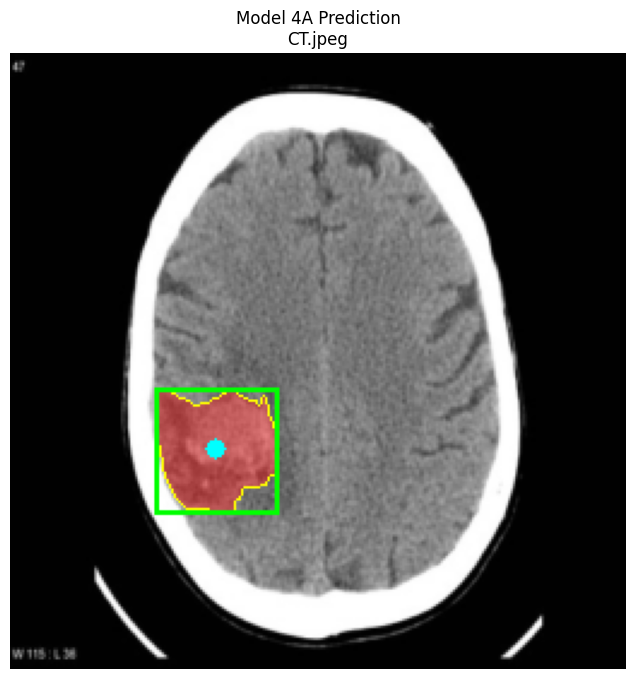


Visualization saved:
/content/drive/MyDrive/Model4A/results/external_test/CT_Model4A_prediction.png

--------------------------------------------------------------------------------
IMAGE 2/2
File: CT.jpg

Original image:
  shape: (270, 250)
  dtype: uint8
  range: 0.0 → 255.0

SEGMENTATION RESULT
Tumor detected: YES
Maximum model confidence: 1.0000

TUMOR MEASUREMENTS
------------------------------------------------------------
Area: 1293 pixels²
Image occupied: 1.9730%
Bounding box:
  x = 80 → 125
  y = 160 → 197
Width: 46 pixels
Height: 38 pixels
Centroid:
  X = 103.26
  Y = 179.36
Boundary pixels: 122
Mean tumor confidence: 0.9942


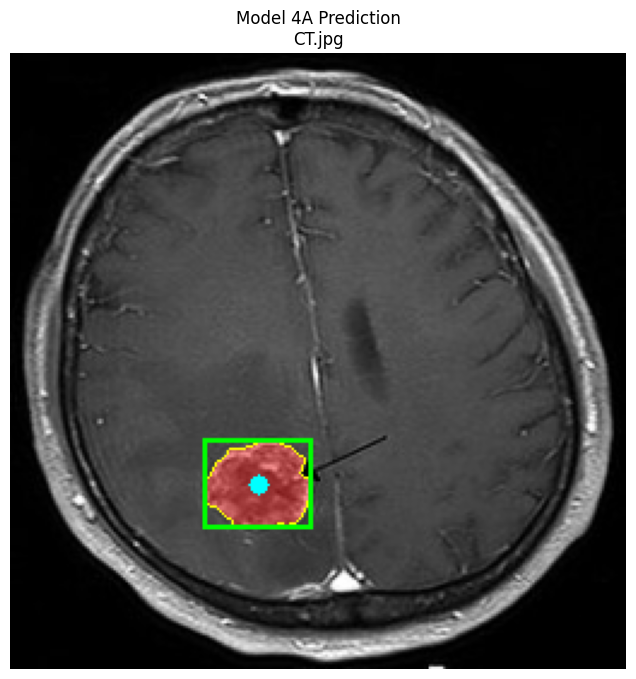


Visualization saved:
/content/drive/MyDrive/Model4A/results/external_test/CT_Model4A_prediction.png

MODEL 4A - EXTERNAL TEST COMPLETE

  image  tumor_detected  area_pixels  area_percent  x_min  y_min  x_max  y_max  width_pixels  height_pixels  centroid_x  centroid_y  boundary_pixels  mean_confidence  max_confidence
CT.jpeg            True         2096      3.198242     60    139    111    191            52             53   84.796756  163.842080              174         0.977620        0.999913
 CT.jpg            True         1293      1.972961     80    160    125    197            46             38  103.262181  179.357309              122         0.994163        0.999986

Results CSV:
/content/drive/MyDrive/Model4A/results/external_test/external_test_results.csv

Results JSON:
/content/drive/MyDrive/Model4A/results/external_test/external_test_results.json

Visualization directory:
/content/drive/MyDrive/Model4A/results/external_test

OUTPUTS GENERATED
✅ Predicted tumor mask
✅ Binary

In [25]:
# =============================================================================
# MODEL 4A - EXTERNAL TEST
# 2D MRI → SEGMENTATION → LOCATION → SIZE → VISUALIZATION
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from scipy import ndimage
import matplotlib.pyplot as plt

from google.colab import drive, files

# =============================================================================
# DRIVE
# =============================================================================

drive.mount("/content/drive")

print("=" * 80)
print("MODEL 4A - EXTERNAL MRI TEST")
print("=" * 80)

# =============================================================================
# PATHS
# =============================================================================

MODEL_PATH = (
    "/content/drive/MyDrive/Model4A/exports/"
    "Model4A_MRI_Tumor_Segmentation_Final.keras"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Model4A/results/external_test"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# LOAD MODEL
# =============================================================================

print()
print("=" * 80)
print("LOADING MODEL")
print("=" * 80)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("✅ Model loaded")
print("Model:", MODEL_PATH)
print("Input :", model.input_shape)
print("Output:", model.output_shape)

# =============================================================================
# UPLOAD MRI IMAGES
# =============================================================================

print()
print("=" * 80)
print("UPLOAD EXTERNAL MRI IMAGES")
print("=" * 80)

print()
print("Upload your NEW MRI images.")
print("You can select two images at once.")
print()
print("Accepted formats: JPG / JPEG / PNG")
print()

uploaded = files.upload()

if len(uploaded) == 0:
    raise RuntimeError(
        "No images uploaded."
    )

print()
print("Uploaded files:")

for filename in uploaded.keys():
    print(" -", filename)

# =============================================================================
# LIMIT / VALIDATE INPUTS
# =============================================================================

image_files = []

for filename in uploaded.keys():

    lower = filename.lower()

    if lower.endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    ):
        image_files.append(filename)

if len(image_files) == 0:
    raise RuntimeError(
        "No supported image files found."
    )

if len(image_files) > 2:

    print()
    print(
        f"⚠️ {len(image_files)} images uploaded."
    )

    print(
        "Processing the first 2 images."
    )

    image_files = image_files[:2]

print()
print(
    "Images selected:",
    len(image_files)
)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def load_external_mri(path):

    image = Image.open(path)

    # Convert to grayscale
    image = image.convert("L")

    original = np.asarray(
        image,
        dtype=np.uint8
    )

    # Resize to model input
    resized = Image.fromarray(
        original
    ).resize(
        (256, 256),
        Image.Resampling.BILINEAR
    )

    resized = np.asarray(
        resized,
        dtype=np.float32
    )

    # Replicate grayscale → RGB
    rgb = np.stack(
        [
            resized,
            resized,
            resized
        ],
        axis=-1
    )

    return original, rgb


def calculate_boundary(mask):

    """
    mask = binary uint8 array {0,1}
    """

    eroded = ndimage.binary_erosion(
        mask
    )

    boundary = (
        mask
        &
        (~eroded)
    )

    return boundary


def analyze_prediction(
    prediction,
    threshold=0.5
):

    binary = (
        prediction >= threshold
    )

    # Remove tiny isolated noise
    labels, num_labels = ndimage.label(
        binary
    )

    if num_labels > 0:

        objects = ndimage.find_objects(
            labels
        )

        sizes = ndimage.sum(
            binary,
            labels,
            range(1, num_labels + 1)
        )

        # Keep connected components >= 20 pixels
        cleaned = np.zeros_like(
            binary,
            dtype=bool
        )

        for i, size in enumerate(sizes):

            if size >= 20:

                cleaned[
                    labels == (i + 1)
                ] = True

        binary = cleaned

    tumor_pixels = int(
        binary.sum()
    )

    if tumor_pixels == 0:

        return {
            "tumor_detected": False,
            "mask": binary,
            "area_pixels": 0,
            "area_percent": 0.0,
            "x_min": None,
            "y_min": None,
            "x_max": None,
            "y_max": None,
            "width_pixels": 0,
            "height_pixels": 0,
            "centroid_x": None,
            "centroid_y": None,
            "boundary_pixels": 0,
            "mean_confidence": 0.0,
            "max_confidence": float(
                prediction.max()
            )
        }

    ys, xs = np.where(
        binary
    )

    x_min = int(xs.min())
    x_max = int(xs.max())

    y_min = int(ys.min())
    y_max = int(ys.max())

    width = (
        x_max -
        x_min +
        1
    )

    height = (
        y_max -
        y_min +
        1
    )

    centroid_x = float(
        xs.mean()
    )

    centroid_y = float(
        ys.mean()
    )

    boundary = calculate_boundary(
        binary
    )

    tumor_confidence = prediction[
        binary
    ]

    return {
        "tumor_detected": True,
        "mask": binary,
        "area_pixels": tumor_pixels,
        "area_percent":
            tumor_pixels /
            (256 * 256) *
            100.0,
        "x_min": x_min,
        "y_min": y_min,
        "x_max": x_max,
        "y_max": y_max,
        "width_pixels": width,
        "height_pixels": height,
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "boundary_pixels":
            int(boundary.sum()),
        "mean_confidence":
            float(tumor_confidence.mean()),
        "max_confidence":
            float(tumor_confidence.max()),
        "boundary": boundary
    }


def create_visualization(
    original,
    resized_rgb,
    prediction,
    analysis,
    filename,
    output_path
):

    # Resize original for display
    display_image = Image.fromarray(
        original
    ).resize(
        (256, 256),
        Image.Resampling.BILINEAR
    )

    display_image = np.asarray(
        display_image
    )

    # RGB visualization
    canvas = np.stack(
        [
            display_image,
            display_image,
            display_image
        ],
        axis=-1
    ).astype(
        np.uint8
    )

    # Predicted tumor mask
    mask = analysis["mask"]

    boundary = calculate_boundary(
        mask
    )

    # Create overlay
    overlay = canvas.copy()

    # Red tumor region
    overlay[mask] = [
        255,
        0,
        0
    ]

    # Blend original + tumor
    blended = (
        0.60 * canvas
        +
        0.40 * overlay
    ).astype(
        np.uint8
    )

    # Yellow boundary
    blended[boundary] = [
        255,
        255,
        0
    ]

    # Bounding box
    if analysis["tumor_detected"]:

        x1 = analysis["x_min"]
        y1 = analysis["y_min"]

        x2 = analysis["x_max"]
        y2 = analysis["y_max"]

        # Draw rectangle manually
        blended[
            max(0, y1):min(256, y1 + 2),
            x1:x2 + 1
        ] = [
            0,
            255,
            0
        ]

        blended[
            max(0, y2 - 1):min(256, y2 + 1),
            x1:x2 + 1
        ] = [
            0,
            255,
            0
        ]

        blended[
            y1:y2 + 1,
            max(0, x1):min(256, x1 + 2)
        ] = [
            0,
            255,
            0
        ]

        blended[
            y1:y2 + 1,
            max(0, x2 - 1):min(256, x2 + 1)
        ] = [
            0,
            255,
            0
        ]

        # Centroid
        cx = int(
            round(
                analysis["centroid_x"]
            )
        )

        cy = int(
            round(
                analysis["centroid_y"]
            )
        )

        radius = 4

        yy, xx = np.ogrid[
            :256,
            :256
        ]

        circle = (
            (xx - cx) ** 2
            +
            (yy - cy) ** 2
            <= radius ** 2
        )

        blended[circle] = [
            0,
            255,
            255
        ]

    # Save visualization
    Image.fromarray(
        blended
    ).save(
        output_path
    )

    # Also display
    plt.figure(
        figsize=(8, 8)
    )

    plt.imshow(
        blended
    )

    plt.title(
        f"Model 4A Prediction\n{filename}"
    )

    plt.axis(
        "off"
    )

    plt.show()


# =============================================================================
# PROCESS IMAGES
# =============================================================================

print()
print("=" * 80)
print("RUNNING EXTERNAL TEST")
print("=" * 80)

results = []

for index, filename in enumerate(
    image_files
):

    print()
    print("-" * 80)
    print(
        f"IMAGE {index + 1}/{len(image_files)}"
    )

    print(
        "File:",
        filename
    )

    # -------------------------------------------------------------------------
    # Load
    # -------------------------------------------------------------------------

    original, model_input = load_external_mri(
        filename
    )

    print()
    print("Original image:")
    print(
        "  shape:",
        original.shape
    )

    print(
        "  dtype:",
        original.dtype
    )

    print(
        "  range:",
        float(original.min()),
        "→",
        float(original.max())
    )

    # -------------------------------------------------------------------------
    # Prediction
    # -------------------------------------------------------------------------

    prediction = model.predict(
        np.expand_dims(
            model_input,
            axis=0
        ),
        verbose=0
    )[0, :, :, 0]

    # -------------------------------------------------------------------------
    # Analyze
    # -------------------------------------------------------------------------

    analysis = analyze_prediction(
        prediction,
        threshold=0.5
    )

    # -------------------------------------------------------------------------
    # Print results
    # -------------------------------------------------------------------------

    print()
    print("=" * 60)
    print("SEGMENTATION RESULT")
    print("=" * 60)

    print(
        "Tumor detected:",
        "YES"
        if analysis["tumor_detected"]
        else "NO"
    )

    print(
        "Maximum model confidence:",
        f"{analysis['max_confidence']:.4f}"
    )

    if analysis["tumor_detected"]:

        print()
        print("TUMOR MEASUREMENTS")
        print("-" * 60)

        print(
            "Area:",
            analysis["area_pixels"],
            "pixels²"
        )

        print(
            "Image occupied:",
            f"{analysis['area_percent']:.4f}%"
        )

        print(
            "Bounding box:"
        )

        print(
            f"  x = {analysis['x_min']} → "
            f"{analysis['x_max']}"
        )

        print(
            f"  y = {analysis['y_min']} → "
            f"{analysis['y_max']}"
        )

        print(
            "Width:",
            analysis["width_pixels"],
            "pixels"
        )

        print(
            "Height:",
            analysis["height_pixels"],
            "pixels"
        )

        print(
            "Centroid:"
        )

        print(
            f"  X = {analysis['centroid_x']:.2f}"
        )

        print(
            f"  Y = {analysis['centroid_y']:.2f}"
        )

        print(
            "Boundary pixels:",
            analysis["boundary_pixels"]
        )

        print(
            "Mean tumor confidence:",
            f"{analysis['mean_confidence']:.4f}"
        )

    else:

        print()
        print(
            "No sufficiently large tumor region "
            "was detected at threshold 0.5."
        )

    # -------------------------------------------------------------------------
    # Visualization
    # -------------------------------------------------------------------------

    safe_name = Path(
        filename
    ).stem

    visual_path = (
        OUTPUT_DIR /
        f"{safe_name}_Model4A_prediction.png"
    )

    create_visualization(
        original,
        model_input,
        prediction,
        analysis,
        filename,
        visual_path
    )

    print()
    print(
        "Visualization saved:"
    )

    print(
        visual_path
    )

    # -------------------------------------------------------------------------
    # Save raw probability mask
    # -------------------------------------------------------------------------

    probability_path = (
        OUTPUT_DIR /
        f"{safe_name}_probability_mask.png"
    )

    probability_uint8 = (
        prediction * 255
    ).clip(
        0,
        255
    ).astype(
        np.uint8
    )

    Image.fromarray(
        probability_uint8
    ).save(
        probability_path
    )

    # -------------------------------------------------------------------------
    # Save binary mask
    # -------------------------------------------------------------------------

    binary_path = (
        OUTPUT_DIR /
        f"{safe_name}_binary_mask.png"
    )

    binary_uint8 = (
        analysis["mask"] * 255
    ).astype(
        np.uint8
    )

    Image.fromarray(
        binary_uint8
    ).save(
        binary_path
    )

    # -------------------------------------------------------------------------
    # Store results
    # -------------------------------------------------------------------------

    result_row = {
        "image":
            filename,

        "tumor_detected":
            analysis["tumor_detected"],

        "area_pixels":
            analysis["area_pixels"],

        "area_percent":
            analysis["area_percent"],

        "x_min":
            analysis["x_min"],

        "y_min":
            analysis["y_min"],

        "x_max":
            analysis["x_max"],

        "y_max":
            analysis["y_max"],

        "width_pixels":
            analysis["width_pixels"],

        "height_pixels":
            analysis["height_pixels"],

        "centroid_x":
            analysis["centroid_x"],

        "centroid_y":
            analysis["centroid_y"],

        "boundary_pixels":
            analysis["boundary_pixels"],

        "mean_confidence":
            analysis["mean_confidence"],

        "max_confidence":
            analysis["max_confidence"]
    }

    results.append(
        result_row
    )

# =============================================================================
# SAVE CSV
# =============================================================================

results_df = pd.DataFrame(
    results
)

csv_path = (
    OUTPUT_DIR /
    "external_test_results.csv"
)

results_df.to_csv(
    csv_path,
    index=False
)

# =============================================================================
# SAVE JSON
# =============================================================================

json_path = (
    OUTPUT_DIR /
    "external_test_results.json"
)

with open(
    json_path,
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=2,
        default=lambda x:
            float(x)
            if isinstance(
                x,
                np.floating
            )
            else x
    )

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print()
print("=" * 80)
print("MODEL 4A - EXTERNAL TEST COMPLETE")
print("=" * 80)

print()
print(
    results_df.to_string(
        index=False
    )
)

print()
print("Results CSV:")
print(csv_path)

print()
print("Results JSON:")
print(json_path)

print()
print("Visualization directory:")
print(OUTPUT_DIR)

print()
print("=" * 80)
print("OUTPUTS GENERATED")
print("=" * 80)

print("✅ Predicted tumor mask")
print("✅ Binary segmentation mask")
print("✅ Tumor boundary")
print("✅ Bounding box")
print("✅ Tumor centroid/location")
print("✅ Tumor area")
print("✅ Tumor width")
print("✅ Tumor height")
print("✅ Tumor percentage")
print("✅ Confidence")
print("✅ Visualization image")
print("✅ CSV report")
print("✅ JSON report")

print()
print("=" * 80)

In [26]:
from google.colab import files
import os

MODEL_PATH = "/content/drive/MyDrive/Model4A/exports/Model4A_MRI_Tumor_Segmentation_Final.keras"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )

print("Model found:")
print(MODEL_PATH)

print("\nStarting download...")

files.download(MODEL_PATH)

print("\n✅ Download requested")

Model found:
/content/drive/MyDrive/Model4A/exports/Model4A_MRI_Tumor_Segmentation_Final.keras

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download requested


In [27]:
from google.colab import files
import os

METADATA_PATH = "/content/drive/MyDrive/Model4A/exports/Model4A_Final_Metadata.json"
VALIDATION_PATH = "/content/drive/MyDrive/Model4A/exports/Model4A_Final_Validation.json"

for path in [METADATA_PATH, VALIDATION_PATH]:

    if os.path.exists(path):
        print(f"Downloading: {os.path.basename(path)}")
        files.download(path)
    else:
        print(f"⚠️ Not found: {path}")

Downloading: Model4A_Final_Metadata.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: Model4A_Final_Validation.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>